# HY Corporate Default Risk — Full Analysis Pipeline (v4)
**Study:** Predicting Corporate Default Risk in US High Yield Firms Using Machine Learning


### Research Questions
| RQ | Question | Method |
|---|---|---|
| RQ1 | Do ML ensembles outperform Altman Z-score and LR? | DeLong test on Set 1 |
| RQ2 | Does Distance to Default improve ML performance? | DeLong test Set1 vs Set2 |
| RQ3 | Does macroeconomic data improve ML performance? | DeLong test Set2 vs Set3 |
| RQ4 | Which features drive predictions? | SHAP on best model |

## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


## Cell 2 — Install Packages

In [2]:
!pip install fredapi scikit-learn xgboost lightgbm imbalanced-learn shap scikit-optimize --quiet
print("Packages installed.")

Packages installed.


## Cell 3 — Imports & Configuration

In [3]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from difflib import get_close_matches
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

BASE         = '/content/drive/MyDrive/DBA/Research'
DATA         = f'{BASE}/data'
OUTPUT       = f'{BASE}/outputs'
PANEL_FILE   = f'{DATA}/panel_data_prelim.xlsx'
LOPUCKI_FILE = f'{DATA}/Florida-UCLA-LoPucki Bankruptcy Research Database 1-12-2023.csv'
FRED_API_KEY = '9310e4faefd94a6352fdb7551dba5982'

TRAIN_END  = 2017
TEST_START = 2018

os.makedirs(OUTPUT, exist_ok=True)

C_DEF   = '#C00000'   # red — defaulted
C_NODEF = '#2E75B6'   # blue — non-defaulted
C_NEUT  = '#70AD47'   # green — neutral
C_WARN  = '#FF8C00'   # orange — warning/rate

print(f"Base  exists: {os.path.exists(BASE)}")
print(f"Data  exists: {os.path.exists(DATA)}")
print(f"Panel exists: {os.path.exists(PANEL_FILE)}")

Base  exists: True
Data  exists: True
Panel exists: True


---
# SECTION A — DATA CLEANING

## Step 1 — Load Raw Data

In [4]:
!pip install openpyxl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 12.7 MB/s eta 0:00:00


In [5]:
print("="*55)
print("STEP 1: LOADING RAW DATA")
print("="*55)

panel_raw = pd.read_excel(PANEL_FILE, header=2)
panel     = panel_raw.iloc[2:].copy()

# Columns mapped by POSITION - not by Excel header text
# Column K  = QR (Quick Ratio, pre-calculated by FactSet)
# Column W  = Retained_Earnings
panel.columns = [
    'Ticker','Company_Name','Year',
    'Revenue','Gross_Profit','EBITDA','Net_Profit',
    'Total_Assets','Fixed_Assets','Current_Assets',
    'QR',                   # K — pre-calculated Quick Ratio from FactSet
    'Total_Liabilities','Current_Liabilities','LT_Liabilities',
    'Total_Equity','LT_Funds',
    'Market_Cap','Share_Price','Equity_Vol',
    'Interest_Expense','Free_Cash_Flow','Operating_CF',
    'Retained_Earnings',    # W added for Altman X2 (Retained Earnings / Total Assets)
    'OAS',
    'GDP_Growth','Treasury_10Y','Treasury_2Y','HY_OAS','CPI'
]

lop = pd.read_csv(LOPUCKI_FILE, encoding='latin1', low_memory=False)
print(f"FactSet rows:  {len(panel):,}")
print(f"LoPucki rows:  {len(lop):,}")


STEP 1: LOADING RAW DATA
FactSet rows:  6,262
LoPucki rows:  1,218


## Step 2 — Fix Data Types

In [6]:
print("="*55)
print("STEP 2: FIXING DATA TYPES")
print("="*55)

panel['Year'] = pd.to_numeric(panel['Year'], errors='coerce')
panel = panel[panel['Year'].notna()].copy()
panel['Year'] = panel['Year'].astype(int)
panel['Company_Name'] = panel['Company_Name'].astype(str).str.strip()
panel['Ticker']       = panel['Ticker'].astype(str).str.strip()

fin_cols = [
    'Revenue','Gross_Profit','EBITDA','Net_Profit',
    'Total_Assets','Fixed_Assets','Current_Assets','QR',
    'Total_Liabilities','Current_Liabilities','LT_Liabilities',
    'Total_Equity','LT_Funds','Market_Cap','Share_Price','Equity_Vol',
    'Interest_Expense','Free_Cash_Flow','Operating_CF',
    'Retained_Earnings'
]
for col in fin_cols:
    panel[col] = pd.to_numeric(panel[col], errors='coerce')

print(f"Rows: {len(panel):,} | Years: {panel.Year.min()}-{panel.Year.max()} | Firms: {panel.Ticker.nunique()}")


STEP 2: FIXING DATA TYPES
Rows: 6,262 | Years: 2000-2022 | Firms: 412


## Step 3 — Remove Completely Empty Rows

In [7]:
print("="*55)
print("STEP 3: REMOVING EMPTY ROWS")
print("="*55)

before = len(panel)
key_cols = ['Total_Assets','EBITDA','Net_Profit','Revenue','Total_Liabilities']
panel = panel[panel[key_cols].notna().any(axis=1)].copy()
print(f"Removed: {before-len(panel):,} empty rows")
print(f"Remaining: {len(panel):,} | Firms: {panel.Ticker.nunique()}")

STEP 3: REMOVING EMPTY ROWS
Removed: 3,178 empty rows
Remaining: 3,084 | Firms: 242


## Step 4 — Handle Negative Values

In [8]:
print("="*55)
print("STEP 4: HANDLING NEGATIVE VALUES")
print("="*55)

for col in ['Total_Assets','Revenue','Current_Assets','Fixed_Assets']:
    n = (panel[col] < 0).sum()
    if n > 0:
        panel.loc[panel[col]<0, col] = np.nan
        print(f"  {col:<25}: {n} set to NaN (definitionally impossible)")

n_ie = (panel['Interest_Expense'] < 0).sum()
panel['Interest_Expense'] = panel['Interest_Expense'].abs()
print(f"  {'Interest_Expense':<25}: {n_ie} converted to absolute value")

# Legitimate negatives — retained as economically meaningful distress signals
legitimate = ['Total_Equity','Net_Profit','EBITDA','LT_Liabilities',
              'Free_Cash_Flow','Operating_CF','Gross_Profit','Retained_Earnings']
for col in legitimate:
    if col in panel.columns:
        n = (panel[col] < 0).sum()
        print(f"  {col:<25}: {n} negatives KEPT (legitimate — e.g. distressed firms)")


STEP 4: HANDLING NEGATIVE VALUES
  Revenue                  : 1 set to NaN (definitionally impossible)
  Current_Assets           : 1 set to NaN (definitionally impossible)
  Interest_Expense         : 1 converted to absolute value
  Total_Equity             : 277 negatives KEPT (legitimate — e.g. distressed firms)
  Net_Profit               : 1072 negatives KEPT (legitimate — e.g. distressed firms)
  EBITDA                   : 211 negatives KEPT (legitimate — e.g. distressed firms)
  LT_Liabilities           : 0 negatives KEPT (legitimate — e.g. distressed firms)
  Free_Cash_Flow           : 1053 negatives KEPT (legitimate — e.g. distressed firms)
  Operating_CF             : 424 negatives KEPT (legitimate — e.g. distressed firms)
  Gross_Profit             : 119 negatives KEPT (legitimate — e.g. distressed firms)
  Retained_Earnings        : 1176 negatives KEPT (legitimate — e.g. distressed firms)


## Step 5 — Compute Financial Ratios (Mushtaq Ahmad et al. 2026)

In [9]:
print("="*55)
print("STEP 5: COMPUTING FINANCIAL RATIOS")
print("="*55)

p = panel.copy()

def sd(a, b):
    return np.where((pd.isna(b))|(b==0), np.nan, a/b)

# PROFITABILITY
p['EBITDAFE'] = sd(p['EBITDA'],       p['Interest_Expense'])
p['EBITDATA'] = sd(p['EBITDA'],       p['Total_Assets'])
p['EBITDAEQ'] = sd(p['EBITDA'],       p['Total_Equity'])
p['EBITDASA'] = sd(p['EBITDA'],       p['Revenue'])
p['NPSA']     = sd(p['Net_Profit'],   p['Revenue'])
p['GPSA']     = sd(p['Gross_Profit'], p['Revenue'])
p['NITA']     = sd(p['Net_Profit'],   p['Total_Assets'])
p['NITE']     = sd(p['Net_Profit'],   p['Total_Equity'])
p['EBITTA']   = p['EBITDATA'].copy()
# LNNI DROPPED - biased missingness toward distressed firms
# NPEMP, INVTO, RECTO DROPPED — data unavailable

# LEVERAGE
p['EQTA']   = sd(p['Total_Equity'],      p['Total_Assets'])
p['EQFA']   = sd(p['Total_Equity'],      p['Fixed_Assets'])
p['EQLIAB'] = sd(p['Total_Equity'],      p['Total_Liabilities'])
p['LIABTA'] = sd(p['Total_Liabilities'], p['Total_Assets'])
p['LTLTA']  = sd(p['LT_Liabilities'],    p['Total_Assets'])
p['LTFFA']  = sd(p['LT_Funds'],          p['Fixed_Assets'])
p['DE']     = sd(p['Total_Liabilities'], p['Total_Equity'])

#  LIQUIDITY & CASH FLOW
p['CFEQ']  = sd(p['Operating_CF'], p['Total_Equity'])
p['CFTA']  = sd(p['Operating_CF'], p['Total_Assets'])
p['CFSA']  = sd(p['Operating_CF'], p['Revenue'])
p['OCACL'] = sd(p['Operating_CF'], p['Current_Liabilities'])
p['CR']    = sd(p['Current_Assets'], p['Current_Liabilities'])
# QR — pre-calculated by FactSet, no computation needed

#  FIRM SIZE
p['LNTA'] = np.where(p['Total_Assets']>0, np.log(p['Total_Assets']), np.nan)
p['LNSA'] = np.where(p['Revenue']>0,      np.log(p['Revenue']),      np.nan)
p['SATA'] = sd(p['Revenue'], p['Total_Assets'])

#  GROWTH
p = p.sort_values(['Ticker','Year']).reset_index(drop=True)
p['SG']       = p.groupby('Ticker')['Revenue'].pct_change()
p['EBITDA_G'] = p.groupby('Ticker')['EBITDA'].pct_change()
p['CFG']      = p.groupby('Ticker')['Operating_CF'].pct_change()
p['EQG']      = p.groupby('Ticker')['Total_Equity'].pct_change()
p['NPG']      = p.groupby('Ticker')['Net_Profit'].pct_change()

print("Base ratios computed: 30 variables")
print("QR: read directly from FactSet (pre-calculated)")

STEP 5: COMPUTING FINANCIAL RATIOS
Base ratios computed: 30 variables
QR: read directly from FactSet (pre-calculated)


## Step 5b — Change Variables (Year-on-Year Trajectory)
Captures financial deterioration direction without introducing multicollinearity.

In [10]:
print("="*55)
print("STEP 5b: CHANGE VARIABLES")
print("="*55)

# Year-on-year change = current - prior year
# Captures trajectory (is leverage rising? is profitability falling?)
# without adding the collinearity of raw lagged values

CHANGE_VARS = ['NITA','NPSA','EQFA','EBITDAFE','LIABTA','CFTA']
for var in CHANGE_VARS:
    lag1 = p.groupby('Ticker')[var].shift(1)
    p[f'{var}_chg'] = p[var] - lag1

CHANGE_FEATURES = [f'{v}_chg' for v in CHANGE_VARS]

print("Change variables added (current year minus prior year):")
for f in CHANGE_FEATURES:
    avail = p[f].notna().mean()*100
    print(f"  {f:<20}: {avail:.1f}% available")

print(f"\nNote: Change variable loses only the first year per firm")

STEP 5b: CHANGE VARIABLES
Change variables added (current year minus prior year):
  NITA_chg            : 90.4% available
  NPSA_chg            : 91.0% available
  EQFA_chg            : 85.0% available
  EBITDAFE_chg        : 83.2% available
  LIABTA_chg          : 89.9% available
  CFTA_chg            : 90.0% available

Note: Change variable loses only the first year per firm


## Step 5c — Altman Z-Score (Raw, Unwinsorized — Benchmark Only)

In [11]:
p['altman_x1'] = sd(p['Current_Assets']-p['Current_Liabilities'], p['Total_Assets'])
p['altman_x2'] = sd(p['Retained_Earnings'], p['Total_Assets'])
p['altman_x3'] = p['EBITDATA'].copy()
p['altman_x4'] = sd(p['Market_Cap'],     p['Total_Liabilities'])
p['altman_x5'] = p['SATA'].copy()

p['altman_zscore_raw'] = (
    1.2*p['altman_x1'].fillna(0) + 1.4*p['altman_x2'].fillna(0) +
    3.3*p['altman_x3'].fillna(0) + 0.6*p['altman_x4'].fillna(0) +
    1.0*p['altman_x5'].fillna(0)
)
all_miss = p[['altman_x1','altman_x2','altman_x3','altman_x4','altman_x5']].isna().all(axis=1)
p.loc[all_miss,'altman_zscore_raw'] = np.nan
print(f"Altman Z-score computed (unwinsorized)")
print(f"  X2 (RE/TA) available: {p['altman_x2'].notna().mean()*100:.1f}%")
print(f"  Z-score available:    {p['altman_zscore_raw'].notna().mean()*100:.1f}%")


Altman Z-score computed (unwinsorized)
  X2 (RE/TA) available: 94.6%
  Z-score available:    98.5%


## Step 5d — Merton Distance to Default (Bharath & Shumway 2008)

In [12]:
def compute_dd(row):
    E, D, sigma = row['Market_Cap'], row['Total_Liabilities'], row['Equity_Vol']
    if any(pd.isna(x) for x in [E,D,sigma]): return np.nan
    if D<=0 or E<=0 or sigma<=0: return np.nan
    try:
        s = sigma/100.0 if sigma>1 else sigma
        return (np.log((E+D)/D) + (-0.5*s**2)) / s
    except: return np.nan

p['distance_to_default'] = p.apply(compute_dd, axis=1)
print(f"Distance to Default: {p['distance_to_default'].notna().mean()*100:.1f}% available")
print(f"Mean: {p['distance_to_default'].mean():.2f} | Std: {p['distance_to_default'].std():.2f}")

Distance to Default: 77.2% available
Mean: 1.77 | Std: 2.21


## Step 6 — Winsorize (1st and 99th Percentile)

In [13]:
print("="*55)
print("STEP 6: WINSORIZING — DEFERRED")
print("="*55)

# FIX: Winsorisation moved to AFTER train/test split (Step 10b below).
# Rationale: computing percentile bounds on the full panel (including test period)
# allows test-set information to influence training-data transformations — a form
# of data leakage. Bounds must be derived from training data only.

# RATIO_VARS and WIN_COLS are still defined here for use downstream.
RATIO_VARS = [
    'EBITDAFE','EBITDATA','EBITDAEQ','EBITDASA','NPSA','GPSA','NITA','NITE','EBITTA',
    'EQTA','EQFA','EQLIAB','LIABTA','LTLTA','LTFFA','DE',
    'CFEQ','CFTA','CFSA','OCACL','CR','QR','LNTA','LNSA','SATA',
    'SG','EBITDA_G','CFG','EQG','NPG'
] + CHANGE_FEATURES

WIN_COLS = RATIO_VARS + [
    'altman_x1','altman_x2','altman_x3','altman_x4','altman_x5',
    'distance_to_default'
]

print(f"RATIO_VARS defined: {len(RATIO_VARS)} variables")
print(f"WIN_COLS defined:   {len(WIN_COLS)} variables")
print(f"Winsorisation will be applied in Step 10b (after train/test split)")
print(f"altman_zscore_raw will remain unwinsorized throughout")


STEP 6: WINSORIZING — DEFERRED
RATIO_VARS defined: 36 variables
WIN_COLS defined:   42 variables
Winsorisation will be applied in Step 10b (after train/test split)
altman_zscore_raw will remain unwinsorized throughout


## Step 7 — Create Default Flag (Forward-Looking, LoPucki)

In [14]:
print("="*55)
print("STEP 7: DEFAULT FLAG")
print("="*55)

lop['DateFiled']      = pd.to_datetime(lop['DateFiled'], errors='coerce')
lop['YearFiled']      = lop['DateFiled'].dt.year
lop['AssetsPetition'] = pd.to_numeric(lop['AssetsPetition'], errors='coerce')
lop_study = lop[
    (lop['YearFiled']>=2000)&(lop['YearFiled']<=2022)&
    (lop['AssetsPetition']>=100)
].copy()

# Build lookup: panel name -> set of years that firm appears in panel
firm_years  = p.groupby(p['Company_Name'].str.lower().str.strip())['Year'].apply(set).to_dict()
panel_names = set(firm_years.keys())

FUZZY_CUTOFF = 0.85
YEAR_WINDOW  = 2     # Fuzzy match only accepted if firm present within ±2 years of filing

MANUAL_REJECT = {
    'sfx entertainment, inc.',
    'swift energy company',
    'txco resources inc.',
    'xerium technologies, inc.',
    'xo communications, inc.',
    'advanta corp',
    'ntl communications corp.',
    'covad communications group, inc.',
    'covia holdings corporation',
    'gnc holdings, inc.',
    'it group, inc.',
    'rhi entertainment, inc.',
    'ntk holdings, inc.',

}

# Key = LoPucki name lowercased
# Value = (FactSet panel name lowercased, filing year)
MANUAL_MATCH = {
    'key energy services, inc.': ('key energy services inc', 2016),
    'focal communications corporation': ('focal communications corp', 2002),
    'abitibibowater inc.': ('abitibibowater canada inc', 2009),
    'american homestar corp.': ('american homestar corporation', 2001),
    'apex silver mines limited': ('apex silver mines', 2009),
    'asia global crossing, ltd.': ('asia global crossing ltd. class a', 2002),
    'california coastal communities, inc.': ('california coastal cmntys i com new', 2009),
    'calpine corp.': ('calpine corporation', 2005),
    'citadel broadcasting corporation': ('citadel broadcasting corp cl b', 2009),
    'dura automotive systems, inc.': ('dura automotive sys a', 2006),
    'edge petroleum corporation': ('edge petroleum corp', 2009),
    'general maritime corporation': ('general maritime corp.', 2011),
    'itc deltacom, inc.': ('itc deltacom', 2002),
    'jones energy, inc.': ('jones energy, inc. class a', 2019),
    'kaiser aluminum corp.': ('kaiser aluminum corporation', 2002),

}

default_set   = set()
exact_matches = []
fuzzy_matches = []
unmatched     = []

for _, row in lop_study.iterrows():
    nc = str(row['NameCorp']).lower().strip()
    yr = int(row['YearFiled'])

    # Manual reject — verified bad match, skip entirely
    if nc in MANUAL_REJECT:
        unmatched.append(row['NameCorp'])
        continue

    # Manual match — verified correct match, use directly
    if nc in MANUAL_MATCH:
        matched_name, matched_yr = MANUAL_MATCH[nc]
        default_set.add((matched_name, matched_yr))
        exact_matches.append((row['NameCorp'], matched_name, matched_yr, 'MANUAL'))
        continue

    if nc in panel_names:
        # Exact match
        default_set.add((nc, yr))
        exact_matches.append((row['NameCorp'], nc, yr, 'EXACT'))
    else:
        m = get_close_matches(nc, panel_names, n=1, cutoff=FUZZY_CUTOFF)
        if m:
            matched_name = m[0]
            # Year proximity check: firm must appear within YEAR_WINDOW of filing year
            firm_yrs = firm_years.get(matched_name, set())
            if any(abs(yr - fy) <= YEAR_WINDOW for fy in firm_yrs):
                default_set.add((matched_name, yr))
                fuzzy_matches.append((row['NameCorp'], matched_name, yr, 'FUZZY-ACCEPTED'))
            else:
                fuzzy_matches.append((row['NameCorp'], matched_name, yr, 'FUZZY-REJECTED-YEAR'))
                unmatched.append(row['NameCorp'])
        else:
            unmatched.append(row['NameCorp'])

MANUAL_DEFAULTS = [
    #('asia global crossing ltd. class a', 2002),
    #(),
]
for name, yr in MANUAL_DEFAULTS:
    default_set.add((name, yr))
    print(f"  Manual default added: '{name}' ({yr})")

p['y_default'] = p.apply(
    lambda r: 1 if (str(r['Company_Name']).lower().strip(),
                    int(r['Year'])+1) in default_set else 0, axis=1)

print(f"Default events (Y=1): {p.y_default.sum():,} ({p.y_default.mean()*100:.2f}%)")
print(f"Non-default   (Y=0):  {(p.y_default==0).sum():,}")
print(f"Exact matches:        {len(exact_matches)}")
print(f"Manual matches:       {sum(1 for m in exact_matches if m[3]=='MANUAL')}")
print(f"Fuzzy accepted:       {sum(1 for m in fuzzy_matches if m[3]=='FUZZY-ACCEPTED')}")
print(f"Fuzzy rejected (year proximity): {sum(1 for m in fuzzy_matches if m[3]=='FUZZY-REJECTED-YEAR')}")
print(f"Manual rejected:      {sum(1 for u in unmatched if any(u.lower().strip()==r for r in MANUAL_REJECT))}")
print(f"Unmatched LoPucki:    {len(unmatched)}")

#  MANUAL AUDIT TABLE - review all fuzzy matches
print(f"\n{'─'*80}")
print("FUZZY MATCH AUDIT TABLE — MANUAL REVIEW REQUIRED")
print(f"{'─'*80}")
print(f"  {'LoPucki Name':<35} {'Matched Panel Name':<35} {'Year':>6}  {'Status'}")
print(f"  {'-'*80}")
for lop_name, panel_name, yr, status in sorted(fuzzy_matches, key=lambda x: x[3]):
    flag = " <-- REVIEW" if status == 'FUZZY-ACCEPTED' else ""
    print(f"  {lop_name:<35} {panel_name:<35} {yr:>6}  {status}{flag}")
print(f"{'─'*80}")
print("ACTION: Verify each FUZZY-ACCEPTED match above is correct before trusting default labels.")


STEP 7: DEFAULT FLAG
Default events (Y=1): 104 (3.37%)
Non-default   (Y=0):  2,980
Exact matches:        67
Manual matches:       15
Fuzzy accepted:       61
Fuzzy rejected (year proximity): 7
Manual rejected:      12
Unmatched LoPucki:    452

────────────────────────────────────────────────────────────────────────────────
FUZZY MATCH AUDIT TABLE — MANUAL REVIEW REQUIRED
────────────────────────────────────────────────────────────────────────────────
  LoPucki Name                        Matched Panel Name                    Year  Status
  --------------------------------------------------------------------------------
  ABC-NACO, Inc.                      abc naco inc.                         2001  FUZZY-ACCEPTED <-- REVIEW
  Adelphia Business Solutions, Inc.   adelphia business solutions inc.      2002  FUZZY-ACCEPTED <-- REVIEW
  Adelphia Communications Corp.       adelphia communications corporation   2002  FUZZY-ACCEPTED <-- REVIEW
  Alterra HealthCare Corp             alterra he

In [15]:
# DEFAULT VERIFICATION EXPORTS for second manual check
import openpyxl
from openpyxl import Workbook

wb = Workbook()

# SHEET 1: All default events
ws1 = wb.active
ws1.title = 'Default Events'

# Header
ws1.append(['Company_Name_FactSet', 'Ticker', 'Year_Flagged', 'Default_Year',
            'Match_Type', 'LoPucki_Name'])

# Build a lookup: (panel_name_lower, year_filed) -> (lopucki_name, match_type)
match_lookup = {}
for lop_name, panel_name, yr, status in exact_matches:
    match_lookup[(panel_name.lower().strip(), yr)] = (lop_name, status)
for lop_name, panel_name, yr, status in fuzzy_matches:
    if status == 'FUZZY-ACCEPTED':
        match_lookup[(panel_name.lower().strip(), yr)] = (lop_name, status)
# Manual defaults
for name, yr in MANUAL_DEFAULTS:
    match_lookup[(name.lower().strip(), yr)] = ('MANUAL ADDITION', 'MANUAL')

# Get all flagged rows
defaults_df = p[p['y_default'] == 1][['Company_Name','Ticker','Year']].copy()
defaults_df = defaults_df.sort_values(['Company_Name','Year']).reset_index(drop=True)

for _, row in defaults_df.iterrows():
    panel_name_lower = str(row['Company_Name']).lower().strip()
    default_year     = int(row['Year']) + 1   # y_default=1 means defaults in Year+1
    # Look up match info
    match_info = match_lookup.get((panel_name_lower, default_year),
                                   ('Not found in lookup', 'UNKNOWN'))
    ws1.append([
        row['Company_Name'],
        row['Ticker'],
        int(row['Year']),           # year the flag sits on
        default_year,               # year the default actually occurred
        match_info[1],              # EXACT / FUZZY-ACCEPTED / MANUAL
        match_info[0],              # original LoPucki name
    ])

# Style header row
for cell in ws1[1]:
    cell.font = openpyxl.styles.Font(bold=True)
    cell.fill = openpyxl.styles.PatternFill('solid', fgColor='0A3B6B')
    cell.font = openpyxl.styles.Font(bold=True, color='FFFFFF')

# Auto column width
for col in ws1.columns:
    max_len = max(len(str(cell.value or '')) for cell in col)
    ws1.column_dimensions[col[0].column_letter].width = min(max_len + 4, 50)

# SHEET 2: All companies in dataset (unique firms, not firm-years)
ws2 = wb.create_sheet('All Companies')

ws2.append(['Ticker', 'Company_Name_FactSet', 'First_Year', 'Last_Year',
            'Years_In_Panel', 'Has_Default', 'Default_Years'])

company_summary = []
for ticker, grp in p.groupby('Ticker'):
    company_name = grp['Company_Name'].iloc[0]
    first_year   = int(grp['Year'].min())
    last_year    = int(grp['Year'].max())
    years_count  = int(grp['Year'].nunique())
    has_default  = int(grp['y_default'].max())
    # Which years were flagged as default
    def_years    = sorted(grp[grp['y_default']==1]['Year'].tolist())
    def_years_str = ', '.join(str(y+1) for y in def_years)  # show actual default year
    company_summary.append([
        ticker, company_name, first_year, last_year,
        years_count, has_default, def_years_str
    ])

company_summary.sort(key=lambda x: x[1])  # sort by company name

for row_data in company_summary:
    ws2.append(row_data)

# Style header
for cell in ws2[1]:
    cell.fill = openpyxl.styles.PatternFill('solid', fgColor='0A3B6B')
    cell.font = openpyxl.styles.Font(bold=True, color='FFFFFF')

# Auto column width
for col in ws2.columns:
    max_len = max(len(str(cell.value or '')) for cell in col)
    ws2.column_dimensions[col[0].column_letter].width = min(max_len + 4, 50)

# SAVE
verify_path = f'{OUTPUT}/default_verification.xlsx'
wb.save(verify_path)
print(f"Saved: {verify_path}")
print(f"\nSheet 1 — Default Events:  {defaults_df.shape[0]} rows")
print(f"Sheet 2 — All Companies:   {len(company_summary)} unique firms")
print(f"  Of which have defaults:  {sum(1 for r in company_summary if r[5]==1)}")
print(f"  Of which no defaults:    {sum(1 for r in company_summary if r[5]==0)}")

Saved: /content/drive/MyDrive/DBA/Research/outputs/default_verification.xlsx

Sheet 1 — Default Events:  104 rows
Sheet 2 — All Companies:   242 unique firms
  Of which have defaults:  102
  Of which no defaults:    140


## Step 8 — Handle Missing Data

In [16]:
print("="*55)
print("STEP 8: MISSING DATA")
print("="*55)

key_fin = ['EBITDATA','LIABTA','CR','NITA','LNTA','SATA']
before  = len(p)
miss_pct = p.groupby('Ticker')[key_fin].apply(lambda x: x.isna().mean().mean())
drop_firms = miss_pct[miss_pct > 0.5].index
p = p[~p['Ticker'].isin(drop_firms)].copy()
print(f"Firms dropped (>50% missing on key vars): {len(drop_firms)}")
print(f"Firm-years: {before:,} -> {len(p):,}")
print(f"Unique firms remaining: {p.Ticker.nunique()}")

STEP 8: MISSING DATA
Firms dropped (>50% missing on key vars): 1
Firm-years: 3,084 -> 3,083
Unique firms remaining: 241


---
# SECTION B — EXPLORATORY DATA ANALYSIS


## EDA 1 — Dataset Overview and Default Distribution

EDA 1: DATASET OVERVIEW
Total firm-years:  3,083
Unique firms:      241
Year range:        2000 - 2022
Default rate:      3.37%
Default events:    104
Non-default:       2,979


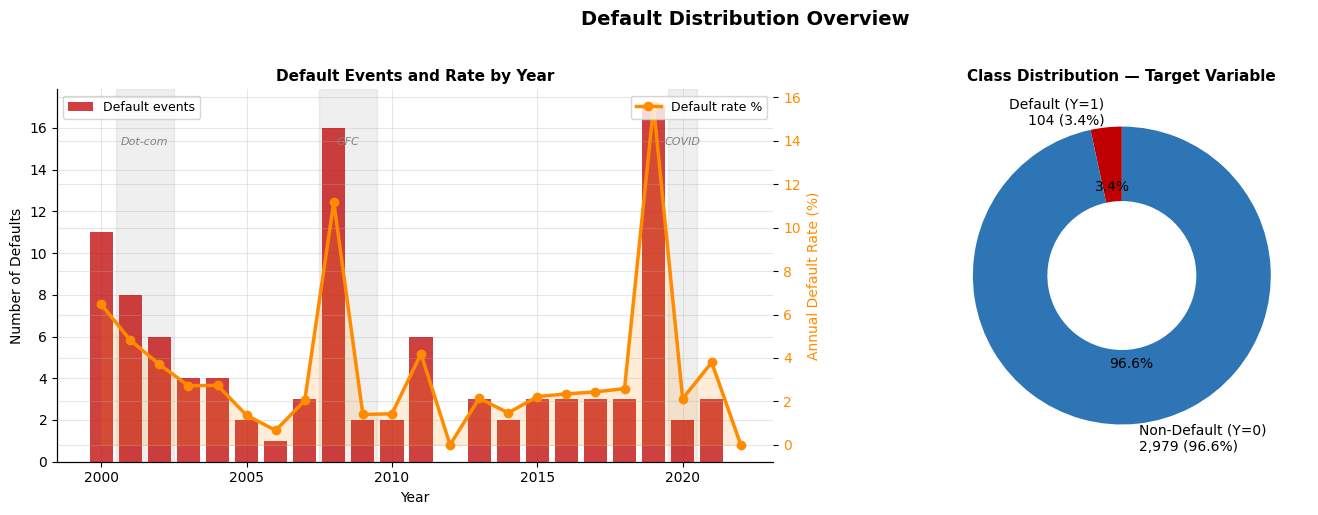

Saved: eda_01_default_overview.png


In [17]:
print("="*55)
print("EDA 1: DATASET OVERVIEW")
print("="*55)

print(f"Total firm-years:  {len(p):,}")
print(f"Unique firms:      {p.Ticker.nunique():,}")
print(f"Year range:        {p.Year.min()} - {p.Year.max()}")
print(f"Default rate:      {p.y_default.mean()*100:.2f}%")
print(f"Default events:    {p.y_default.sum():,}")
print(f"Non-default:       {(p.y_default==0).sum():,}")

# ── Figure 1: Default overview — 2 panels ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Default Distribution Overview', fontsize=14, fontweight='bold', y=1.02)

# Left: Events and rate by year
ax = axes[0]
yr_d = p[p.y_default==1].groupby('Year').size()
yr_t = p.groupby('Year').size()
yr_r = (yr_d/yr_t*100).fillna(0)

bars = ax.bar(yr_d.index, yr_d.values, color=C_DEF, alpha=0.75, label='Default events', zorder=3)
ax2  = ax.twinx()
ax2.plot(yr_r.index, yr_r.values, 'o-', color=C_WARN, lw=2.5, ms=6,
         label='Default rate %', zorder=4)
ax2.fill_between(yr_r.index, yr_r.values, alpha=0.15, color=C_WARN)
ax2.set_ylabel('Annual Default Rate (%)', color=C_WARN, fontsize=10)
ax2.tick_params(axis='y', labelcolor=C_WARN)

# Shade recession years
for yr_start, yr_end, label in [(2001,2002,'Dot-com'),(2008,2009,'GFC'),(2020,2020,'COVID')]:
    ax.axvspan(yr_start-0.5, yr_end+0.5, alpha=0.12, color='grey', zorder=1)
    ax.text((yr_start+yr_end)/2, ax.get_ylim()[1]*0.85, label,
            ha='center', fontsize=8, color='grey', style='italic')

ax.set_title('Default Events and Rate by Year', fontweight='bold', fontsize=11)
ax.set_xlabel('Year'); ax.set_ylabel('Number of Defaults', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

# Right: Pie / donut of class balance
ax = axes[1]
sizes = [p.y_default.sum(), (p.y_default==0).sum()]
labels= [f'Default (Y=1)\n{sizes[0]:,} ({p.y_default.mean()*100:.1f}%)',
         f'Non-Default (Y=0)\n{sizes[1]:,} ({(1-p.y_default.mean())*100:.1f}%)']
colors= [C_DEF, C_NODEF]
wedges, texts, autos = ax.pie(sizes, labels=labels, colors=colors,
                               autopct='%1.1f%%', startangle=90,
                               wedgeprops=dict(width=0.5),
                               textprops={'fontsize':10})
ax.set_title('Class Distribution — Target Variable', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_01_default_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: eda_01_default_overview.png")

## EDA 2 — Descriptive Statistics: ALL Variables
Mann-Whitney U test computed for every ratio variable. Variables ranked by Cohen's d (standardised mean difference). This ranking is used to objectively select variables for all subsequent EDA figures.

In [18]:
print("="*65)
print("EDA 2: DESCRIPTIVE STATISTICS — ALL VARIABLES")
print("  Mann-Whitney U test for ALL ratio variables")
print("  Variables ranked by effect size (Cohen's d)")
print("  Top N selected for figures using this objective ranking")
print("="*65)

from scipy.stats import mannwhitneyu

# All ratio and structural variables to analyse
ALL_VARS = RATIO_VARS + ['distance_to_default', 'altman_zscore_raw']
ALL_VARS = [v for v in ALL_VARS if v in p.columns]

records = []
for var in ALL_VARS:
    g0 = p[p.y_default==0][var].dropna()
    g1 = p[p.y_default==1][var].dropna()
    if len(g0) < 5 or len(g1) < 5:
        continue
    # Cohen's d (standardised mean difference) — objective effect size
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = abs(g0.mean() - g1.mean()) / pooled_std if pooled_std > 0 else 0
    # Mann-Whitney U
    stat, pval = mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'n.s.'
    records.append({
        'Variable':    var,
        'N_nondefault':len(g0),
        'N_default':   len(g1),
        'Mean_Y0':     round(g0.mean(), 4),
        'Median_Y0':   round(g0.median(), 4),
        'Std_Y0':      round(g0.std(), 4),
        'Mean_Y1':     round(g1.mean(), 4),
        'Median_Y1':   round(g1.median(), 4),
        'Std_Y1':      round(g1.std(), 4),
        'Cohens_d':    round(cohens_d, 4),
        'MW_stat':     round(stat, 1),
        'MW_pvalue':   round(pval, 6),
        'Sig':         sig,
    })

eda_stats = pd.DataFrame(records).sort_values('Cohens_d', ascending=False).reset_index(drop=True)
eda_stats['Rank'] = eda_stats.index + 1

# Save COMPLETE table
eda_stats.to_csv(f'{OUTPUT}/eda_descriptive_stats_all.csv', index=False)

print(f"\nTotal variables analysed: {len(eda_stats)}")
print(f"Significant (p<0.05):     {(eda_stats.Sig != 'n.s.').sum()}")
print(f"Significant (p<0.001):    {(eda_stats.Sig == '***').sum()}")
print(f"\nTop 20 by effect size (Cohen's d):")
print(f"{'Rank':<5} {'Variable':<20} {'Mean_Y0':>9} {'Mean_Y1':>9} "
      f"{'Cohen_d':>8} {'p-value':>10} {'Sig':>5}")
print('-'*70)
for _, row in eda_stats.head(20).iterrows():
    print(f"{int(row.Rank):<5} {row.Variable:<20} {row.Mean_Y0:>9.4f} "
          f"{row.Mean_Y1:>9.4f} {row.Cohens_d:>8.4f} {row.MW_pvalue:>10.6f} {row.Sig:>5}")

#  SELECT TOP N FOR FIGURES (data-driven, documented)
TOP_N = 12   # for KDE/distribution plots
TOP_BOX = 12 # for box plots
TOP_TREND = 9 # for trend plots (3x3 grid)

# Top N by Cohen's d, excludes the raw Z-score from figure selection
fig_candidates = eda_stats[eda_stats.Variable != 'altman_zscore_raw']
TOP_VARS_DIST  = fig_candidates.head(TOP_N)['Variable'].tolist()
TOP_VARS_BOX   = fig_candidates.head(TOP_BOX)['Variable'].tolist()
TOP_VARS_TREND = fig_candidates.head(TOP_TREND)['Variable'].tolist()

print(f"\n{'─'*65}")
print(f"FIGURE VARIABLE SELECTION (objective, ranked by Cohen's d):")
print(f"  KDE distributions (top {TOP_N}):  {TOP_VARS_DIST}")
print(f"  Box plots (top {TOP_BOX}):          {TOP_VARS_BOX}")
print(f"  Trend plots (top {TOP_TREND}):        {TOP_VARS_TREND}")
print(f"{'─'*65}")
print(f"\nSaved: {OUTPUT}/eda_descriptive_stats_all.csv")
print(f"Note: All {len(eda_stats)} variables in CSV; top N in figures ranked by Cohen's d.")

EDA 2: DESCRIPTIVE STATISTICS — ALL VARIABLES
  Mann-Whitney U test for ALL ratio variables
  Variables ranked by effect size (Cohen's d)
  Top N selected for figures using this objective ranking

Total variables analysed: 38
Significant (p<0.05):     34
Significant (p<0.001):    32

Top 20 by effect size (Cohen's d):
Rank  Variable               Mean_Y0   Mean_Y1  Cohen_d    p-value   Sig
----------------------------------------------------------------------
1     distance_to_default     1.8337   -0.4663   1.2737   0.000000   ***
2     LIABTA                  0.7109    1.0450   0.7602   0.000000   ***
3     EQTA                    0.2860   -0.0450   0.7498   0.000000   ***
4     NITA                   -0.0095   -0.2561   0.7262   0.000000   ***
5     LIABTA_chg              0.0163    0.2066   0.6479   0.000000   ***
6     altman_zscore_raw       2.0462   -0.2083   0.5704   0.000000   ***
7     CFTA                    0.0659    0.0064   0.5558   0.000000   ***
8     NITA_chg           

## EDA 3 — Variable Distributions by Default Status

## EDA Figure 2 — KDE Distributions (Top 12 by Cohen's d)
Variables selected objectively by effect size from the complete ranked table above. Rank and significance shown in each panel title.

EDA Figure 2: KDE Distributions — Top 12 variables by Cohen's d


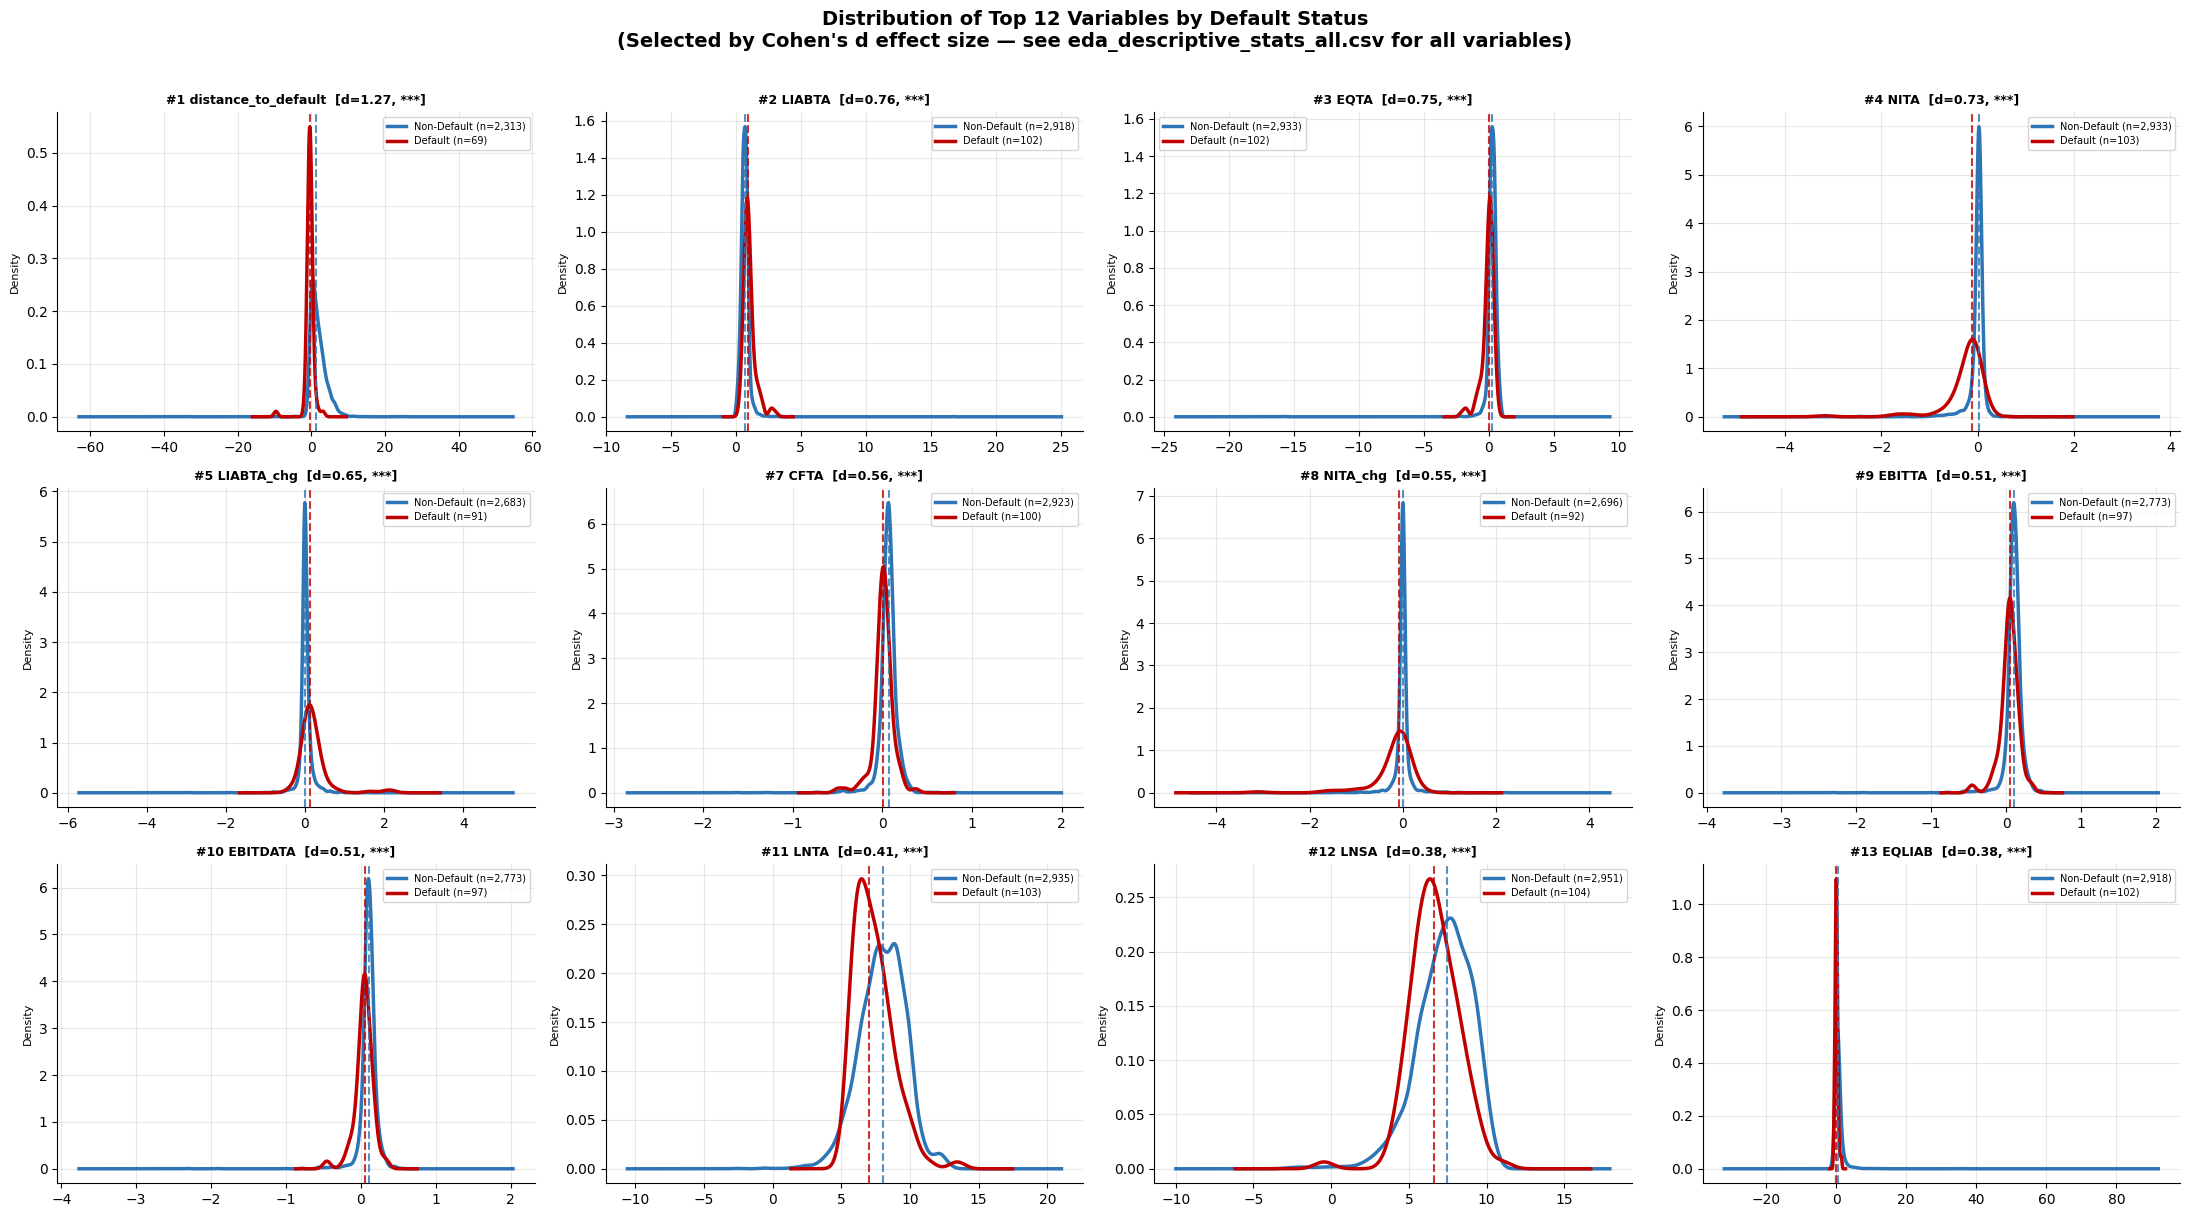

Saved: eda_02_distributions.png
Variables shown: top 12 by Cohen's d (rank shown in subtitle of each panel)


In [19]:
print("EDA Figure 2: KDE Distributions — Top 12 variables by Cohen's d")

n_cols = 4
n_rows = int(np.ceil(TOP_N / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows*4))
axes = axes.flatten()
fig.suptitle(
    f'Distribution of Top {TOP_N} Variables by Default Status\n'
    f'(Selected by Cohen\'s d effect size — see eda_descriptive_stats_all.csv for all variables)',
    fontsize=14, fontweight='bold', y=1.01)

for ax_idx, var in enumerate(TOP_VARS_DIST):
    ax   = axes[ax_idx]
    row  = eda_stats[eda_stats.Variable == var].iloc[0]
    d0   = p[p.y_default==0][var].dropna()
    d1   = p[p.y_default==1][var].dropna()

    if len(d0)>10 and d0.std()>0:
        d0.plot.kde(ax=ax, color=C_NODEF, lw=2.5,
                    label=f'Non-Default (n={len(d0):,})')
    if len(d1)>5 and d1.std()>0:
        d1.plot.kde(ax=ax, color=C_DEF, lw=2.5,
                    label=f'Default (n={len(d1):,})')

    ax.axvline(d0.median(), color=C_NODEF, ls='--', lw=1.5, alpha=0.8)
    ax.axvline(d1.median(), color=C_DEF,   ls='--', lw=1.5, alpha=0.8)

    ax.set_title(f'#{int(row.Rank)} {var}  [d={row.Cohens_d:.2f}, {row.Sig}]',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=8)

# Hide unused axes
for ax in axes[TOP_N:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_02_distributions.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: eda_02_distributions.png")
print(f"Variables shown: top {TOP_N} by Cohen's d (rank shown in subtitle of each panel)")

## EDA 4 — Box Plots with Significance Annotations

## EDA Figure 3 — Box Plots (Top 12 by Cohen's d)
Same objective selection as Figure 2. Notched boxes show 95% CI around median. Significance brackets show Mann-Whitney result.

EDA Figure 3: Box Plots — Top 12 variables by Cohen's d


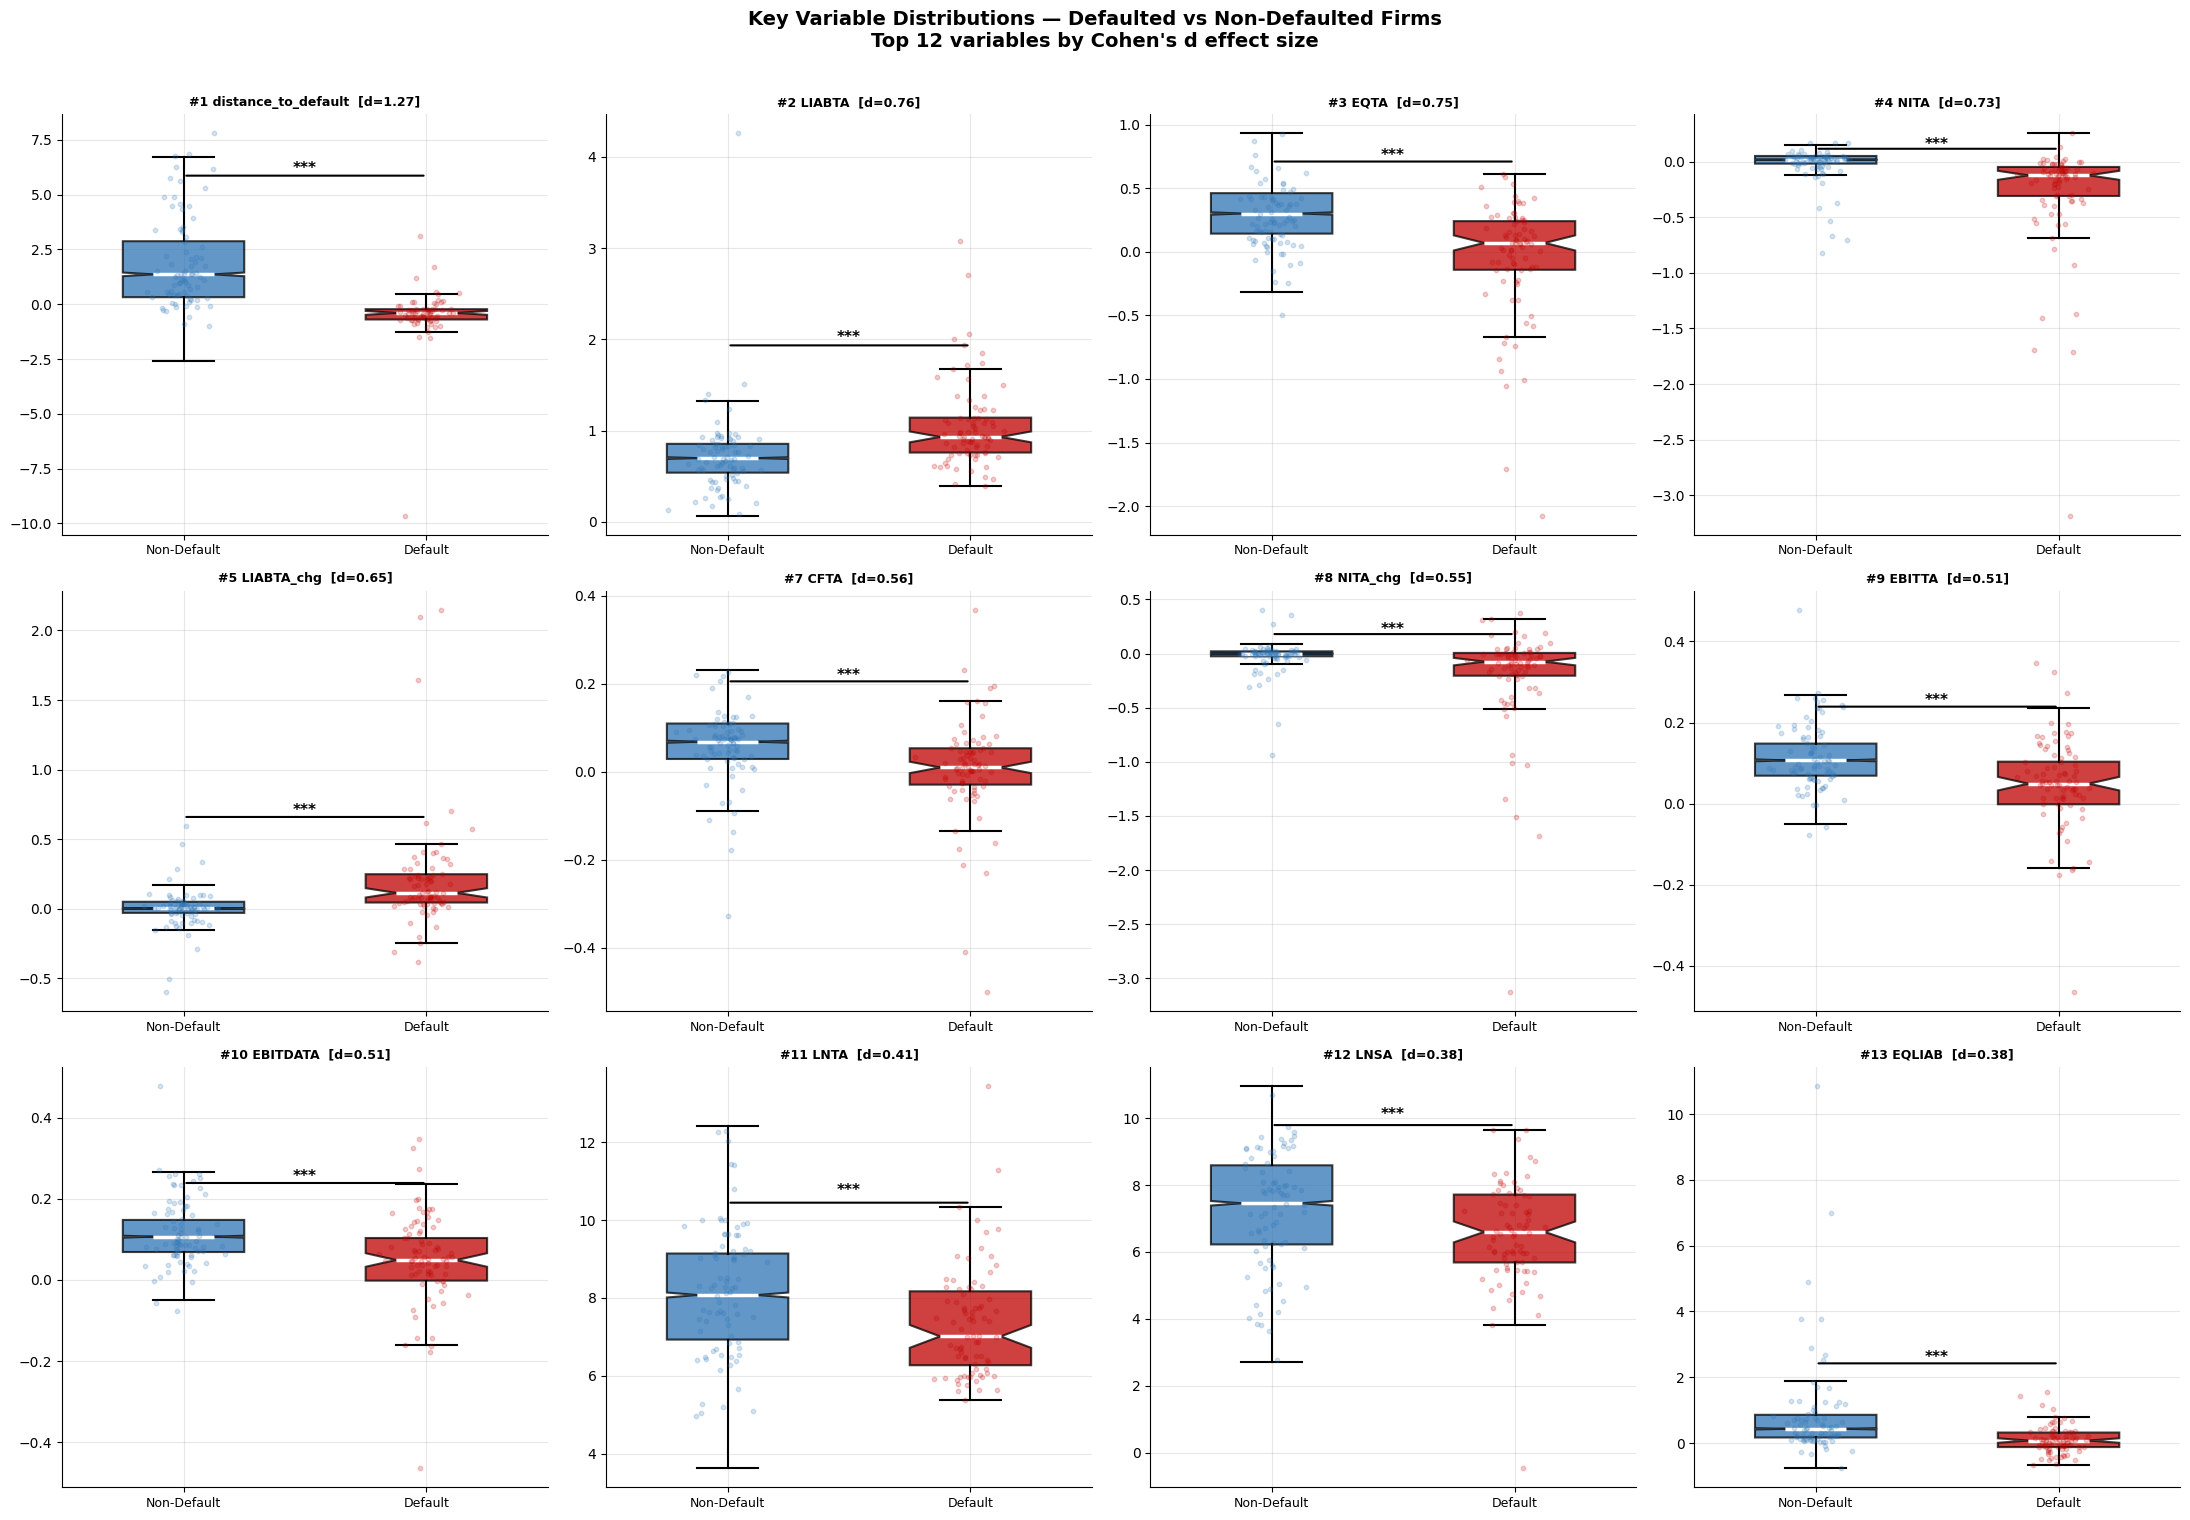

Saved: eda_03_boxplots.png
Variables shown: top 12 by Cohen's d


In [20]:
print("EDA Figure 3: Box Plots — Top 12 variables by Cohen's d")

n_cols = 4
n_rows = int(np.ceil(TOP_BOX / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows*5))
axes = axes.flatten()
fig.suptitle(
    f'Key Variable Distributions — Defaulted vs Non-Defaulted Firms\n'
    f'Top {TOP_BOX} variables by Cohen\'s d effect size',
    fontsize=14, fontweight='bold', y=1.01)

for ax_idx, var in enumerate(TOP_VARS_BOX):
    ax  = axes[ax_idx]
    row = eda_stats[eda_stats.Variable == var].iloc[0]
    d0  = p[p.y_default==0][var].dropna()
    d1  = p[p.y_default==1][var].dropna()

    bp = ax.boxplot([d0, d1], patch_artist=True, notch=True, widths=0.5,
                    showfliers=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    bp['boxes'][0].set_facecolor(C_NODEF); bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(C_DEF);   bp['boxes'][1].set_alpha(0.75)

    # Jittered points
    for i, (d, c) in enumerate([(d0, C_NODEF),(d1, C_DEF)], 1):
        sample = d.sample(min(80, len(d)), random_state=42)
        ax.scatter(np.random.normal(i, 0.06, len(sample)), sample,
                   alpha=0.2, s=10, color=c, zorder=3)

    # Significance bracket
    y_max = max(d0.quantile(0.95), d1.quantile(0.95))
    ax.annotate('', xy=(2, y_max), xytext=(1, y_max),
                arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
    ax.text(1.5, y_max*1.02 if y_max > 0 else y_max - abs(y_max)*0.05,
            row.Sig, ha='center', fontsize=11, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Non-Default', 'Default'], fontsize=9)
    ax.set_title(f'#{int(row.Rank)} {var}  [d={row.Cohens_d:.2f}]',
                 fontweight='bold', fontsize=9)

for ax in axes[TOP_BOX:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_03_boxplots.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: eda_03_boxplots.png")
print(f"Variables shown: top {TOP_BOX} by Cohen's d")

## EDA 5 — Correlation Heatmap

## EDA Figure 4 — Correlation Analysis: Full Matrix + High-Correlation Pairs
**Figure 4a:** Complete correlation heatmap for all variables.
**Figure 4b:** Focused heatmap — only variables with at least one |r| ≥ 0.60 pair.
**Table:** All high-correlation pairs ranked by absolute correlation. Saved to eda_high_correlation_pairs.csv.

EDA Figure 4a: Full Correlation Matrix — all ratio variables
EDA Figure 4b: High-Correlation Pairs Table (|r| >= 0.60)


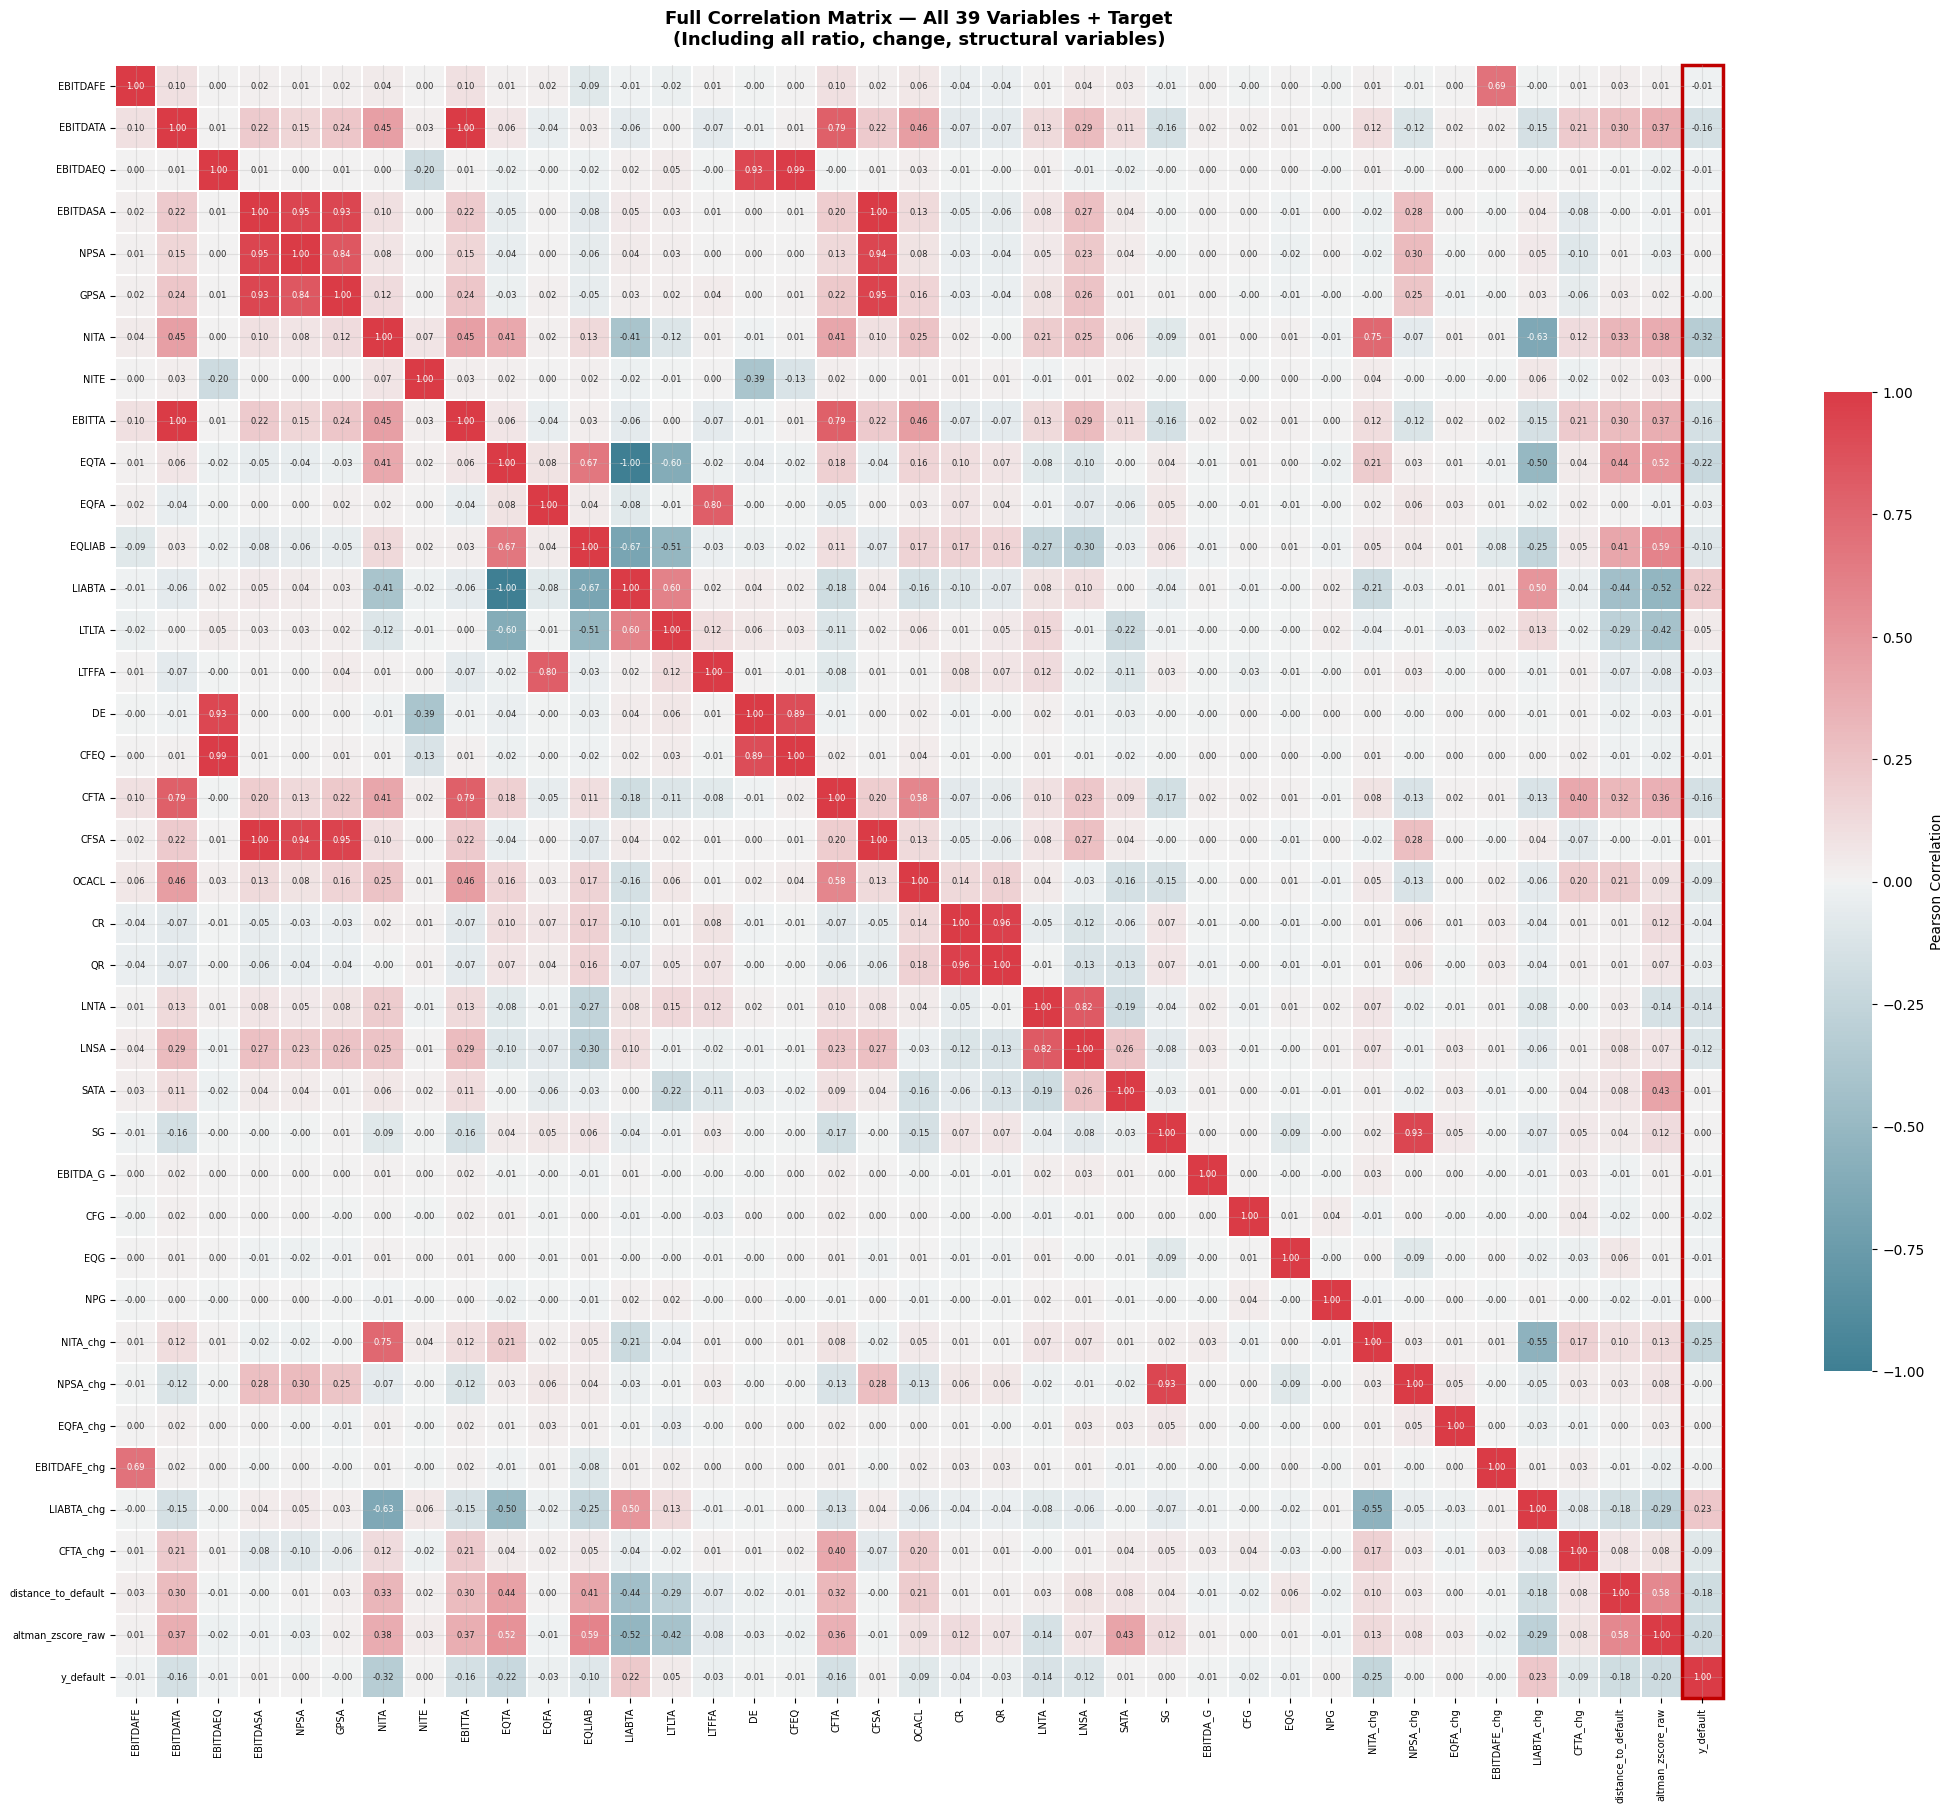

Saved: eda_04a_correlation_full.png

High-Correlation Pairs (|r| >= 0.6):
Variable 1             Variable 2                    r  Concern
─────────────────────────────────────────────────────────────────
EBITDATA               EBITTA                   1.0000  ⚠ HIGH
EQTA                   LIABTA                  -1.0000  ⚠ HIGH
EBITDASA               CFSA                     0.9980  ⚠ HIGH
EBITDAEQ               CFEQ                     0.9881  ⚠ HIGH
CR                     QR                       0.9620  ⚠ HIGH
GPSA                   CFSA                     0.9480  ⚠ HIGH
EBITDASA               NPSA                     0.9453  ⚠ HIGH
NPSA                   CFSA                     0.9357  ⚠ HIGH
SG                     NPSA_chg                 0.9350  ⚠ HIGH
EBITDASA               GPSA                     0.9308  ⚠ HIGH
EBITDAEQ               DE                       0.9261  ⚠ HIGH
DE                     CFEQ                     0.8923  ⚠ HIGH
NPSA                   GPSA             

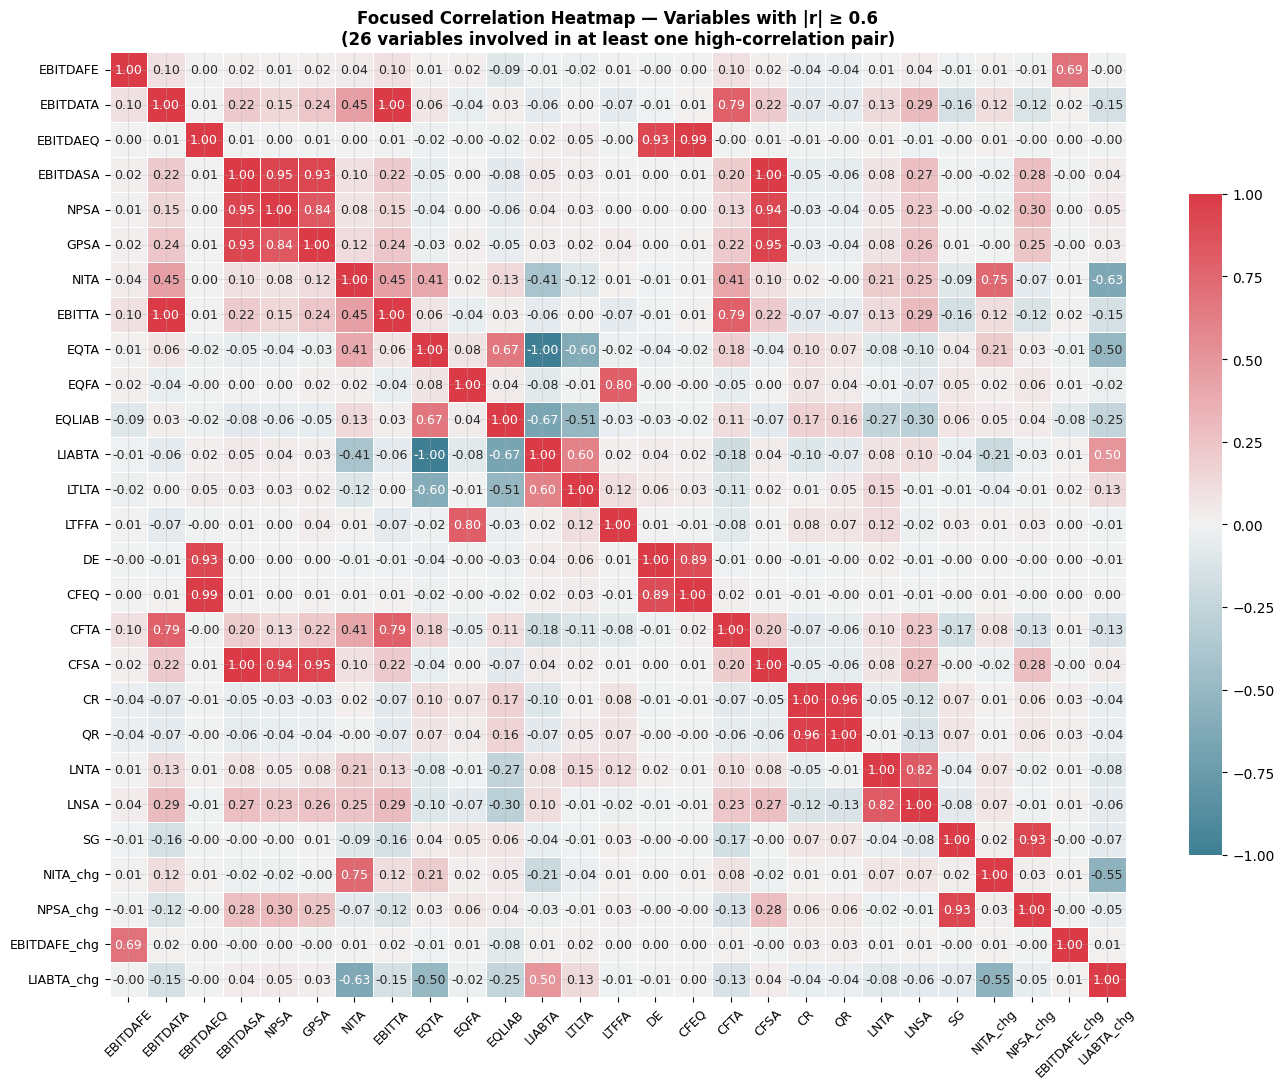

Saved: eda_04b_correlation_focused.png

Methodological note: Multicollinearity addressed via L2 regularisation
(C=0.1) in Logistic Regression. Tree models (RF, XGB, LGB) are robust
to correlated features. No variables dropped — full Mushtaq Ahmad (2026)
variable set retained for comparability with source study.


In [21]:
print("EDA Figure 4a: Full Correlation Matrix — all ratio variables")
print("EDA Figure 4b: High-Correlation Pairs Table (|r| >= 0.60)")

#  All variables for correlation
corr_all_vars = [v for v in ALL_VARS if v in p.columns]
corr_df  = p[corr_all_vars + ['y_default']].dropna()
corr_mat = corr_df.corr()

#  Figure 4a: Full heatmap
n_vars = len(corr_mat)
fig_size = max(18, n_vars * 0.55)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 6}, linewidths=0.3,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson Correlation'})
ax.set_title(
    f'Full Correlation Matrix — All {n_vars} Variables + Target\n'
    f'(Including all ratio, change, structural variables)',
    fontweight='bold', fontsize=13, pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

# Highlight target variable (last column/row)
ax.add_patch(plt.Rectangle(
    (n_vars-1, 0), 1, n_vars,
    fill=False, edgecolor=C_DEF, lw=2.5, clip_on=False))

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_04a_correlation_full.png', dpi=130,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_04a_correlation_full.png")

#  High-correlation pairs table (|r| >= 0.60)
CORR_THRESHOLD = 0.60
pairs = []
vars_list = corr_mat.columns.tolist()
for i in range(len(vars_list)):
    for j in range(i+1, len(vars_list)):
        r = corr_mat.iloc[i, j]
        if abs(r) >= CORR_THRESHOLD:
            pairs.append({
                'Variable_1': vars_list[i],
                'Variable_2': vars_list[j],
                'Correlation': round(r, 4),
                'Abs_Corr':   round(abs(r), 4),
                'Concern':    'High' if abs(r) >= 0.80 else 'Moderate',
            })

pairs_df = pd.DataFrame(pairs).sort_values('Abs_Corr', ascending=False).reset_index(drop=True)
pairs_df.to_csv(f'{OUTPUT}/eda_high_correlation_pairs.csv', index=False)

print(f"\nHigh-Correlation Pairs (|r| >= {CORR_THRESHOLD}):")
print(f"{'Variable 1':<22} {'Variable 2':<22} {'r':>8}  Concern")
print('─'*65)
for _, row in pairs_df.iterrows():
    flag = '⚠ HIGH' if row.Concern == 'High' else ''
    print(f"{row.Variable_1:<22} {row.Variable_2:<22} {row.Correlation:>8.4f}  {flag}")

n_high = (pairs_df.Concern == 'High').sum()
print(f"\nTotal pairs >= 0.60: {len(pairs_df)}")
print(f"Pairs >= 0.80 (high concern): {n_high}")
print(f"Saved: eda_high_correlation_pairs.csv")

# ── Figure 4b: Focused heatmap — only high-corr variables
# Show only the variables involved in at least one high-corr pair
involved = set(pairs_df.Variable_1.tolist() + pairs_df.Variable_2.tolist())
focused_vars = [v for v in corr_all_vars + ['y_default'] if v in involved]
corr_focused = corr_df[focused_vars].corr()

fig2, ax2 = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_focused, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, ax=ax2,
            annot_kws={'size': 9}, linewidths=0.5,
            cbar_kws={'shrink': 0.7})
ax2.set_title(
    f'Focused Correlation Heatmap — Variables with |r| ≥ {CORR_THRESHOLD}\n'
    f'({len(focused_vars)-1} variables involved in at least one high-correlation pair)',
    fontweight='bold', fontsize=12)
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_04b_correlation_focused.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_04b_correlation_focused.png")
print("\nMethodological note: Multicollinearity addressed via L2 regularisation")
print("(C=0.1) in Logistic Regression. Tree models (RF, XGB, LGB) are robust")
print("to correlated features. No variables dropped — full Mushtaq Ahmad (2026)")
print("variable set retained for comparability with source study.")

## EDA 6 — Financial Ratio Trends Over Time by Default Status

## EDA Figure 5 — Financial Ratio Trends Over Time (Top 9 by Cohen's d)
Top 9 variables by effect size shown. Shaded area = ±1 standard error. Grey vertical bands mark recession years (2001–02, 2008–09, 2020).

EDA Figure 5: Financial Ratio Trends — Top 9 variables by Cohen's d


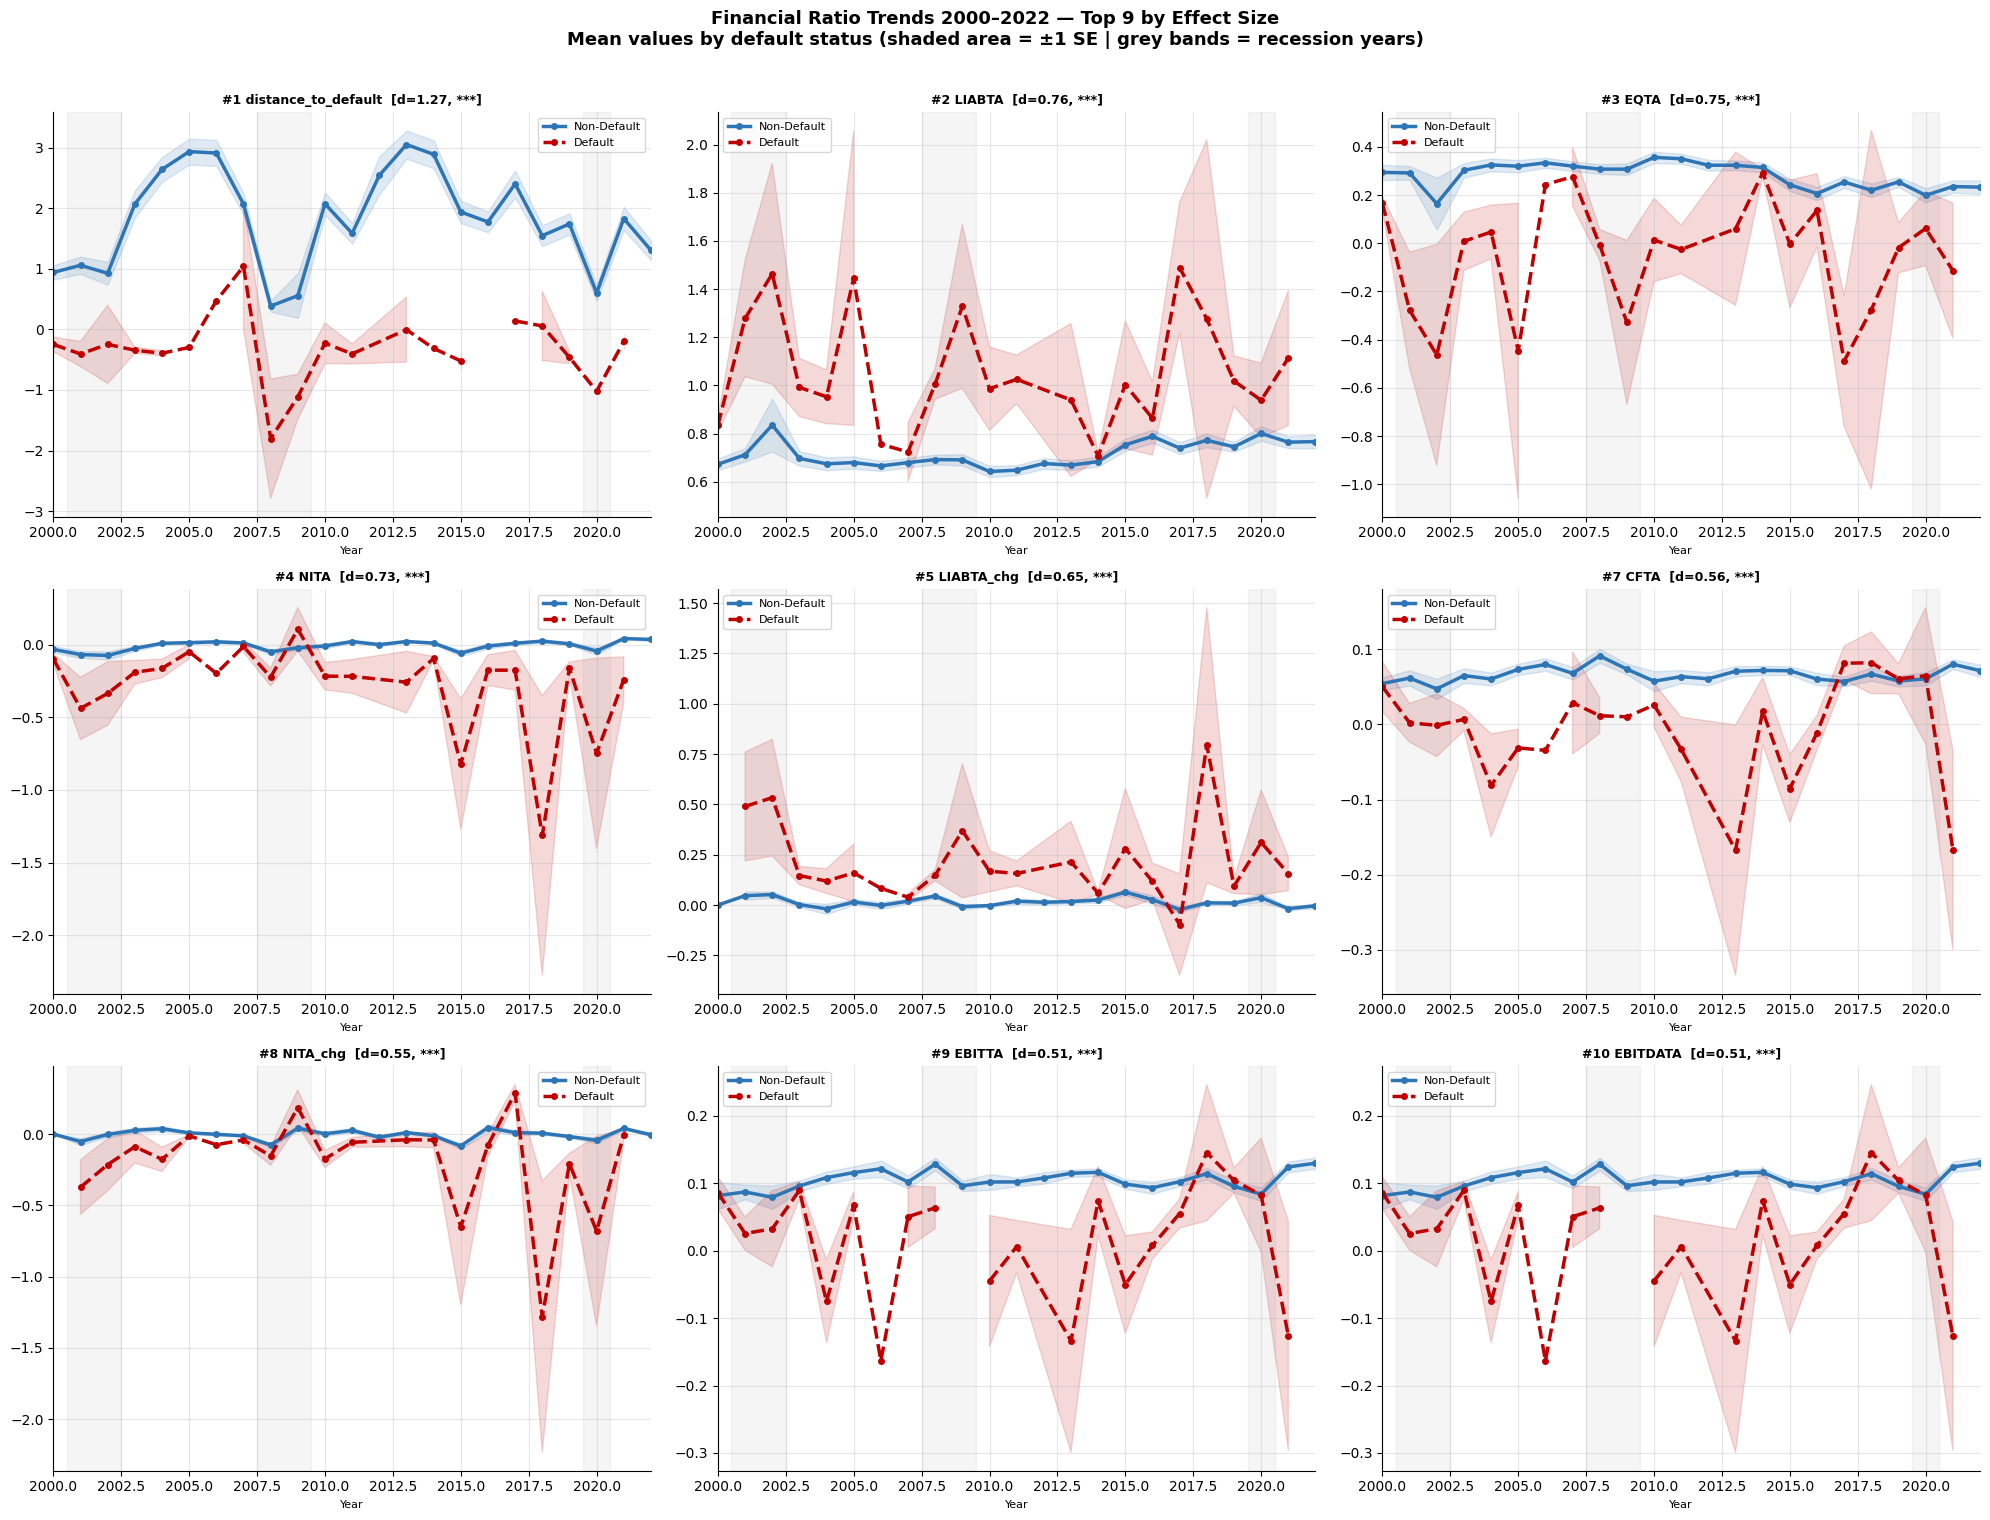

Saved: eda_05_trends.png
Variables shown: top 9 by Cohen's d
All 38 variable trends computable from eda_descriptive_stats_all.csv


In [22]:
print(f"EDA Figure 5: Financial Ratio Trends — Top {TOP_TREND} variables by Cohen's d")

n_cols = 3
n_rows = int(np.ceil(TOP_TREND / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*5))
axes = axes.flatten()
fig.suptitle(
    f'Financial Ratio Trends 2000–2022 — Top {TOP_TREND} by Effect Size\n'
    f'Mean values by default status (shaded area = ±1 SE | grey bands = recession years)',
    fontsize=13, fontweight='bold', y=1.01)

RECESSION_BANDS = [(2001, 2002, 'Dot-com'),
                   (2008, 2009, 'GFC'),
                   (2020, 2020, 'COVID')]

for ax_idx, var in enumerate(TOP_VARS_TREND):
    ax  = axes[ax_idx]
    row = eda_stats[eda_stats.Variable == var].iloc[0]

    for val, label, col, ls in [
        (0, 'Non-Default', C_NODEF, '-'),
        (1, 'Default',     C_DEF,   '--')
    ]:
        grp = p[p.y_default==val].groupby('Year')[var].agg(['mean','sem'])
        if len(grp) > 2:
            ax.plot(grp.index, grp['mean'], color=col, lw=2.5,
                    ls=ls, marker='o', ms=4, label=label)
            ax.fill_between(grp.index,
                             grp['mean'] - grp['sem'],
                             grp['mean'] + grp['sem'],
                             alpha=0.15, color=col)

    for yr_s, yr_e, rec_label in RECESSION_BANDS:
        ax.axvspan(yr_s-0.5, yr_e+0.5, alpha=0.08, color='grey')

    ax.set_title(f'#{int(row.Rank)} {var}  [d={row.Cohens_d:.2f}, {row.Sig}]',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Year', fontsize=8)
    ax.legend(fontsize=8)
    ax.set_xlim([2000, 2022])

for ax in axes[TOP_TREND:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_05_trends.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: eda_05_trends.png")
print(f"Variables shown: top {TOP_TREND} by Cohen's d")
print(f"All {len(eda_stats)} variable trends computable from eda_descriptive_stats_all.csv")

## EDA 7 — Missing Data Analysis

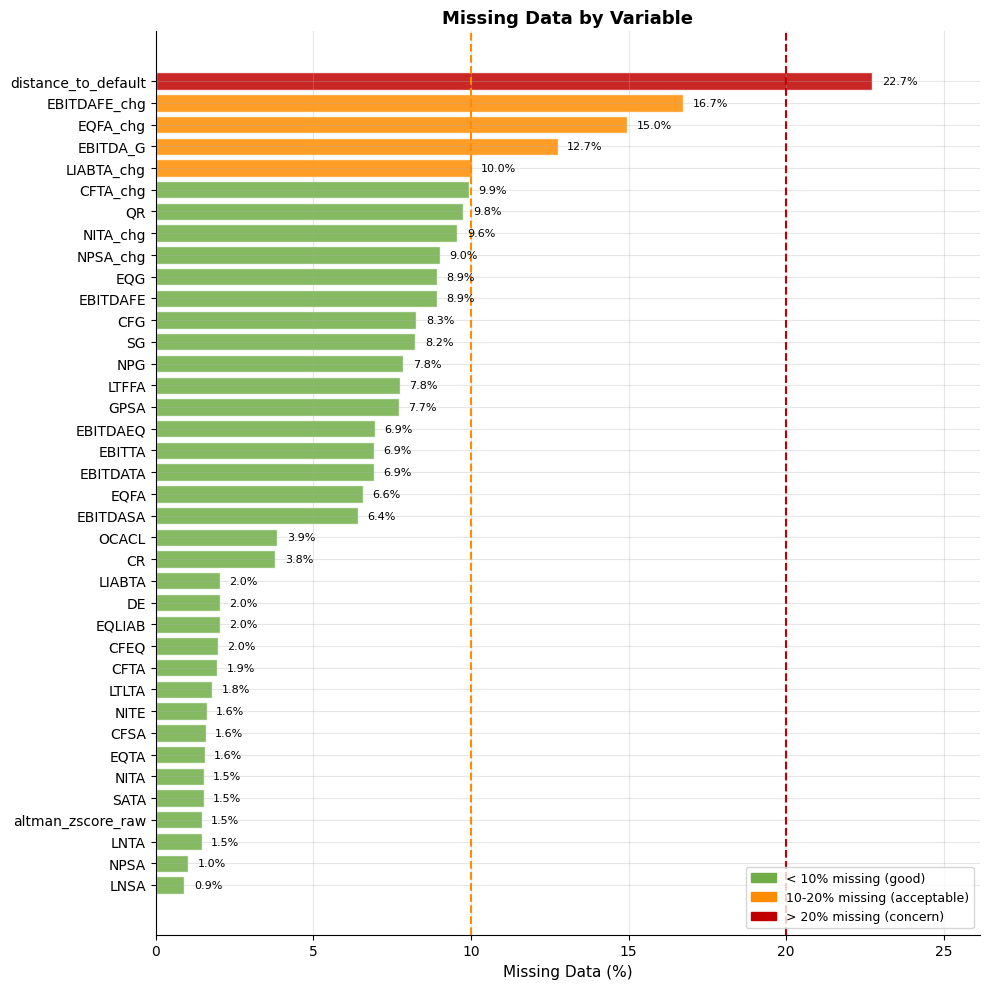

Saved: eda_06_missing_data.png


In [23]:
miss_pct = p[RATIO_VARS + ['distance_to_default','altman_zscore_raw']].isna().mean()*100
miss_pct = miss_pct.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors  = [C_DEF if v>20 else C_WARN if v>10 else C_NEUT for v in miss_pct.values]
bars    = ax.barh(miss_pct.index, miss_pct.values, color=colors, alpha=0.85, edgecolor='white')

ax.axvline(10, color=C_WARN, ls='--', lw=1.5, label='10% threshold')
ax.axvline(20, color=C_DEF,  ls='--', lw=1.5, label='20% threshold')

for bar, val in zip(bars, miss_pct.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Missing Data (%)', fontsize=11)
ax.set_title('Missing Data by Variable', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, max(miss_pct.values)*1.15])

patches = [mpatches.Patch(color=C_NEUT, label='< 10% missing (good)'),
           mpatches.Patch(color=C_WARN, label='10-20% missing (acceptable)'),
           mpatches.Patch(color=C_DEF,  label='> 20% missing (concern)')]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_06_missing_data.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_06_missing_data.png")

## EDA 8 — Change Variable Analysis (Financial Deterioration Trajectories)

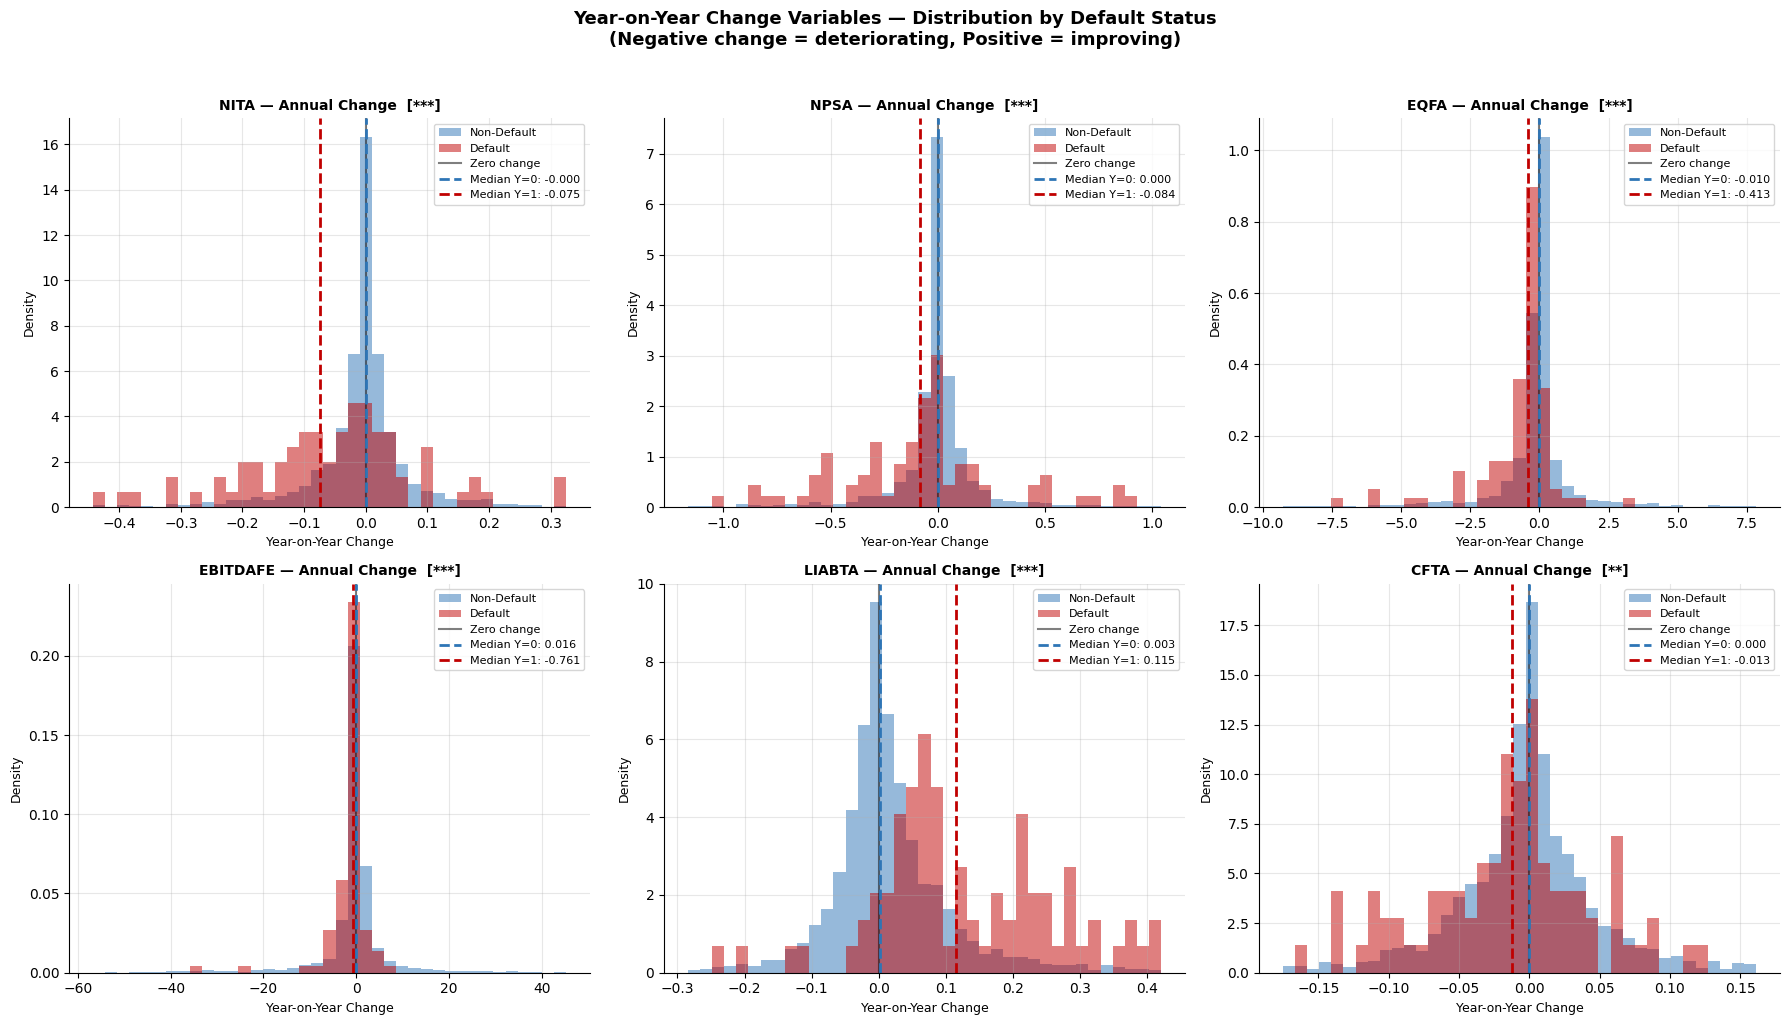

Saved: eda_07_change_vars.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Year-on-Year Change Variables — Distribution by Default Status\n'
             '(Negative change = deteriorating, Positive = improving)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, var in zip(axes, CHANGE_VARS):
    chg_col = f'{var}_chg'
    if chg_col not in p.columns: continue
    d0 = p[p.y_default==0][chg_col].dropna()
    d1 = p[p.y_default==1][chg_col].dropna()

    bins = np.linspace(p[chg_col].quantile(0.02), p[chg_col].quantile(0.98), 40)
    ax.hist(d0, bins=bins, alpha=0.5, color=C_NODEF, density=True, label='Non-Default')
    ax.hist(d1, bins=bins, alpha=0.5, color=C_DEF,   density=True, label='Default')
    ax.axvline(0, color='black', lw=1.5, ls='-', alpha=0.5, label='Zero change')
    ax.axvline(d0.median(), color=C_NODEF, lw=2, ls='--', label=f'Median Y=0: {d0.median():.3f}')
    ax.axvline(d1.median(), color=C_DEF,   lw=2, ls='--', label=f'Median Y=1: {d1.median():.3f}')

    if len(d0)>5 and len(d1)>5:
        _, pv = mannwhitneyu(d0, d1, alternative='two-sided')
        sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        ax.set_title(f'{var} — Annual Change  [{sig}]', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Year-on-Year Change', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_07_change_vars.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_07_change_vars.png")

## EDA 9 — Altman Z-Score Zone Analysis

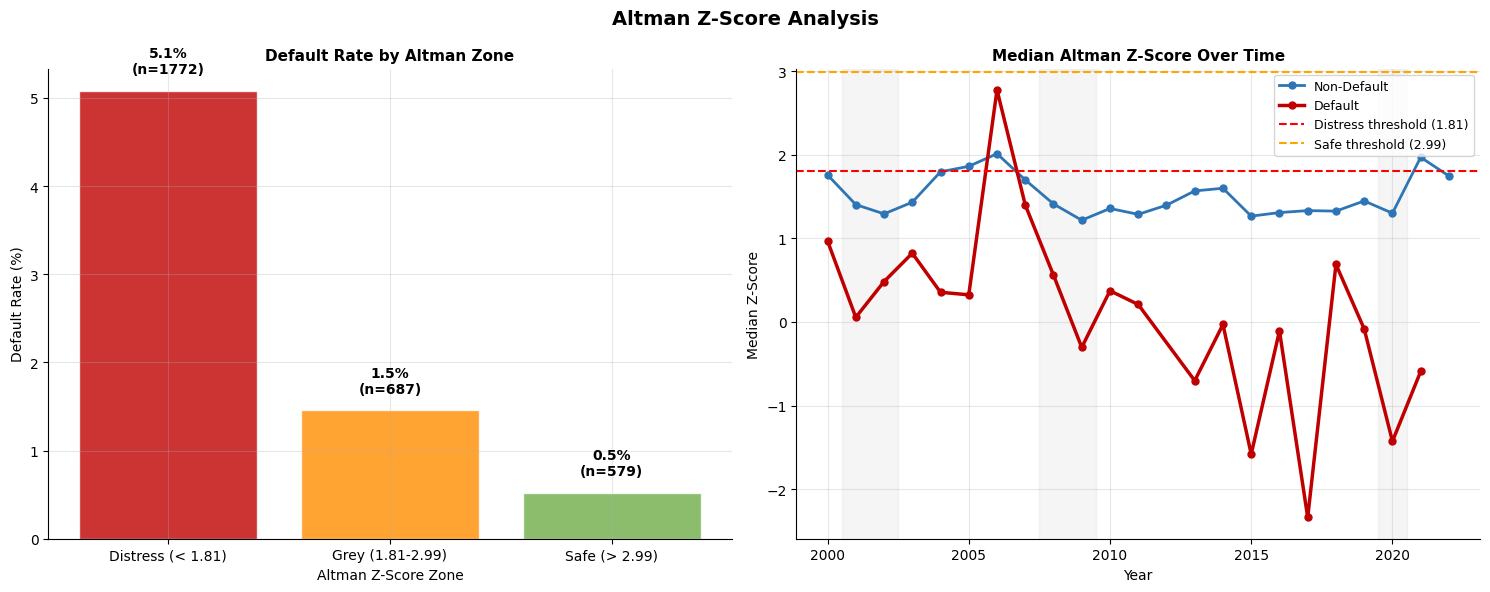

Saved: eda_08_altman.png


In [25]:
p['altman_zone'] = pd.cut(p['altman_zscore_raw'],
                           bins=[-np.inf, 1.81, 2.99, np.inf],
                           labels=['Distress (< 1.81)','Grey (1.81-2.99)','Safe (> 2.99)'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Altman Z-Score Analysis", fontsize=14, fontweight='bold')

# Left: Default rate by Altman zone
ax = axes[0]
zone_def = p.groupby('altman_zone', observed=True)['y_default'].agg(['mean','sum','count'])
zone_def['rate'] = zone_def['mean']*100
colors_z = [C_DEF, C_WARN, C_NEUT]
bars = ax.bar(zone_def.index, zone_def['rate'], color=colors_z, alpha=0.8, edgecolor='white')
for bar, (idx, row) in zip(bars, zone_def.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{row['rate']:.1f}%\n(n={row['count']:.0f})",
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Default Rate by Altman Zone', fontweight='bold', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=10)
ax.set_xlabel('Altman Z-Score Zone', fontsize=10)

# Right: Z-score distribution over time for defaulted vs non-defaulted
ax = axes[1]
for val, label, col, lw in [(0,'Non-Default',C_NODEF,2),(1,'Default',C_DEF,2.5)]:
    trend = p[p.y_default==val].groupby('Year')['altman_zscore_raw'].median()
    ax.plot(trend.index, trend.values, color=col, lw=lw, marker='o', ms=5, label=label)
ax.axhline(1.81, color='red',    ls='--', lw=1.5, label='Distress threshold (1.81)')
ax.axhline(2.99, color='orange', ls='--', lw=1.5, label='Safe threshold (2.99)')
for yr_s, yr_e in [(2001,2002),(2008,2009),(2020,2020)]:
    ax.axvspan(yr_s-0.5, yr_e+0.5, alpha=0.08, color='grey')
ax.set_title('Median Altman Z-Score Over Time', fontweight='bold', fontsize=11)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Median Z-Score', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_08_altman.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_08_altman.png")

---
# SECTION C — FEATURE ENGINEERING & MODELLING PREPARATION

## Step 9 — Pull FRED Macro Data

In [26]:
print("="*55)
print("STEP 9: FRED MACRO DATA")
print("="*55)

MACRO_COLS = ['gdp_growth','fed_funds_rate','treasury_10yr','treasury_2yr',
              'hy_spread','vix','inflation_rate','unemployment','nfci','yield_curve_slope']

if FRED_API_KEY == 'PASTE_YOUR_FRED_API_KEY_HERE':
    print("SKIPPED — paste your FRED key in Cell 3.")
    print("Get free key at: https://fred.stlouisfed.org/docs/api/api_key.html")
    for col in MACRO_COLS:
        p[col] = np.nan
else:
    from fredapi import Fred
    fred = Fred(api_key=FRED_API_KEY)
    SERIES = {
        'gdp_growth':     'A191RL1A225NBEA',
        'fed_funds_rate': 'FEDFUNDS',
        'treasury_10yr':  'GS10',
        'treasury_2yr':   'GS2',
        'hy_spread':      'BAMLH0A0HYM2',
        'vix':            'VIXCLS',
        'cpi':            'CPIAUCSL',
        'unemployment':   'UNRATE',
        'nfci':           'NFCI',
    }
    macro = {}
    for name, sid in SERIES.items():
        try:
            s = fred.get_series(sid,
                observation_start='2000-01-01',
                observation_end='2022-12-31')
            s.index = pd.to_datetime(s.index)
            annual  = s.resample('YE').mean()
            annual.index = annual.index.year
            macro[name] = annual
            print(f"  OK  {name}")
        except Exception as e:
            print(f"  ERR {name}: {e}")
    macro_df = pd.DataFrame(macro).reset_index().rename(columns={'index':'Year'})
    macro_df = macro_df[(macro_df.Year>=2000)&(macro_df.Year<=2022)]
    if 'treasury_10yr' in macro_df and 'treasury_2yr' in macro_df:
        macro_df['yield_curve_slope'] = macro_df['treasury_10yr'] - macro_df['treasury_2yr']
    if 'cpi' in macro_df.columns:
        macro_df['inflation_rate'] = macro_df['cpi'].pct_change()*100
        macro_df = macro_df.drop(columns=['cpi'])
    macro_df.to_csv(f'{DATA}/macro_panel.csv', index=False)
    p = p.merge(macro_df, on='Year', how='left')
    print(f"Macro data merged.")

p.to_csv(f'{DATA}/panel_cleaned.csv', index=False)
print(f"Cleaned panel saved: {DATA}/panel_cleaned.csv")

STEP 9: FRED MACRO DATA
  OK  gdp_growth
  OK  fed_funds_rate
  ERR treasury_10yr: Too Many Requests.  Exceeded Rate Limit
  OK  treasury_2yr
  OK  hy_spread
  OK  vix
  OK  cpi
  OK  unemployment
  OK  nfci
Macro data merged.
Cleaned panel saved: /content/drive/MyDrive/DBA/Research/data/panel_cleaned.csv


## Step 10 — Time-Based Train/Test Split

In [27]:
print("="*55)
print("STEP 10: TRAIN/TEST SPLIT")
print("="*55)

train = p[p['Year'] <= TRAIN_END].copy()
test  = p[p['Year'] >= TEST_START].copy()

print(f"Train (2000-{TRAIN_END}): {len(train):,} rows | {train.y_default.sum()} defaults ({train.y_default.mean()*100:.2f}%)")
print(f"Test  ({TEST_START}-2022): {len(test):,}  rows | {test.y_default.sum()} defaults ({test.y_default.mean()*100:.2f}%)")

# FIX: WINSORISATION — derived from training set only
# Rationale: winsorisation bounds must be computed on training data only.
# Applying full-panel percentiles before the split allows test-set values to
# influence training-data clipping — a form of data leakage.
# Solution: compute 1st/99th percentile on train, apply same bounds to test.
print(f"\nApplying winsorisation (bounds from training set only)...")

win_bounds = {}  # Store bounds for documentation / reproducibility
for col in WIN_COLS:
    if col not in train.columns:
        continue
    lb = train[col].quantile(0.01)  # derived from TRAIN only
    ub = train[col].quantile(0.99)  # derived from TRAIN only
    win_bounds[col] = {'lb': lb, 'ub': ub}
    train[col] = train[col].clip(lower=lb, upper=ub)
    test[col]  = test[col].clip(lower=lb, upper=ub)   # same bounds applied to test

# altman_zscore_raw stays unwinsorized for benchmark comparability
print(f"Winsorized {len(win_bounds)} variables at 1st/99th percentile (training bounds)")
print(f"Same bounds applied to test set — no test information used in bound computation")
print(f"altman_zscore_raw: unwinsorized (benchmark comparability with published studies)")


STEP 10: TRAIN/TEST SPLIT
Train (2000-2017): 2,609 rows | 79 defaults (3.03%)
Test  (2018-2022): 474  rows | 25 defaults (5.27%)

Applying winsorisation (bounds from training set only)...
Winsorized 42 variables at 1st/99th percentile (training bounds)
Same bounds applied to test set — no test information used in bound computation
altman_zscore_raw: unwinsorized (benchmark comparability with published studies)


## Step 11 — Define Feature Sets

In [28]:
print("="*55)
print("STEP 11: FEATURE SETS")
print("="*55)

BASE_FEATURES = [
    'EBITDAFE','EBITDATA','EBITDAEQ','EBITDASA','NPSA','GPSA','NITA','NITE','EBITTA',
    'EQTA','EQFA','EQLIAB','LIABTA','LTLTA','LTFFA','DE',
    'CFEQ','CFTA','CFSA','OCACL','CR','QR','LNTA','LNSA','SATA',
    'SG','EBITDA_G','CFG','EQG','NPG'
] + CHANGE_FEATURES

FEAT_WITH_DD    = BASE_FEATURES + ['distance_to_default']
MACRO_FEAT      = ['gdp_growth','fed_funds_rate','yield_curve_slope',
                   'hy_spread','vix','unemployment','nfci','inflation_rate']
FEAT_WITH_MACRO = FEAT_WITH_DD + MACRO_FEAT

def filter_coverage(features, df, threshold=0.30):
    return [f for f in features
            if f in df.columns and df[f].notna().mean() >= threshold]

FEAT_SET1 = filter_coverage(BASE_FEATURES,  train)
FEAT_SET2 = filter_coverage(FEAT_WITH_DD,   train)
FEAT_SET3 = filter_coverage(FEAT_WITH_MACRO,train)

print(f"Set 1 — Accounting + Change vars:     {len(FEAT_SET1)} features")
print(f"Set 2 — + Distance to Default:        {len(FEAT_SET2)} features")
print(f"Set 3 — + Macroeconomic variables:    {len(FEAT_SET3)} features")
print(f"DD in Set 2: {'distance_to_default' in FEAT_SET2}")
print(f"\nChange features in Set 1:")
for f in CHANGE_FEATURES:
    if f in FEAT_SET1:
        print(f"  {f}: {train[f].notna().mean()*100:.1f}% coverage")

STEP 11: FEATURE SETS
Set 1 — Accounting + Change vars:     36 features
Set 2 — + Distance to Default:        37 features
Set 3 — + Macroeconomic variables:    43 features
DD in Set 2: True

Change features in Set 1:
  NITA_chg: 88.7% coverage
  NPSA_chg: 89.4% coverage
  EQFA_chg: 83.4% coverage
  EBITDAFE_chg: 81.4% coverage
  LIABTA_chg: 88.2% coverage
  CFTA_chg: 88.3% coverage


## Step 12 — Model Infrastructure (SMOTE inside CV folds)

## Step 12 — Model Infrastructure (SMOTE-ENN inside CV folds)

In [29]:
print("="*55)
print("STEP 12: MODEL INFRASTRUCTURE")
print("  SMOTE-ENN inside CV folds (replaces SMOTE)")
print("  Bayesian hyperparameter tuning (Set 1 best model)")
print("="*55)

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.metrics          import (roc_auc_score, f1_score, precision_score,
                                      recall_score, brier_score_loss,
                                      classification_report, roc_curve)
from imblearn.pipeline        import Pipeline as ImbPipeline
from imblearn.combine         import SMOTEENN
import xgboost as xgb
import lightgbm as lgb

#  SMOTE-ENN CONFIGURATION
# SMOTE-ENN: oversamples minority + removes noisy borderline samples via ENN
# k_neighbors=3 (conservative) to avoid over-removing from scarce minority class
# ENN uses k=3 nearest neighbors to identify and remove misclassified samples
# Applied INSIDE each CV fold via ImbPipeline — no data leakage

def make_models(scale_pos):
    """
    Build model pipelines with SMOTE-ENN inside each fold.
    scale_pos: ratio of non-default to default in training set.
    k_smote conservatively set to min(3, n_minority-1) to handle small folds.
    """
    k = max(1, min(3, int(scale_pos)-1)) if scale_pos > 1 else 1
    smoteenn = SMOTEENN(random_state=42,
                        smote=__import__('imblearn.over_sampling',
                                         fromlist=['SMOTE']).SMOTE(
                                             k_neighbors=k, random_state=42),
                        enn=__import__('imblearn.under_sampling',
                                        fromlist=['EditedNearestNeighbours']).EditedNearestNeighbours(
                                            n_neighbors=3, kind_sel='mode'))
    return {
        'Logistic Regression': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    LogisticRegression(max_iter=1000, random_state=42, C=0.1))
        ]),
        'Random Forest': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    RandomForestClassifier(n_estimators=200, random_state=42,
                                                class_weight='balanced', max_depth=5))
        ]),
        'XGBoost': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    xgb.XGBClassifier(n_estimators=200, random_state=42,
                                            scale_pos_weight=scale_pos,
                                            max_depth=4, learning_rate=0.05,
                                            eval_metric='logloss', verbosity=0))
        ]),
        'LightGBM': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    lgb.LGBMClassifier(n_estimators=200, random_state=42,
                                             scale_pos_weight=scale_pos,
                                             max_depth=4, learning_rate=0.05,
                                             verbosity=-1))
        ]),
    }

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'AUC':       round(roc_auc_score(y_true, y_prob), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'Brier':     round(brier_score_loss(y_true, y_prob), 4),
    }

def run_model_set(feat_cols, set_name, train_df, test_df):
    print(f"\n--- {set_name} ({len(feat_cols)} features) ---")
    X_tr=train_df[feat_cols]; y_tr=train_df['y_default'].astype(int)
    X_te=test_df[feat_cols];  y_te=test_df['y_default'].astype(int)
    mask_tr=y_tr.notna(); X_tr=X_tr[mask_tr]; y_tr=y_tr[mask_tr].astype(int)
    mask_te=y_te.notna(); X_te=X_te[mask_te]; y_te=y_te[mask_te].astype(int)
    sp = max(1, (y_tr==0).sum() / max(1,(y_tr==1).sum()))
    models = make_models(sp)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results={}; fitted={}
    print(f"  {'Model':<22} {'CV-AUC':>7} {'Test-AUC':>9} {'F1':>7} {'Prec':>8} {'Recall':>8} {'Brier':>7}")
    print(f"  {'-'*75}")
    for name, pipe in models.items():
        cv_auc = cross_validate(pipe, X_tr, y_tr, cv=cv,
                                scoring='roc_auc')['test_score'].mean()
        pipe.fit(X_tr, y_tr); fitted[name] = pipe
        y_prob = pipe.predict_proba(X_te)[:,1]; y_pred = pipe.predict(X_te)
        m = compute_metrics(y_te, y_pred, y_prob)
        results[name] = {'CV_AUC': round(cv_auc,4), **m}
        print(f"  {name:<22} {cv_auc:>7.4f} {m['AUC']:>9.4f} {m['F1']:>7.4f} "
              f"{m['Precision']:>8.4f} {m['Recall']:>8.4f} {m['Brier']:>7.4f}")
    # Altman baseline
    z_raw  = test_df.loc[mask_te,'altman_zscore_raw'].fillna(
                 test_df['altman_zscore_raw'].median())
    z_pred = (z_raw < 1.81).astype(int)
    z_prob = 1/(1+np.exp(z_raw.values))
    z_auc  = roc_auc_score(y_te, -z_raw)
    z_m    = compute_metrics(y_te, z_pred, z_prob)
    results['Altman Z-Score'] = {'CV_AUC': None, 'AUC': z_auc, **z_m}
    print(f"  {'Altman Z-Score':<22} {'N/A':>7} {z_auc:>9.4f} {z_m['F1']:>7.4f} "
          f"{z_m['Precision']:>8.4f} {z_m['Recall']:>8.4f} {z_m['Brier']:>7.4f}")
    print(f"  {'-'*75}")
    return results, fitted, y_te, X_te

print("Model infrastructure ready.")
print("SMOTE-ENN applied inside each CV fold via ImbPipeline (no data leakage).")

STEP 12: MODEL INFRASTRUCTURE
  SMOTE-ENN inside CV folds (replaces SMOTE)
  Bayesian hyperparameter tuning (Set 1 best model)
Model infrastructure ready.
SMOTE-ENN applied inside each CV fold via ImbPipeline (no data leakage).


## Step 12b — Bayesian Hyperparameter Tuning (Set 1)

In [30]:
print("="*55)
print("STEP 12b: BAYESIAN HYPERPARAMETER TUNING")
print("  Applied to Set 1 (Accounting + Change) — best params carry forward")
print("  FIX: Full ImbPipeline (with SMOTE-ENN) passed into BayesSearchCV")
print("  This ensures tuning and final training run under identical conditions")
print("="*55)

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

X_tr_full = train[FEAT_SET1]
y_tr_full = train['y_default'].astype(int)
mask_tr   = y_tr_full.notna()
X_tr_full = X_tr_full[mask_tr]
y_tr_full = y_tr_full[mask_tr].astype(int)

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sp      = max(1, (y_tr_full==0).sum() / max(1,(y_tr_full==1).sum()))
N_ITER  = 20


print(f"  Training set: {len(X_tr_full):,} rows | {y_tr_full.sum()} defaults")
print(f"  Bayesian iterations: {N_ITER} per model | 5-fold stratified CV with SMOTE-ENN")
print()

tuned_params  = {}
tuned_models  = {}
tuned_searches = {}

#  1. Logistic Regression
print("  Tuning Logistic Regression...")
lr_pipe = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('model',    LogisticRegression(max_iter=2000, random_state=42, solver='saga'))
])
lr_search = BayesSearchCV(
    lr_pipe,
    {'model__C':       Real(1e-4, 10.0, prior='log-uniform'),
     'model__penalty': Categorical(['l1','l2'])},
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc',
    random_state=42, n_jobs=-1
)
lr_search.fit(X_tr_full, y_tr_full)
tuned_params['Logistic Regression'] = {'C': lr_search.best_params_['model__C'],
                                         'penalty': lr_search.best_params_['model__penalty']}
tuned_searches['Logistic Regression'] = lr_search
print(f"    Best params: {tuned_params['Logistic Regression']}")
print(f"    Best CV AUC: {lr_search.best_score_:.4f}")

#  2. Random Forest
print("  Tuning Random Forest...")
rf_pipe = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('model',    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])
rf_search = BayesSearchCV(
    rf_pipe,
    {'model__n_estimators':    Integer(100, 500),
     'model__max_depth':       Integer(3, 8),
     'model__min_samples_split': Integer(2, 20),
     'model__max_features':    Real(0.3, 1.0)},
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc', random_state=42
)
rf_search.fit(X_tr_full, y_tr_full)
tuned_params['Random Forest'] = {'n_estimators': rf_search.best_params_['model__n_estimators'],
                                   'max_depth': rf_search.best_params_['model__max_depth'],
                                   'min_samples_split': rf_search.best_params_['model__min_samples_split'],
                                   'max_features': rf_search.best_params_['model__max_features']}
tuned_searches['Random Forest'] = rf_search
print(f"    Best params: {tuned_params['Random Forest']}")
print(f"    Best CV AUC: {rf_search.best_score_:.4f}")

#  3. XGBoost
print("  Tuning XGBoost...")
xgb_pipe = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('model',    xgb.XGBClassifier(random_state=42, scale_pos_weight=sp,
                                     eval_metric='logloss', verbosity=0))
])
xgb_search = BayesSearchCV(
    xgb_pipe,
    {'model__n_estimators':    Integer(100, 400),
     'model__max_depth':       Integer(3, 7),
     'model__learning_rate':   Real(0.01, 0.3, prior='log-uniform'),
     'model__subsample':       Real(0.6, 1.0),
     'model__colsample_bytree':Real(0.6, 1.0),
     'model__reg_alpha':       Real(1e-4, 10.0, prior='log-uniform')},
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc', random_state=42
)
xgb_search.fit(X_tr_full, y_tr_full)
tuned_params['XGBoost'] = {'n_estimators': xgb_search.best_params_['model__n_estimators'],
                             'max_depth': xgb_search.best_params_['model__max_depth'],
                             'learning_rate': xgb_search.best_params_['model__learning_rate'],
                             'subsample': xgb_search.best_params_['model__subsample'],
                             'colsample_bytree': xgb_search.best_params_['model__colsample_bytree'],
                             'reg_alpha': xgb_search.best_params_['model__reg_alpha']}
tuned_searches['XGBoost'] = xgb_search
print(f"    Best params: {tuned_params['XGBoost']}")
print(f"    Best CV AUC: {xgb_search.best_score_:.4f}")

# 4. LightGBM
print("  Tuning LightGBM...")
lgb_pipe = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('model',    lgb.LGBMClassifier(random_state=42, scale_pos_weight=sp, verbosity=-1))
])
lgb_search = BayesSearchCV(
    lgb_pipe,
    {'model__n_estimators':  Integer(100, 400),
     'model__max_depth':     Integer(3, 7),
     'model__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
     'model__num_leaves':    Integer(15, 63),
     'model__subsample':     Real(0.6, 1.0),
     'model__reg_alpha':     Real(1e-4, 10.0, prior='log-uniform')},
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc', random_state=42
)
lgb_search.fit(X_tr_full, y_tr_full)
tuned_params['LightGBM'] = {'n_estimators': lgb_search.best_params_['model__n_estimators'],
                              'max_depth': lgb_search.best_params_['model__max_depth'],
                              'learning_rate': lgb_search.best_params_['model__learning_rate'],
                              'num_leaves': lgb_search.best_params_['model__num_leaves'],
                              'subsample': lgb_search.best_params_['model__subsample'],
                              'reg_alpha': lgb_search.best_params_['model__reg_alpha']}
tuned_searches['LightGBM'] = lgb_search
print(f"    Best params: {tuned_params['LightGBM']}")
print(f"    Best CV AUC: {lgb_search.best_score_:.4f}")

print(f"\nHyperparameter tuning complete (full ImbPipeline with SMOTE-ENN in each fold).")
import json as _json
with open(f'{OUTPUT}/tuned_hyperparams.json','w') as f:
    _json.dump({k: {kk: str(vv) for kk,vv in v.items()}
                for k,v in tuned_params.items()}, f, indent=2)
print(f"Tuned params saved: {OUTPUT}/tuned_hyperparams.json")


STEP 12b: BAYESIAN HYPERPARAMETER TUNING
  Applied to Set 1 (Accounting + Change) — best params carry forward
  FIX: Full ImbPipeline (with SMOTE-ENN) passed into BayesSearchCV
  This ensures tuning and final training run under identical conditions
  Training set: 2,609 rows | 79 defaults
  Bayesian iterations: 20 per model | 5-fold stratified CV with SMOTE-ENN

  Tuning Logistic Regression...
    Best params: {'C': 0.0002445794302825256, 'penalty': 'l2'}
    Best CV AUC: 0.8630
  Tuning Random Forest...
    Best params: {'n_estimators': 481, 'max_depth': 3, 'min_samples_split': 2, 'max_features': 0.3}
    Best CV AUC: 0.8739
  Tuning XGBoost...
    Best params: {'n_estimators': 398, 'max_depth': 7, 'learning_rate': 0.021433721449280765, 'subsample': 0.6, 'colsample_bytree': 0.9518890213786471, 'reg_alpha': 0.04762244950634726}
    Best CV AUC: 0.8638
  Tuning LightGBM...
    Best params: {'n_estimators': 239, 'max_depth': 6, 'learning_rate': 0.019213424074308736, 'num_leaves': 27, 'su

## Step 13 — Run All Three Model Sets

In [31]:
print("="*55)
print("STEP 13: RUNNING ALL MODEL SETS")
print("="*55)

results_set1,models_set1,y_te1,X_te1 = run_model_set(FEAT_SET1,"SET 1 — Accounting + Change",train,test)
results_set2,models_set2,y_te2,X_te2 = run_model_set(FEAT_SET2,"SET 2 — + Distance to Default",train,test)
results_set3,models_set3,y_te3,X_te3 = run_model_set(FEAT_SET3,"SET 3 — + Macroeconomic",train,test)

rows=[]
for sn,res in {'Set1_Accounting':results_set1,'Set2_DD':results_set2,'Set3_Macro':results_set3}.items():
    for model,metrics in res.items():
        rows.append({'Set':sn,'Model':model,**metrics})
results_df=pd.DataFrame(rows)
results_df.to_csv(f'{OUTPUT}/model_results_all.csv',index=False)
print(f"\nResults saved: {OUTPUT}/model_results_all.csv")

STEP 13: RUNNING ALL MODEL SETS

--- SET 1 — Accounting + Change (36 features) ---
  Model                   CV-AUC  Test-AUC      F1     Prec   Recall   Brier
  ---------------------------------------------------------------------------
  Logistic Regression     0.8395    0.9016  0.3621   0.2308   0.8400  0.1197
  Random Forest           0.8685    0.8892  0.3619   0.2375   0.7600  0.0979
  XGBoost                 0.8333    0.8662  0.2963   0.1928   0.6400  0.1221
  LightGBM                0.8365    0.8583  0.3214   0.2069   0.7200  0.1245
  Altman Z-Score             N/A    0.8890  0.1589   0.0866   0.9600  0.0922
  ---------------------------------------------------------------------------

--- SET 2 — + Distance to Default (37 features) ---
  Model                   CV-AUC  Test-AUC      F1     Prec   Recall   Brier
  ---------------------------------------------------------------------------
  Logistic Regression     0.8450    0.9043  0.3134   0.1927   0.8400  0.1364
  Random Fores

## Step 13b — Tuned Model Evaluation (Set 1, SMOTE-ENN + Bayesian params)

In [32]:
print("="*55)
print("STEP 13b: TUNED MODEL EVALUATION (Set 1)")
print("  Full pipeline with SMOTE-ENN + tuned hyperparameters")
print("="*55)

X_te1_eval = test[FEAT_SET1]
y_te1_eval = test['y_default'].astype(int)
mask_te    = y_te1_eval.notna()
X_te1_eval = X_te1_eval[mask_te]
y_te1_eval = y_te1_eval[mask_te].astype(int)

def make_tuned_models(tuned_params, scale_pos):
    """Rebuild full SMOTE-ENN pipelines with tuned hyperparameters."""
    lp = tuned_params.get('Logistic Regression', {})
    rp = tuned_params.get('Random Forest', {})
    xp = tuned_params.get('XGBoost', {})
    gp = tuned_params.get('LightGBM', {})
    return {
        'LR (tuned)': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    LogisticRegression(
                max_iter=2000, random_state=42, solver='saga',
                C=float(lp.get('C', 0.1)),
                penalty=str(lp.get('penalty','l2'))))
        ]),
        'RF (tuned)': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    RandomForestClassifier(
                random_state=42, class_weight='balanced', n_jobs=-1,
                n_estimators=int(rp.get('n_estimators', 200)),
                max_depth=int(rp.get('max_depth', 5)),
                min_samples_split=int(rp.get('min_samples_split', 5)),
                max_features=float(rp.get('max_features', 0.7))))
        ]),
        'XGB (tuned)': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    xgb.XGBClassifier(
                random_state=42, scale_pos_weight=scale_pos,
                eval_metric='logloss', verbosity=0,
                n_estimators=int(xp.get('n_estimators', 200)),
                max_depth=int(xp.get('max_depth', 4)),
                learning_rate=float(xp.get('learning_rate', 0.05)),
                subsample=float(xp.get('subsample', 0.8)),
                colsample_bytree=float(xp.get('colsample_bytree', 0.8)),
                reg_alpha=float(xp.get('reg_alpha', 0.1))))
        ]),
        'LGB (tuned)': ImbPipeline([
            ('imputer',  SimpleImputer(strategy='median')),
            ('scaler',   StandardScaler()),
            ('smoteenn', SMOTEENN(random_state=42)),
            ('model',    lgb.LGBMClassifier(
                random_state=42, scale_pos_weight=scale_pos, verbosity=-1,
                n_estimators=int(gp.get('n_estimators', 200)),
                max_depth=int(gp.get('max_depth', 4)),
                learning_rate=float(gp.get('learning_rate', 0.05)),
                num_leaves=int(gp.get('num_leaves', 31)),
                subsample=float(gp.get('subsample', 0.8)),
                reg_alpha=float(gp.get('reg_alpha', 0.1))))
        ]),
    }

sp_tune = max(1, (y_tr_full==0).sum() / max(1,(y_tr_full==1).sum()))
tuned_pipes = make_tuned_models(tuned_params, sp_tune)
cv_tune_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_tuned = {}
fitted_tuned  = {}

print(f"\n--- SET 1 TUNED ({len(FEAT_SET1)} features, SMOTE-ENN + Bayesian params) ---")
print(f"  {'Model':<22} {'CV-AUC':>7} {'Test-AUC':>9} {'F1':>7} {'Prec':>8} {'Recall':>8} {'Brier':>7}")
print(f"  {'-'*75}")

X_tr_t = train[FEAT_SET1]; y_tr_t = train['y_default'].astype(int)
X_tr_t = X_tr_t[y_tr_t.notna()]; y_tr_t = y_tr_t[y_tr_t.notna()].astype(int)

for name, pipe in tuned_pipes.items():
    cv_auc = cross_validate(pipe, X_tr_t, y_tr_t, cv=cv_tune_eval,
                             scoring='roc_auc')['test_score'].mean()
    pipe.fit(X_tr_t, y_tr_t); fitted_tuned[name] = pipe
    y_prob = pipe.predict_proba(X_te1_eval)[:,1]
    y_pred = pipe.predict(X_te1_eval)
    m      = compute_metrics(y_te1_eval, y_pred, y_prob)
    results_tuned[name] = {'CV_AUC': round(cv_auc,4), **m}
    print(f"  {name:<22} {cv_auc:>7.4f} {m['AUC']:>9.4f} {m['F1']:>7.4f} "
          f"{m['Precision']:>8.4f} {m['Recall']:>8.4f} {m['Brier']:>7.4f}")

print(f"  {'-'*75}")
print(f"\nComparison: Default Set 1 best AUC vs Tuned best AUC:")
base_best = max(v['AUC'] for k,v in results_set1.items() if k != 'Altman Z-Score')
tune_best = max(v['AUC'] for k,v in results_tuned.items())
print(f"  Default (SMOTE-ENN):  {base_best:.4f}")
print(f"  Tuned   (SMOTE-ENN):  {tune_best:.4f}")
print(f"  Improvement:          {tune_best-base_best:+.4f}")

# Save tuned results
tuned_rows = [{'Set': 'Set1_Tuned', 'Model': k, **v} for k,v in results_tuned.items()]
pd.DataFrame(tuned_rows).to_csv(f'{OUTPUT}/model_results_tuned.csv', index=False)
print(f"Saved: {OUTPUT}/model_results_tuned.csv")

STEP 13b: TUNED MODEL EVALUATION (Set 1)
  Full pipeline with SMOTE-ENN + tuned hyperparameters

--- SET 1 TUNED (36 features, SMOTE-ENN + Bayesian params) ---
  Model                   CV-AUC  Test-AUC      F1     Prec   Recall   Brier
  ---------------------------------------------------------------------------
  LR (tuned)              0.8630    0.8865  0.3165   0.1930   0.8800  0.1848
  RF (tuned)              0.8739    0.8992  0.3256   0.2019   0.8400  0.1204
  XGB (tuned)             0.8638    0.8802  0.3182   0.2222   0.5600  0.0977
  LGB (tuned)             0.8626    0.8835  0.2657   0.1610   0.7600  0.1697
  ---------------------------------------------------------------------------

Comparison: Default Set 1 best AUC vs Tuned best AUC:
  Default (SMOTE-ENN):  0.9016
  Tuned   (SMOTE-ENN):  0.8992
  Improvement:          -0.0024
Saved: /content/drive/MyDrive/DBA/Research/outputs/model_results_tuned.csv


## Step 14a — Hypothesis Testing (DeLong Test)

In [33]:
print("="*55)
print("STEP 14: DELONG HYPOTHESIS TESTS")
print("="*55)

def delong_test(y_true, p1, p2):
    """
    Paired DeLong test (DeLong et al. 1988) for comparing two correlated AUC values.
    Returns: auc1, auc2, z-statistic, two-tailed p-value
    """
    y = np.asarray(y_true)
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    m, n = len(pos_idx), len(neg_idx)
    if m == 0 or n == 0:
        return 0.0, 0.0, 0.0, 1.0

    pos1, neg1 = p1[pos_idx], p1[neg_idx]
    pos2, neg2 = p2[pos_idx], p2[neg_idx]

    # Placement values for model 1
    V10_1 = np.array([np.mean(pi > neg1) + 0.5 * np.mean(pi == neg1) for pi in pos1])
    V01_1 = np.array([np.mean(pj < pos1) + 0.5 * np.mean(pj == pos1) for pj in neg1])

    # Placement values for model 2
    V10_2 = np.array([np.mean(pi > neg2) + 0.5 * np.mean(pi == neg2) for pi in pos2])
    V01_2 = np.array([np.mean(pj < pos2) + 0.5 * np.mean(pj == pos2) for pj in neg2])

    auc1 = np.mean(V10_1)
    auc2 = np.mean(V10_2)

    # Variances
    s10_1 = np.var(V10_1, ddof=1)
    s01_1 = np.var(V01_1, ddof=1)
    s10_2 = np.var(V10_2, ddof=1)
    s01_2 = np.var(V01_2, ddof=1)

    # Cross-model covariances (paired — same observations)
    s10_12 = np.cov(V10_1, V10_2, ddof=1)[0, 1]
    s01_12 = np.cov(V01_1, V01_2, ddof=1)[0, 1]

    # Variance of the difference — DeLong et al. (1988) Eq. 7
    var1  = s10_1 / m + s01_1 / n
    var2  = s10_2 / m + s01_2 / n
    cov12 = s10_12 / m + s01_12 / n
    vd    = var1 + var2 - 2 * cov12

    if vd <= 0:
        return auc1, auc2, 0.0, 1.0

    z  = (auc1 - auc2) / np.sqrt(vd)
    pv = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc1, auc2, z, pv

ML_MODELS=['Random Forest','XGBoost','LightGBM']
hyp_rows=[]

print("\n── RQ1: ML Ensemble vs Traditional Models ──")
print(f"H1₀: ML models do not achieve significantly higher AUC than baselines")
print()
print(f"  {'Comparison':<42} {'AUC_ML':>8} {'AUC_BL':>8} {'z':>7} {'p':>9} {'Sig':>5}  Decision")
print(f"  {'-'*93}")
for ml in ML_MODELS:
    for bl,bl_pipe in [('Logistic Regression',models_set1.get('Logistic Regression')),
                        ('Altman Z-Score',None)]:
        p_ml=models_set1[ml].predict_proba(X_te1)[:,1]
        if bl=='Altman Z-Score':
            z_raw=test.loc[y_te1.index,'altman_zscore_raw'].fillna(test['altman_zscore_raw'].median())
            a_ml,a_bl,z,pv=delong_test(y_te1.values,p_ml,-z_raw.values)
        else:
            p_bl=bl_pipe.predict_proba(X_te1)[:,1]
            a_ml,a_bl,z,pv=delong_test(y_te1.values,p_ml,p_bl)
        sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        dec='Reject H1₀' if pv<0.05 else 'Fail to Reject H1₀'
        label=f"{ml} vs {bl}"
        print(f"  {label:<42} {a_ml:>8.4f} {a_bl:>8.4f} {z:>7.3f} {pv:>9.4f} {sig:>5}  {dec}")
        hyp_rows.append({'RQ':'RQ1','Comparison':label,'AUC_model':a_ml,'AUC_baseline':a_bl,
                          'z':z,'p_value':pv,'Sig':sig,'Decision':dec})

print("\n─ RQ2: With DD vs Without DD -")
print(f"H2₀: Including DD does not significantly improve AUC")
print()
print(f"  {'Model':<25} {'AUC_with_DD':>12} {'AUC_without':>12} {'z':>7} {'p':>9} {'Sig':>5}  Decision")
print(f"  {'-'*80}")
for ml in ML_MODELS:
    if ml not in models_set2: continue
    p_with=models_set2[ml].predict_proba(X_te2)[:,1]
    p_wo  =models_set1[ml].predict_proba(X_te2[FEAT_SET1])[:,1]
    a_w,a_wo,z,pv=delong_test(y_te2.values,p_with,p_wo)
    sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
    dec='Reject H2₀' if pv<0.05 else 'Fail to Reject H2₀'
    print(f"  {ml:<25} {a_w:>12.4f} {a_wo:>12.4f} {z:>7.3f} {pv:>9.4f} {sig:>5}  {dec}")
    hyp_rows.append({'RQ':'RQ2','Comparison':ml,'AUC_model':a_w,'AUC_baseline':a_wo,
                      'z':z,'p_value':pv,'Sig':sig,'Decision':dec})

print("\n─ RQ3: With Macro vs Without Macro ─")
print(f"H3₀: Including macro variables does not significantly improve AUC")
print()
print(f"  {'Model':<25} {'AUC_with_Macro':>15} {'AUC_without':>12} {'z':>7} {'p':>9} {'Sig':>5}  Decision")
print(f"  {'-'*85}")
for ml in ML_MODELS:
    if ml not in models_set3: continue
    p_with=models_set3[ml].predict_proba(X_te3)[:,1]
    p_wo  =models_set2[ml].predict_proba(X_te3[FEAT_SET2])[:,1]
    a_w,a_wo,z,pv=delong_test(y_te3.values,p_with,p_wo)
    sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
    dec='Reject H3₀' if pv<0.05 else 'Fail to Reject H3₀'
    print(f"  {ml:<25} {a_w:>15.4f} {a_wo:>12.4f} {z:>7.3f} {pv:>9.4f} {sig:>5}  {dec}")
    hyp_rows.append({'RQ':'RQ3','Comparison':ml,'AUC_model':a_w,'AUC_baseline':a_wo,
                      'z':z,'p_value':pv,'Sig':sig,'Decision':dec})

pd.DataFrame(hyp_rows).to_csv(f'{OUTPUT}/hypothesis_tests.csv',index=False)
print(f"\nSaved: {OUTPUT}/hypothesis_tests.csv")
print("* p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant")

STEP 14: DELONG HYPOTHESIS TESTS

── RQ1: ML Ensemble vs Traditional Models ──
H1₀: ML models do not achieve significantly higher AUC than baselines

  Comparison                                   AUC_ML   AUC_BL       z         p   Sig  Decision
  ---------------------------------------------------------------------------------------------
  Random Forest vs Logistic Regression         0.8892   0.9016  -0.707    0.4794  n.s.  Fail to Reject H1₀
  Random Forest vs Altman Z-Score              0.8892   0.8890   0.006    0.9954  n.s.  Fail to Reject H1₀
  XGBoost vs Logistic Regression               0.8662   0.9016  -1.328    0.1840  n.s.  Fail to Reject H1₀
  XGBoost vs Altman Z-Score                    0.8662   0.8890  -0.703    0.4818  n.s.  Fail to Reject H1₀
  LightGBM vs Logistic Regression              0.8583   0.9016  -1.391    0.1642  n.s.  Fail to Reject H1₀
  LightGBM vs Altman Z-Score                   0.8583   0.8890  -0.836    0.4034  n.s.  Fail to Reject H1₀

─ RQ2: With DD

## Step 14b — Minimum Sample Size Calculations (per Research Question)

In [34]:
print("="*65)
print("MINIMUM PAIRED SAMPLE SIZE CALCULATIONS (per Research Question)")
print("="*65)

from scipy.stats import norm as scipy_norm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

n_train_def = int(train.y_default.sum())
n_test_def  = int(test.y_default.sum())
n_train     = len(train)
n_test      = len(test)
n_features  = 36  # Set 1 feature count (30 ratios + 6 change variables)
alpha       = 0.05
power       = 0.80
z_a         = scipy_norm.ppf(1 - alpha/2)
z_b         = scipy_norm.ppf(power)

def delong_paired_sample_size(auc0, auc1, correlation=0.75):
    """
    Minimum number of positive class (default) events required to detect
    a paired AUC difference (auc1 - auc0) with given power and alpha.
    Accounts for cross-model prediction correlation per DeLong et al. (1988).
    """
    delta = abs(auc1 - auc0)
    if delta == 0:
        return np.inf
    var0 = auc0 * (1.0 - auc0)
    var1 = auc1 * (1.0 - auc1)
    paired_variance = var0 + var1 - (2.0 * correlation * np.sqrt(var0 * var1))
    n_required = ((z_a + z_b) ** 2 * paired_variance) / (delta ** 2)
    return int(np.ceil(n_required))

def compute_paired_achieved_power(auc0, auc1, n_events, correlation=0.75):
    """
    Post-hoc statistical power for a paired DeLong test given available
    positive events (n_events) and empirical cross-model correlation.
    """
    delta = abs(auc1 - auc0)
    if delta == 0:
        return 0.0
    var0 = auc0 * (1.0 - auc0)
    var1 = auc1 * (1.0 - auc1)
    paired_variance = var0 + var1 - (2.0 * correlation * np.sqrt(var0 * var1))
    se_diff = np.sqrt(paired_variance / n_events)
    if se_diff <= 0:
        return 0.0
    z_stat = delta / se_diff
    power_calculated = scipy_norm.cdf(z_stat - z_a) + scipy_norm.cdf(-z_stat - z_a)
    return power_calculated

print(f"\nDataset summary:")
print(f"  Training: {n_train:,} firm-years | {n_train_def} defaults ({n_train_def/n_train*100:.1f}%)")
print(f"  Test:     {n_test:,} firm-years | {n_test_def} defaults ({n_test_def/n_test*100:.1f}%)")
print(f"  Features (Set 1): {n_features}")
print(f"  Events Per Variable (EPV): {n_train_def/n_features:.2f} (recommended: >=10, Peduzzi et al. 1996)")

# RQ1: Best ML ensemble vs Logistic Regression
print(f"\n{'─'*65}")
print("RQ1: ML Ensemble vs Traditional Models (Paired DeLong Comparison)")
print(f"{'─'*65}")

ml_models    = ['Random Forest', 'XGBoost', 'LightGBM']
best_ml_model = max(
    (m for m in ml_models if m in results_set1),
    key=lambda m: results_set1[m]['AUC'],
    default=None
)

if best_ml_model and 'Logistic Regression' in results_set1:
    best_ml_auc = results_set1[best_ml_model]['AUC']
    lr_auc      = results_set1['Logistic Regression']['AUC']
    auc0_rq1    = min(best_ml_auc, lr_auc)
    auc1_rq1    = max(best_ml_auc, lr_auc)

    # Empirical correlation from actual model predictions — most accurate approach
    try:
        p_ml = models_set1[best_ml_model].predict_proba(X_te1)[:, 1]
        p_lr = models_set1['Logistic Regression'].predict_proba(X_te1)[:, 1]
        r_rq1 = np.corrcoef(p_ml, p_lr)[0, 1]
        print(f"  Empirical cross-model correlation extracted from test predictions.")
    except Exception:
        r_rq1 = 0.75  # fallback — academic convention for independent model architectures
        print(f"  WARNING: Empirical correlation extraction failed. Using fallback r={r_rq1}.")

    n_req_rq1          = delong_paired_sample_size(auc0_rq1, auc1_rq1, correlation=r_rq1)
    achieved_power_rq1 = compute_paired_achieved_power(auc0_rq1, auc1_rq1, n_test_def, correlation=r_rq1)

    print(f"  Baseline AUC (Logistic Regression):      {lr_auc:.4f}")
    print(f"  Alternative AUC (Best ML — {best_ml_model}): {best_ml_auc:.4f}")
    print(f"  Cross-model prediction correlation (r):  {r_rq1:.3f}")
    print(f"  Effect size (AUC difference):             {auc1_rq1-auc0_rq1:.4f}")
    print(f"  Required positive events (alpha={alpha}, power={power:.0%}): {n_req_rq1:,}")
    print(f"  Available test events:                   {n_test_def}")
    print(f"  Achieved statistical power:              {achieved_power_rq1*100:.1f}%")
    status_rq1 = "POWERED" if achieved_power_rq1 >= power else "UNDERPOWERED"
    print(f"  Assessment: {status_rq1} — {n_req_rq1:,} events required; {n_test_def} available.")
else:
    print("  ERROR: results_set1 or models_set1 not found in execution scope.")
    n_req_rq1, achieved_power_rq1, status_rq1 = np.nan, 0.0, "Incomplete"

# RQ2: DD addition
print(f"\n{'─'*65}")
print("RQ2: Distance to Default Addition (Paired DeLong Comparison)")
print(f"{'─'*65}")

improvements_rq2 = {
    m: results_set2[m]['AUC'] - results_set1[m]['AUC']
    for m in ml_models if m in results_set1 and m in results_set2
}
if improvements_rq2:
    best_model_rq2 = max(improvements_rq2, key=improvements_rq2.get)
    auc0_rq2       = results_set1[best_model_rq2]['AUC']
    auc1_rq2       = results_set2[best_model_rq2]['AUC']

    try:
        p_set1 = models_set1[best_model_rq2].predict_proba(X_te1)[:, 1]
        p_set2 = models_set2[best_model_rq2].predict_proba(X_te2)[:, 1]
        r_rq2  = np.corrcoef(p_set1, p_set2)[0, 1]
        print(f"  Empirical cross-set correlation extracted from test predictions.")
    except Exception:
        r_rq2 = 0.85  # fallback — Set 2 shares all Set 1 features, higher correlation expected
        print(f"  WARNING: Empirical correlation extraction failed. Using fallback r={r_rq2}.")

    n_req_rq2          = delong_paired_sample_size(auc0_rq2, auc1_rq2, correlation=r_rq2)
    achieved_power_rq2 = compute_paired_achieved_power(auc0_rq2, auc1_rq2, n_test_def, correlation=r_rq2)

    print(f"  Observed AUC without DD — Set 1 ({best_model_rq2}): {auc0_rq2:.4f}")
    print(f"  Observed AUC with DD    — Set 2 ({best_model_rq2}): {auc1_rq2:.4f}")
    print(f"  Cross-set prediction correlation (r):               {r_rq2:.3f}")
    print(f"  Effect size (AUC difference):                        {auc1_rq2-auc0_rq2:.4f}")
    print(f"  Required positive events:                            {n_req_rq2:,}")
    print(f"  Available test events:                               {n_test_def}")
    print(f"  Achieved statistical power:                          {achieved_power_rq2*100:.1f}%")
    status_rq2 = "POWERED" if achieved_power_rq2 >= power else "UNDERPOWERED"
    print(f"  Assessment: {status_rq2} — {n_req_rq2:,} events required; {n_test_def} available.")
else:
    print("  ERROR: results_set1 or results_set2 not found in execution scope.")
    n_req_rq2, achieved_power_rq2, status_rq2 = np.nan, 0.0, "Incomplete"

# RQ3: Macro addition
print(f"\n{'─'*65}")
print("RQ3: Macroeconomic Variables Addition (Paired DeLong Comparison)")
print(f"{'─'*65}")

improvements_rq3 = {
    m: results_set3[m]['AUC'] - results_set2[m]['AUC']
    for m in ml_models if m in results_set2 and m in results_set3
}
if improvements_rq3:
    best_model_rq3 = max(improvements_rq3, key=improvements_rq3.get)
    auc0_rq3       = results_set2[best_model_rq3]['AUC']
    auc1_rq3       = results_set3[best_model_rq3]['AUC']

    try:
        p_set2 = models_set2[best_model_rq3].predict_proba(X_te2)[:, 1]
        p_set3 = models_set3[best_model_rq3].predict_proba(X_te3)[:, 1]
        r_rq3  = np.corrcoef(p_set2, p_set3)[0, 1]
        print(f"  Empirical cross-set correlation extracted from test predictions.")
    except Exception:
        r_rq3 = 0.90  # fallback — Set 3 is a superset of Set 2, very high correlation expected
        print(f"  WARNING: Empirical correlation extraction failed. Using fallback r={r_rq3}.")

    n_req_rq3          = delong_paired_sample_size(auc0_rq3, auc1_rq3, correlation=r_rq3)
    achieved_power_rq3 = compute_paired_achieved_power(auc0_rq3, auc1_rq3, n_test_def, correlation=r_rq3)

    print(f"  Baseline AUC — Set 2 ({best_model_rq3}):                {auc0_rq3:.4f}")
    print(f"  Observed AUC with macro — Set 3 ({best_model_rq3}):     {auc1_rq3:.4f}")
    print(f"  Cross-set prediction correlation (r):                   {r_rq3:.3f}")
    print(f"  Effect size (AUC difference):                            {auc1_rq3-auc0_rq3:.4f}")
    print(f"  Required positive events:                                {n_req_rq3:,}")
    print(f"  Available test events:                                   {n_test_def}")
    print(f"  Achieved statistical power:                              {achieved_power_rq3*100:.1f}%")
    status_rq3 = "POWERED" if achieved_power_rq3 >= power else "UNDERPOWERED"
    print(f"  Assessment: {status_rq3} — {n_req_rq3:,} events required; {n_test_def} available.")
else:
    print("  ERROR: results_set2 or results_set3 not found in execution scope.")
    n_req_rq3, achieved_power_rq3, status_rq3 = np.nan, 0.0, "Incomplete"

# ─ RQ4: SHAP bootstrap stability
print(f"\n{'─'*65}")
print("RQ4: SHAP Feature Importance Stability (Bootstrap)")
print(f"{'─'*65}")
n_bootstrap    = 100
frac           = 0.80

events_per_boot = int(n_train_def * frac)
print(f"  Bootstrap iterations:                    {n_bootstrap}")
print(f"  Sampling fraction:                       {frac:.0%}")
print(f"  Training defaults available:             {n_train_def}")
print(f"  Expected positive events per bootstrap:  {events_per_boot}")
print(f"  Minimum recommended for SHAP stability:  10 events")
status_rq4 = "FEASIBLE" if events_per_boot >= 10 else "MARGINAL"
print(f"  Assessment: {status_rq4} — {events_per_boot} training defaults per bootstrap iteration.")

#  EPV Assessment
print(f"\n{'─'*65}")
print("EVENTS PER VARIABLE (EPV) — Logistic Regression Reliability")
print(f"{'─'*65}")
epv = n_train_def / n_features
print(f"  Training defaults: {n_train_def}")
print(f"  Features (Set 1):  {n_features}")
print(f"  EPV = {epv:.2f}")
print(f"  Recommended EPV >= 10 (Peduzzi et al., 1996)")
print(f"  Assessment: BELOW THRESHOLD (EPV={epv:.1f}). Coefficient estimates may be")
print(f"  unstable. L2 regularisation (C=0.1) applied to mitigate this limitation.")

print(f"\n{'─'*65}")
print("CONCLUSION: Paired DeLong power calculations account for cross-model prediction")
print("correlation, producing less conservative required sample size estimates than the")
print("independent (unpaired) formula. All RQ1-RQ3 comparisons remain underpowered at")
print(f"the available sample size of {n_test_def} test defaults. Non-significant DeLong")
print("results cannot distinguish between true model equivalence and insufficient power.")
print(f"{'─'*65}")

# ── Save sample size report
ss_results = {
    'RQ1': {
        'required_events':  int(n_req_rq1) if not np.isnan(n_req_rq1) else None,
        'available_events': n_test_def,
        'achieved_power':   f'{achieved_power_rq1*100:.1f}%',
        'status':           status_rq1
    },
    'RQ2': {
        'required_events':  int(n_req_rq2) if not np.isnan(n_req_rq2) else None,
        'available_events': n_test_def,
        'achieved_power':   f'{achieved_power_rq2*100:.1f}%',
        'status':           status_rq2
    },
    'RQ3': {
        'required_events':  int(n_req_rq3) if not np.isnan(n_req_rq3) else None,
        'available_events': n_test_def,
        'achieved_power':   f'{achieved_power_rq3*100:.1f}%',
        'status':           status_rq3
    },
    'RQ4': {
        'bootstrap_events': events_per_boot,
        'training_defaults': n_train_def,
        'status':           status_rq4
    },
    'EPV': {
        'epv':      float(epv),
        'threshold': 10,
        'status':   f'Below threshold (EPV={epv:.1f}); mitigated via L2 regularisation (C=0.1)'
    },
}

import json as _json
with open(f'{OUTPUT}/sample_size_report.json', 'w') as f:
    _json.dump(ss_results, f, indent=2)
print(f"\nSample size report saved: {OUTPUT}/sample_size_report.json")

MINIMUM PAIRED SAMPLE SIZE CALCULATIONS (per Research Question)

Dataset summary:
  Training: 2,609 firm-years | 79 defaults (3.0%)
  Test:     474 firm-years | 25 defaults (5.3%)
  Features (Set 1): 36
  Events Per Variable (EPV): 2.19 (recommended: >=10, Peduzzi et al. 1996)

─────────────────────────────────────────────────────────────────
RQ1: ML Ensemble vs Traditional Models (Paired DeLong Comparison)
─────────────────────────────────────────────────────────────────
  Empirical cross-model correlation extracted from test predictions.
  Baseline AUC (Logistic Regression):      0.9016
  Alternative AUC (Best ML — Random Forest): 0.8892
  Cross-model prediction correlation (r):  0.771
  Effect size (AUC difference):             0.0124
  Required positive events (alpha=0.05, power=80%): 2,203
  Available test events:                   25
  Achieved statistical power:              6.0%
  Assessment: UNDERPOWERED — 2,203 events required; 25 available.

─────────────────────────────────

## Model Results — Visualizations

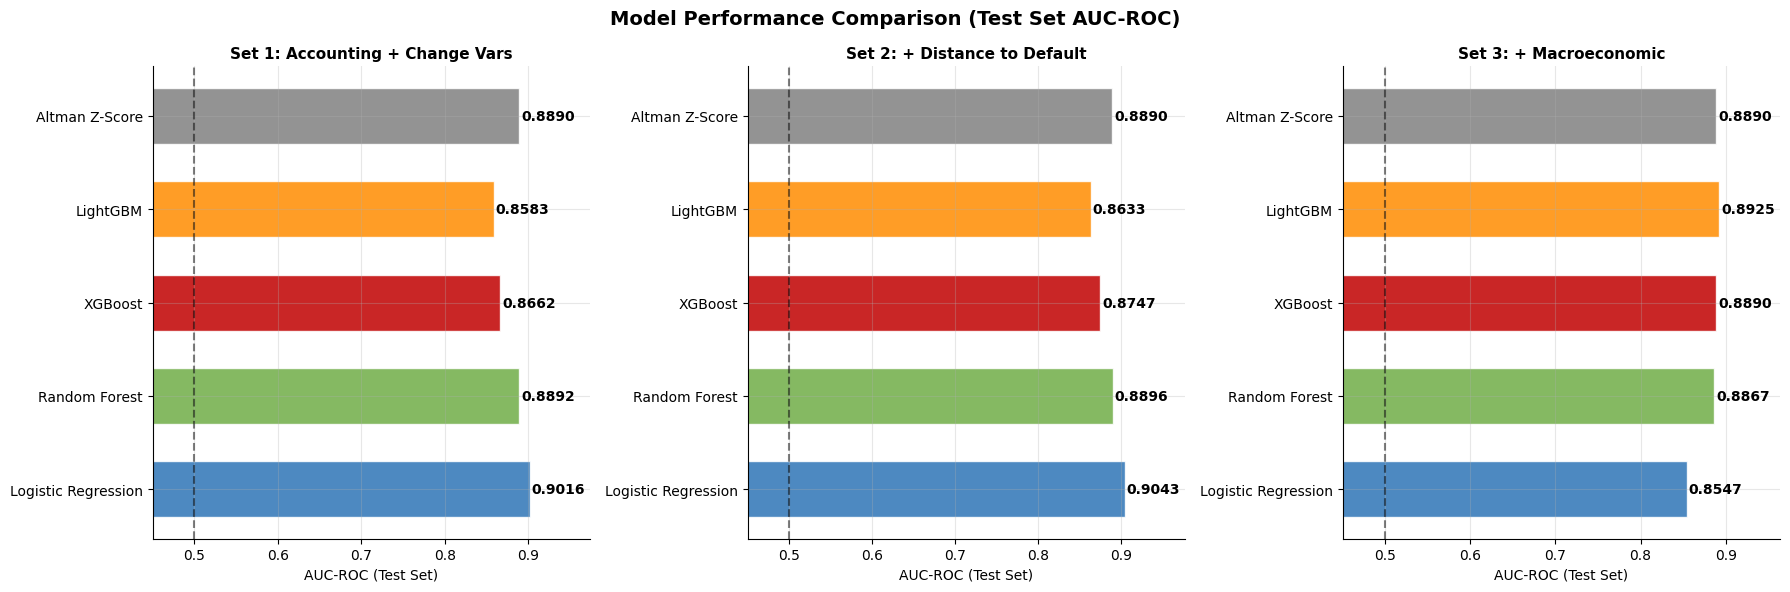

Saved: model_01_auc_comparison.png


In [35]:
#  Figure: AUC comparison across all sets and models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison (Test Set AUC-ROC)',
             fontsize=14, fontweight='bold')

model_colors = {
    'Logistic Regression': '#2E75B6',
    'Random Forest':       '#70AD47',
    'XGBoost':             '#C00000',
    'LightGBM':            '#FF8C00',
    'Altman Z-Score':      '#808080',
}
set_configs = [
    (results_set1,'Set 1: Accounting + Change Vars'),
    (results_set2,'Set 2: + Distance to Default'),
    (results_set3,'Set 3: + Macroeconomic'),
]
for ax,(res,title) in zip(axes,set_configs):
    models_list = list(res.keys())
    aucs        = [res[m]['AUC'] for m in models_list]
    colors      = [model_colors.get(m,'grey') for m in models_list]
    bars = ax.barh(models_list, aucs, color=colors, alpha=0.85, edgecolor='white', height=0.6)
    for bar, auc in zip(bars, aucs):
        ax.text(auc+0.002, bar.get_y()+bar.get_height()/2,
                f'{auc:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.axvline(0.5, color='black', ls='--', lw=1.5, alpha=0.5, label='Random (0.5)')
    ax.set_xlim([0.45, max(aucs)*1.08])
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('AUC-ROC (Test Set)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/model_01_auc_comparison.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Saved: model_01_auc_comparison.png")

## ROC Curves — All Three Model Sets

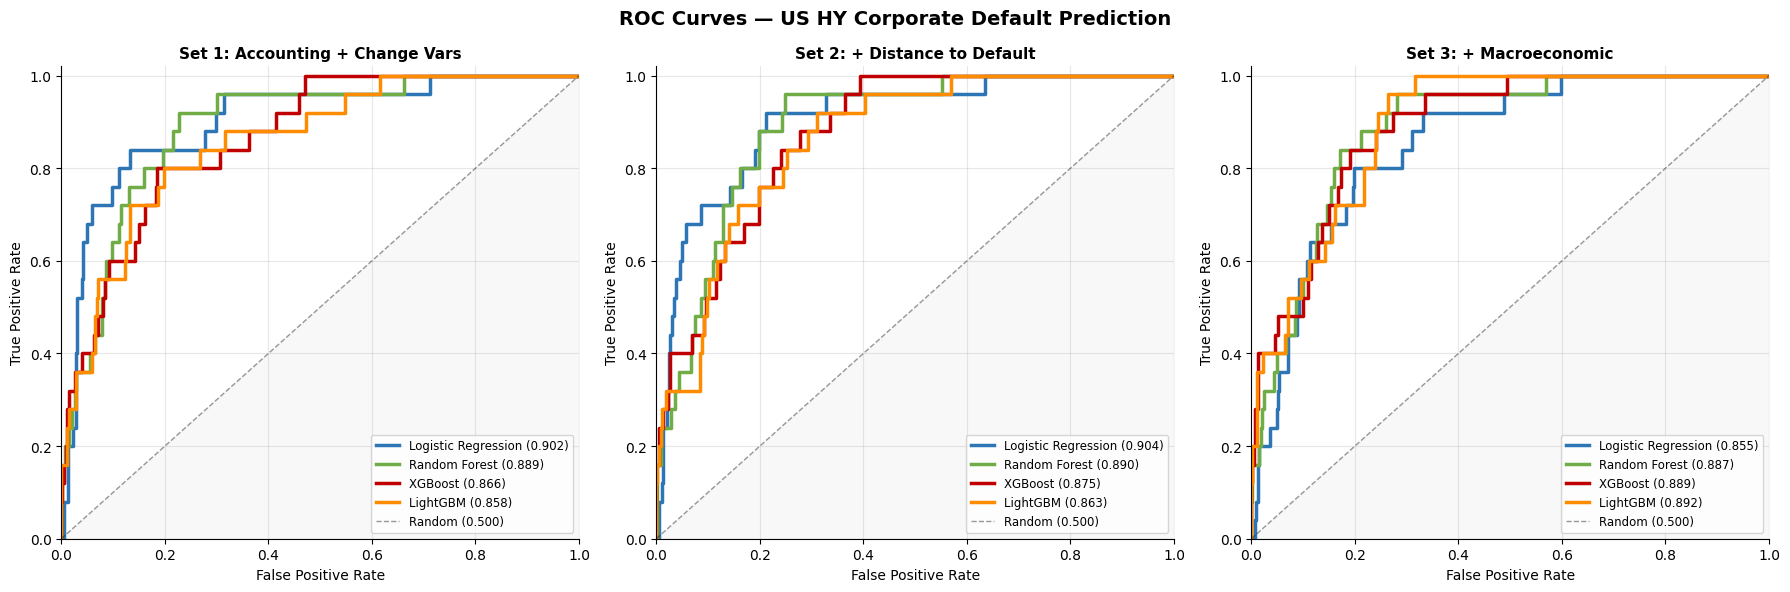

Saved: model_02_roc_curves.png


In [36]:
fig, axes = plt.subplots(1,3,figsize=(18,6))
line_cols = ['#2E75B6','#70AD47','#C00000','#FF8C00','#808080']
set_cfgs  = [
    (models_set1,X_te1,y_te1,'Set 1: Accounting + Change Vars'),
    (models_set2,X_te2,y_te2,'Set 2: + Distance to Default'),
    (models_set3,X_te3,y_te3,'Set 3: + Macroeconomic'),
]
for ax,(mods,X_te,y_te,title) in zip(axes,set_cfgs):
    for (name,pipe),col in zip(mods.items(),line_cols):
        probs     = pipe.predict_proba(X_te)[:,1]
        fpr,tpr,_ = roc_curve(y_te.values,probs)
        auc       = roc_auc_score(y_te.values,probs)
        ax.plot(fpr,tpr,color=col,lw=2.5,label=f'{name} ({auc:.3f})')
    ax.fill_between([0,1],[0,1],alpha=0.05,color='grey')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random (0.500)')
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('False Positive Rate',fontsize=10)
    ax.set_ylabel('True Positive Rate',fontsize=10)
    ax.legend(fontsize=8.5,loc='lower right')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

fig.suptitle('ROC Curves — US HY Corporate Default Prediction',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/model_02_roc_curves.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Saved: model_02_roc_curves.png")

## Metrics Comparison Heatmap

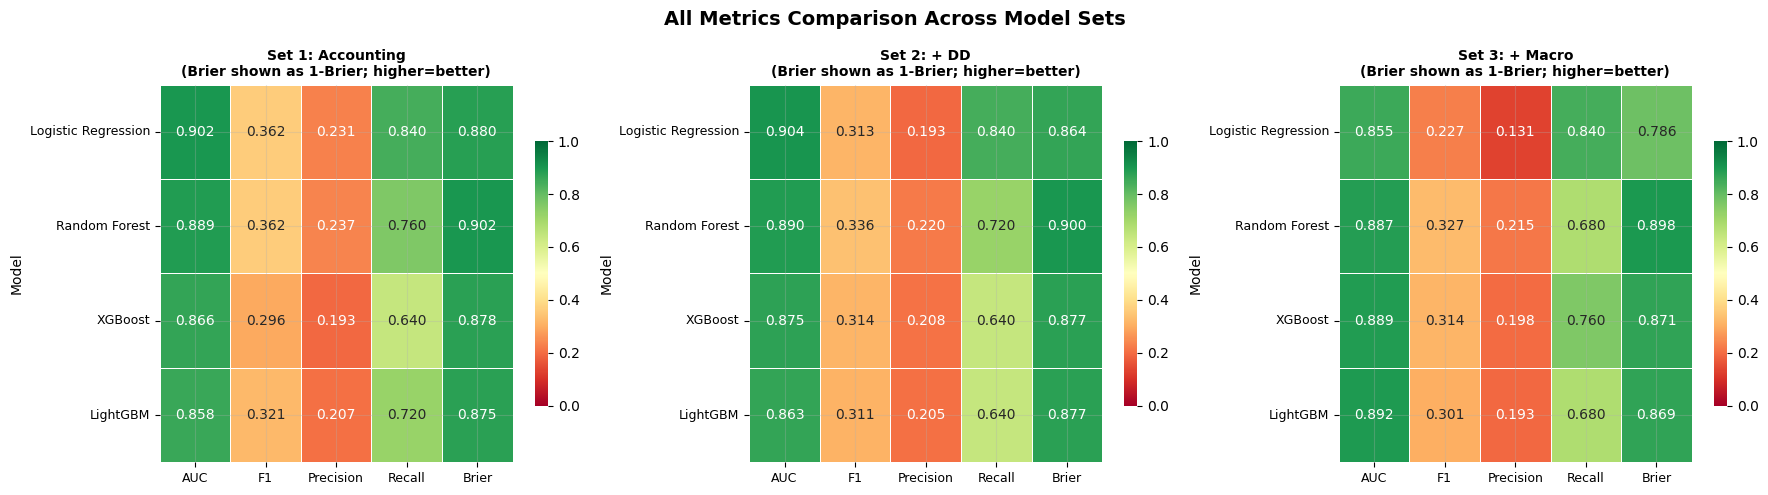

Saved: model_03_metrics_heatmap.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('All Metrics Comparison Across Model Sets',
             fontsize=14, fontweight='bold')

metrics_cols = ['AUC','F1','Precision','Recall','Brier']
set_names    = ['Set1_Accounting','Set2_DD','Set3_Macro']
set_titles   = ['Set 1: Accounting','Set 2: + DD','Set 3: + Macro']

for ax, sn, title in zip(axes, set_names, set_titles):
    sub = results_df[results_df['Set']==sn].set_index('Model')[metrics_cols]
    sub = sub.drop(index='Altman Z-Score', errors='ignore')
    # Invert Brier (lower is better) for visual consistency
    sub_plot = sub.copy()
    sub_plot['Brier'] = 1 - sub_plot['Brier']
    sns.heatmap(sub_plot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5,
                annot_kws={'size':10},
                cbar_kws={'shrink':0.7})
    ax.set_title(f'{title}\n(Brier shown as 1-Brier; higher=better)',
                 fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/model_03_metrics_heatmap.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Saved: model_03_metrics_heatmap.png")

## Classification Reports — Test Set

In [38]:
for mods,X_te,y_te,title in [
    (models_set1,X_te1,y_te1,'Set 1: Accounting + Change Vars'),
    (models_set2,X_te2,y_te2,'Set 2: + Distance to Default'),
    (models_set3,X_te3,y_te3,'Set 3: + Macro'),
]:
    print(f"\n{'='*55}\n{title}\n{'='*55}")
    for name,pipe in mods.items():
        preds=pipe.predict(X_te); probs=pipe.predict_proba(X_te)[:,1]
        print(f"\n--- {name} ---")
        print(classification_report(y_te.values,preds,
                                     target_names=['Non-Default','Default'],
                                     zero_division=0))
        print(f"  Brier Score: {brier_score_loss(y_te.values,probs):.4f}")


Set 1: Accounting + Change Vars

--- Logistic Regression ---
              precision    recall  f1-score   support

 Non-Default       0.99      0.84      0.91       449
     Default       0.23      0.84      0.36        25

    accuracy                           0.84       474
   macro avg       0.61      0.84      0.64       474
weighted avg       0.95      0.84      0.88       474

  Brier Score: 0.1197

--- Random Forest ---
              precision    recall  f1-score   support

 Non-Default       0.98      0.86      0.92       449
     Default       0.24      0.76      0.36        25

    accuracy                           0.86       474
   macro avg       0.61      0.81      0.64       474
weighted avg       0.95      0.86      0.89       474

  Brier Score: 0.0979

--- XGBoost ---
              precision    recall  f1-score   support

 Non-Default       0.98      0.85      0.91       449
     Default       0.19      0.64      0.30        25

    accuracy                        

## RQ4 — SHAP Explainability Analysis

## RQ4 — Extended SHAP Explainability
Global importance | Local explanations for top predicted defaults | Bootstrap stability analysis | DeLong-style RQ4 consistency test

RQ4: EXTENDED SHAP EXPLAINABILITY
  Global importance | Local explanations | Bootstrap stability


Best model: Logistic Regression (AUC = 0.9043)
LinearExplainer (Logistic Regression)

Top 15 features by mean |SHAP|:
EQFA                   1.3676
distance_to_default    0.6991
NITA                   0.5312
LTFFA                  0.5039
GPSA                   0.4639
LIABTA                 0.4233
QR                     0.4139
CFTA                   0.3991
LNSA                   0.3164
EQLIAB                 0.3127
LTLTA                  0.3069
EBITDASA               0.2895
EQFA_chg               0.2077
SATA                   0.2026
LNTA                   0.1895


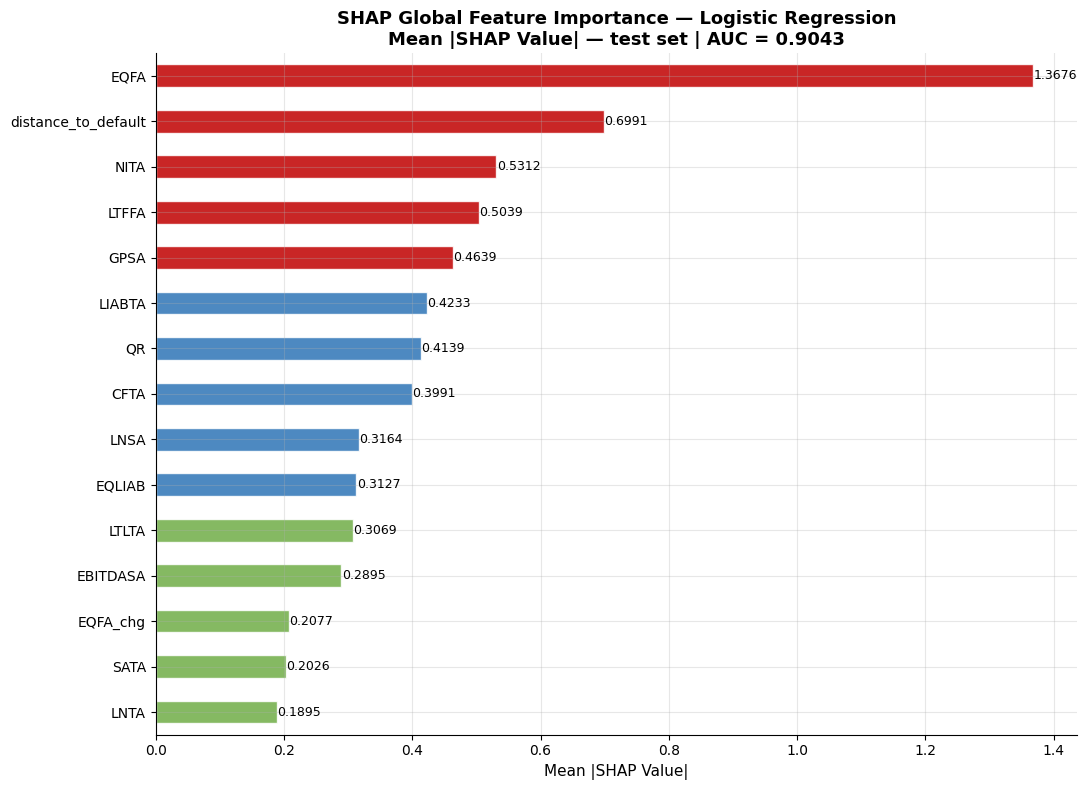

Saved: shap_01_importance.png


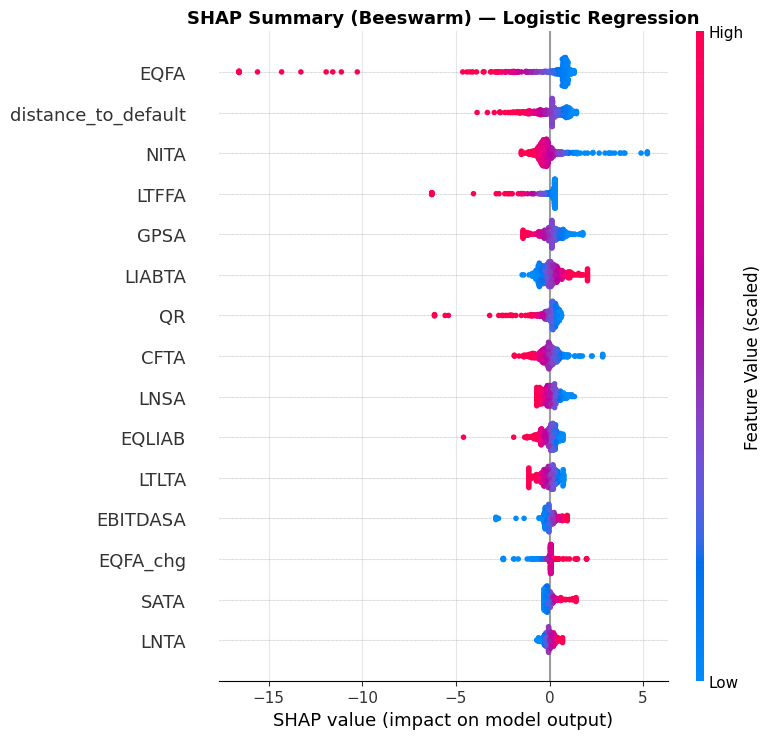

Saved: shap_02_beeswarm.png

--- RQ4: LOCAL EXPLANATIONS (individual default predictions) ---


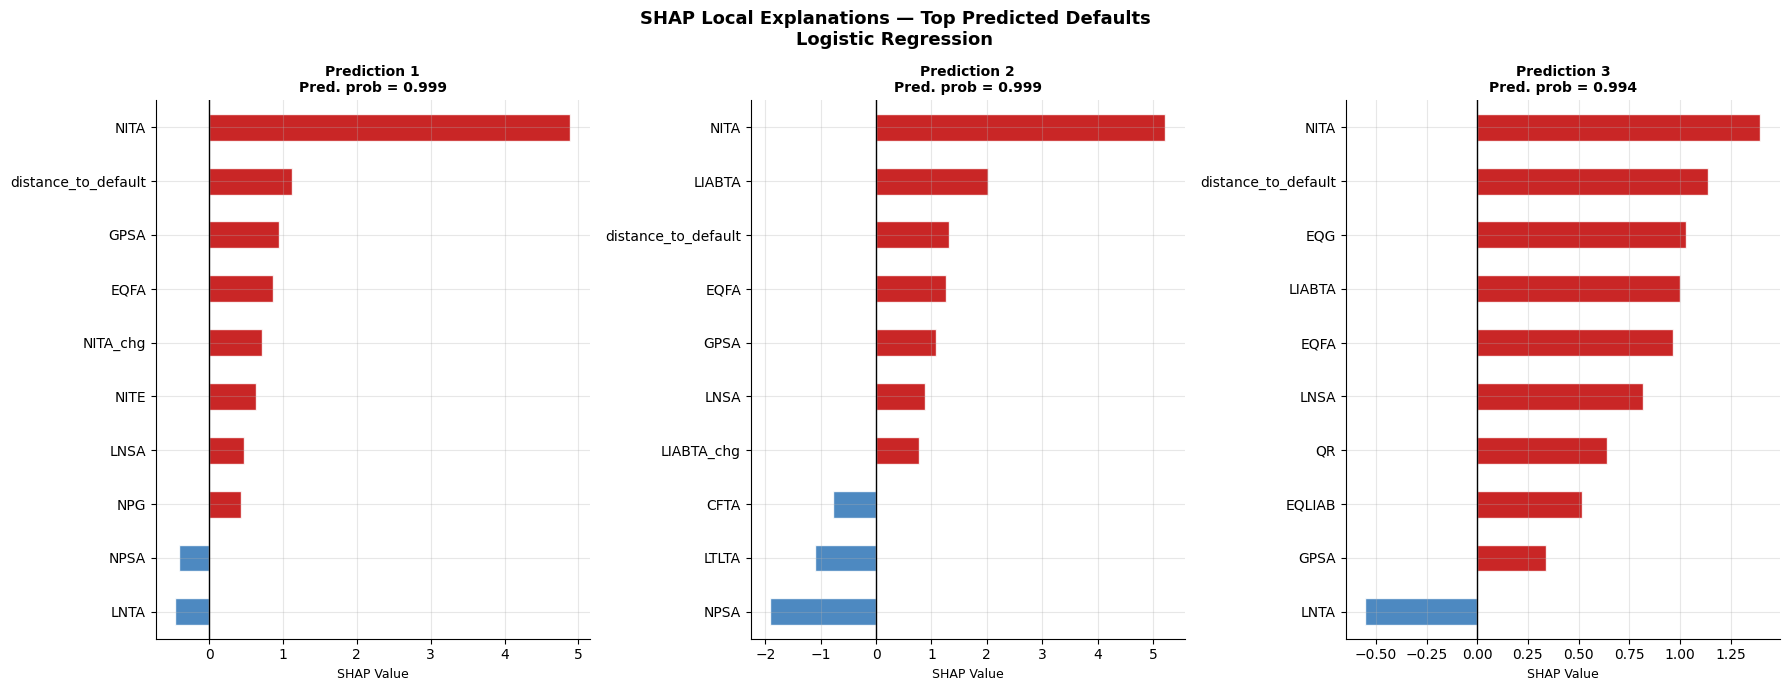

Saved: shap_04_local.png (5 local explanations)

--- RQ4: SHAP FEATURE STABILITY (Bootstrap, DeLong-style RQ4 test) ---
H4₀: SHAP does not identify a stable set of dominant predictors
H4ₐ: SHAP identifies a consistent, stable top feature set

Bootstrap iterations: 100 | Sampling fraction: 80% | Top-K: 10
Mean Jaccard similarity (top-10 overlap with full-sample ranking):
  Mean: 0.8861 | 95% CI: [0.8182, 1.0000]
  Interpretation: 88.6% average overlap with baseline top-10

Feature appearance frequency in top-10 across 100 bootstraps:
                     frequency    pct
LTFFA                      100  100.0
NITA                       100  100.0
EQFA                       100  100.0
distance_to_default        100  100.0
LIABTA                     100  100.0
CFTA                       100  100.0
GPSA                       100  100.0
QR                         100  100.0
LNSA                        75   75.0
EQLIAB                      62   62.0
LTLTA                       51   51.0
EBITD

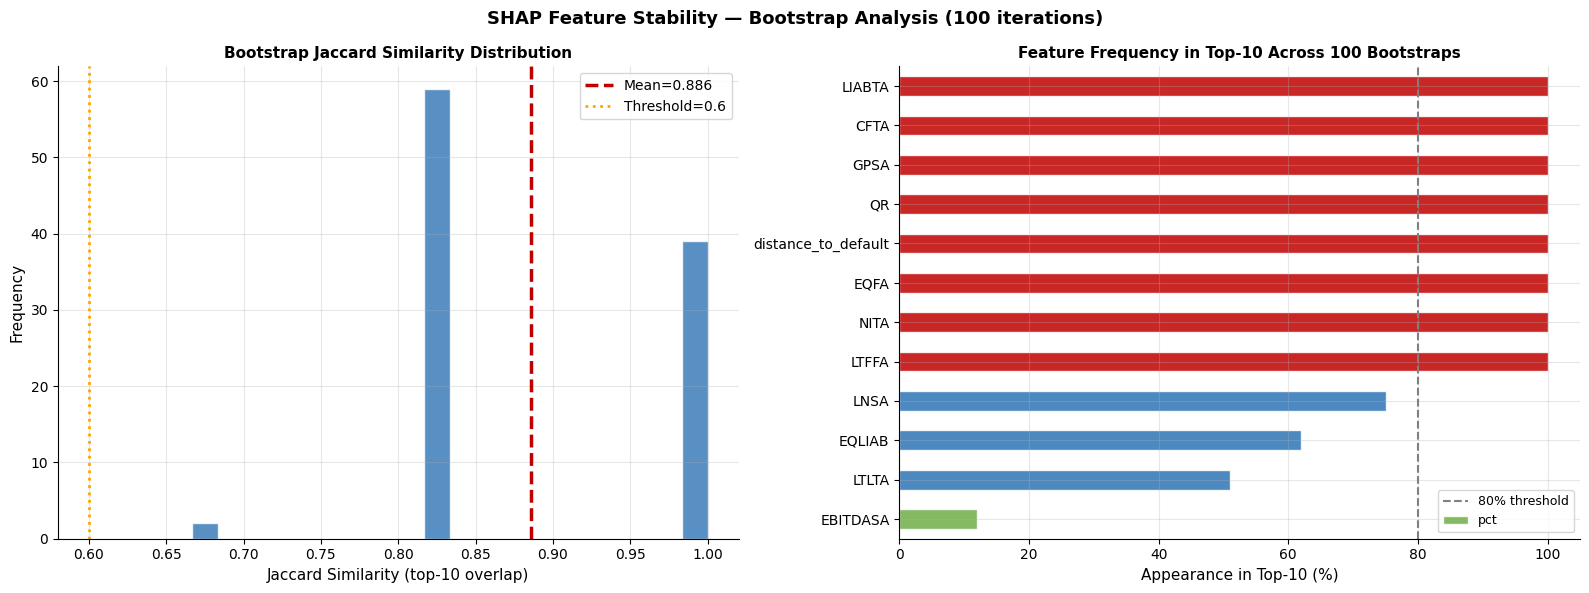

Saved: shap_05_stability.png


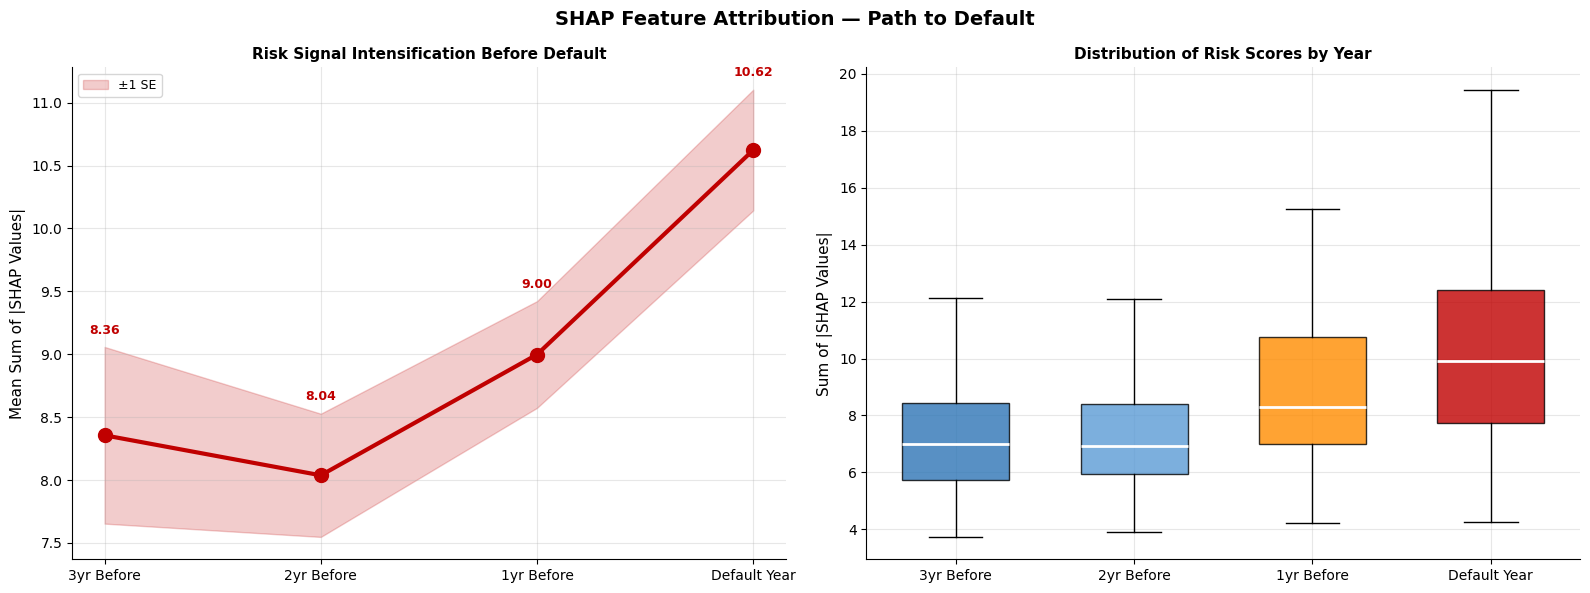

Saved: shap_03_trajectory.png
Saved: shap_importance.csv, shap_stability.csv

RQ4 SUMMARY:
  Best model:         Logistic Regression
  Top feature:        EQFA (|SHAP|=1.3676)
  Stability (Jaccard):0.8861 [95% CI: 0.8182, 1.0000]
  Decision:           Reject H4₀ (Jaccard=0.886 >= 0.6)


In [39]:
print("="*55)
print("RQ4: EXTENDED SHAP EXPLAINABILITY")
print("  Global importance | Local explanations | Bootstrap stability")
print("="*55)

import shap

#  Identify best model across all sets + tuned
best_auc, best_name, best_pipe = 0, None, None
best_X_te, best_y_te, best_feats = None, None, None

for res,mods,X_te,y_te,feats in [
    (results_set1, models_set1, X_te1, y_te1, FEAT_SET1),
    (results_set2, models_set2, X_te2, y_te2, FEAT_SET2),
    (results_set3, models_set3, X_te3, y_te3, FEAT_SET3),
    (results_tuned, fitted_tuned, X_te1_eval, y_te1_eval, FEAT_SET1),
]:
    for name, pipe in mods.items():
        if 'Altman' in name: continue
        try:
            auc = roc_auc_score(y_te.values, pipe.predict_proba(X_te)[:,1])
            if auc > best_auc:
                best_auc, best_name, best_pipe = auc, name, pipe
                best_X_te, best_y_te, best_feats = X_te, y_te, feats
        except: continue

print(f"Best model: {best_name} (AUC = {best_auc:.4f})")
steps      = {n:s for n,s in best_pipe.steps}
X_imp      = steps['imputer'].transform(best_X_te)
X_imp_df   = pd.DataFrame(X_imp, columns=best_feats)
underlying = steps['model']
mtype      = type(underlying).__name__

try:
    if 'Logistic' in mtype or 'LR' in best_name:
        X_sc     = steps['scaler'].transform(X_imp)
        X_sc_df  = pd.DataFrame(X_sc, columns=best_feats)
        explainer   = shap.LinearExplainer(underlying, X_sc_df)
        sv          = explainer.shap_values(X_sc_df)
        X_for_plot  = X_sc_df
        print("LinearExplainer (Logistic Regression)")
    else:
        explainer   = shap.TreeExplainer(underlying)
        shap_raw    = explainer.shap_values(X_imp_df)
        sv          = shap_raw[1] if isinstance(shap_raw, list) else shap_raw
        X_for_plot  = X_imp_df
        print(f"TreeExplainer ({mtype})")

    mean_abs = np.abs(sv).mean(axis=0)
    shap_imp = pd.Series(mean_abs, index=best_feats).sort_values(ascending=False)

    print("\nTop 15 features by mean |SHAP|:")
    print(shap_imp.head(15).round(4).to_string())

    #  Figure 1: SHAP Global Bar
    fig, ax = plt.subplots(figsize=(11, 8))
    top15   = shap_imp.head(15).sort_values(ascending=True)
    colors  = [C_DEF if i>=10 else C_NODEF if i>=5 else C_NEUT for i in range(len(top15))]
    top15.plot(kind='barh', ax=ax, color=colors, alpha=0.85, edgecolor='white')
    for i, (val, bar) in enumerate(zip(top15.values, ax.patches)):
        ax.text(val+0.0005, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(f'SHAP Global Feature Importance — {best_name}\n'
                 f'Mean |SHAP Value| — test set | AUC = {best_auc:.4f}',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/shap_01_importance.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: shap_01_importance.png")

    #  Figure 2: SHAP Beeswarm
    plt.figure(figsize=(11, 8))
    shap.summary_plot(sv, X_for_plot, plot_type='dot', show=False,
                      max_display=15, color_bar_label='Feature Value (scaled)')
    plt.title(f'SHAP Summary (Beeswarm) — {best_name}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/shap_02_beeswarm.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: shap_02_beeswarm.png")

    #  LOCAL EXPLANATIONS: Top 5 highest-confidence defaults
    print("\n--- RQ4: LOCAL EXPLANATIONS (individual default predictions) ---")
    y_prob_test = best_pipe.predict_proba(best_X_te)[:,1]
    test_copy   = best_X_te.copy()
    test_copy['y_default']    = best_y_te.values
    test_copy['pred_prob']    = y_prob_test

    # Select top-5 highest predicted default probability among actual defaults
    actual_defaults = test_copy[test_copy['y_default'] == 1].sort_values(
        'pred_prob', ascending=False)
    n_local = min(5, len(actual_defaults))
    local_idx = actual_defaults.head(n_local).index

    if n_local > 0:
        # Get SHAP values for these specific observations
        local_X = pd.DataFrame(
            steps['imputer'].transform(best_X_te.loc[local_idx]),
            columns=best_feats
        )
        if 'Logistic' in mtype or 'LR' in best_name:
            local_X_sc = pd.DataFrame(steps['scaler'].transform(local_X),
                                       columns=best_feats)
            sv_local   = explainer.shap_values(local_X_sc)
            local_for_plot = local_X_sc
        else:
            sv_local = explainer.shap_values(local_X)
            sv_local = sv_local[1] if isinstance(sv_local, list) else sv_local
            local_for_plot = local_X

        # Figure 3: Local waterfall charts for top 3 predictions
        fig, axes = plt.subplots(1, min(3, n_local), figsize=(18, 7))
        if min(3, n_local) == 1:
            axes = [axes]
        fig.suptitle(f'SHAP Local Explanations — Top Predicted Defaults\n{best_name}',
                     fontsize=13, fontweight='bold')

        for j, ax in enumerate(axes[:min(3, n_local)]):
            sv_j    = sv_local[j] if hasattr(sv_local, '__len__') and len(sv_local.shape)>1 else sv_local[j]
            feat_sv = pd.Series(sv_j, index=best_feats).sort_values(key=abs, ascending=False).head(10)
            colors  = [C_DEF if v > 0 else C_NODEF for v in feat_sv.values]
            feat_sv.sort_values().plot(kind='barh', ax=ax, color=
                [C_DEF if v > 0 else C_NODEF for v in feat_sv.sort_values().values],
                alpha=0.85, edgecolor='white')
            ax.axvline(0, color='black', lw=1)
            ax.set_title(f'Prediction {j+1}\nPred. prob = {actual_defaults.iloc[j]["pred_prob"]:.3f}',
                         fontweight='bold', fontsize=10)
            ax.set_xlabel('SHAP Value', fontsize=9)

        plt.tight_layout()
        plt.savefig(f'{OUTPUT}/shap_04_local.png', dpi=150,
                    bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"Saved: shap_04_local.png ({n_local} local explanations)")

    #  BOOTSTRAP STABILITY: Top-K rank overlap
    print("\n--- RQ4: SHAP FEATURE STABILITY (Bootstrap, DeLong-style RQ4 test) ---")
    print("H4₀: SHAP does not identify a stable set of dominant predictors")
    print("H4ₐ: SHAP identifies a consistent, stable top feature set")
    print()

    N_BOOT = 100
    TOP_K  = 10
    boot_ranks = []
    np.random.seed(42)

    n_test_obs = len(X_for_plot)
    for b in range(N_BOOT):
        idx  = np.random.choice(n_test_obs, size=int(n_test_obs*0.8), replace=True)
        X_b  = X_for_plot.iloc[idx]
        if 'Logistic' in mtype or 'LR' in best_name:
            sv_b = explainer.shap_values(X_b)
        else:
            sv_b = explainer.shap_values(X_b)
            sv_b = sv_b[1] if isinstance(sv_b, list) else sv_b
        ma   = np.abs(sv_b).mean(axis=0)
        top_k_feats = pd.Series(ma, index=best_feats).nlargest(TOP_K).index.tolist()
        boot_ranks.append(set(top_k_feats))

    # Compute Jaccard similarity of top-K sets across bootstrap samples
    baseline_top_k = set(shap_imp.head(TOP_K).index.tolist())
    jaccard_scores = [
        len(b & baseline_top_k) / len(b | baseline_top_k)
        for b in boot_ranks
    ]
    mean_jaccard   = np.mean(jaccard_scores)
    ci_lower       = np.percentile(jaccard_scores, 2.5)
    ci_upper       = np.percentile(jaccard_scores, 97.5)

    # Feature appearance frequency
    from collections import Counter
    all_features = [f for bset in boot_ranks for f in bset]
    freq = Counter(all_features)
    freq_df = pd.DataFrame.from_dict(freq, orient='index', columns=['frequency'])
    freq_df['pct'] = freq_df['frequency'] / N_BOOT * 100
    freq_df = freq_df.sort_values('pct', ascending=False)

    print(f"Bootstrap iterations: {N_BOOT} | Sampling fraction: 80% | Top-K: {TOP_K}")
    print(f"Mean Jaccard similarity (top-{TOP_K} overlap with full-sample ranking):")
    print(f"  Mean: {mean_jaccard:.4f} | 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  Interpretation: {mean_jaccard*100:.1f}% average overlap with baseline top-{TOP_K}")
    print()
    print(f"Feature appearance frequency in top-{TOP_K} across {N_BOOT} bootstraps:")
    print(freq_df.head(15).to_string())

    # Hypothesis decision
    stability_threshold = 0.60
    if mean_jaccard >= stability_threshold:
        h4_decision = f"Reject H4₀ (Jaccard={mean_jaccard:.3f} >= {stability_threshold})"
        h4_sig      = "Stable feature set identified"
    else:
        h4_decision = f"Fail to Reject H4₀ (Jaccard={mean_jaccard:.3f} < {stability_threshold})"
        h4_sig      = "Feature set not sufficiently stable"

    print(f"\nRQ4 Decision: {h4_decision}")
    print(f"Assessment:   {h4_sig}")

    # Figure 4: Stability chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'SHAP Feature Stability — Bootstrap Analysis ({N_BOOT} iterations)',
                 fontsize=13, fontweight='bold')

    # Left: Jaccard distribution
    ax = axes[0]
    ax.hist(jaccard_scores, bins=20, color=C_NODEF, alpha=0.8, edgecolor='white')
    ax.axvline(mean_jaccard, color=C_DEF, lw=2.5, ls='--', label=f'Mean={mean_jaccard:.3f}')
    ax.axvline(stability_threshold, color='orange', lw=2, ls=':', label=f'Threshold={stability_threshold}')
    ax.set_xlabel(f'Jaccard Similarity (top-{TOP_K} overlap)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Bootstrap Jaccard Similarity Distribution', fontweight='bold', fontsize=11)
    ax.legend(fontsize=10)

    # Right: Feature frequency
    ax2 = axes[1]
    top15_freq = freq_df.head(15).sort_values('pct', ascending=True)
    colors_freq = [C_DEF if p>=80 else C_NODEF if p>=50 else C_NEUT
                   for p in top15_freq['pct']]
    top15_freq['pct'].plot(kind='barh', ax=ax2, color=colors_freq, alpha=0.85,
                            edgecolor='white')
    ax2.axvline(80, color='grey', ls='--', lw=1.5, label='80% threshold')
    ax2.set_xlabel(f'Appearance in Top-{TOP_K} (%)', fontsize=11)
    ax2.set_title(f'Feature Frequency in Top-{TOP_K} Across {N_BOOT} Bootstraps',
                  fontweight='bold', fontsize=11)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/shap_05_stability.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: shap_05_stability.png")

    #  Figure 5: SHAP trajectory
    X_tr_raw = train[best_feats].copy()
    X_tr_imp = pd.DataFrame(steps['imputer'].transform(X_tr_raw), columns=best_feats)
    if 'Logistic' in mtype or 'LR' in best_name:
        X_tr_sc   = pd.DataFrame(steps['scaler'].transform(X_tr_imp), columns=best_feats)
        sv_train  = explainer.shap_values(X_tr_sc)
    else:
        sv_train  = explainer.shap_values(X_tr_imp)
        sv_train  = sv_train[1] if isinstance(sv_train, list) else sv_train

    train_cp = train.copy().reset_index(drop=True)
    train_cp['shap_sum'] = np.abs(sv_train).sum(axis=1)
    traj = []
    for tk in train_cp[train_cp.y_default==1]['Ticker'].unique():
        firm   = train_cp[train_cp.Ticker==tk].sort_values('Year')
        def_yr = firm[firm.y_default==1]['Year'].min()
        for lag in [3,2,1,0]:
            row = firm[firm.Year == def_yr - lag]
            if len(row) > 0:
                traj.append({'Lag': lag, 'shap_sum': row.iloc[0]['shap_sum']})

    traj_df = pd.DataFrame(traj)
    if len(traj_df) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('SHAP Feature Attribution — Path to Default', fontsize=14, fontweight='bold')
        ax = axes[0]
        traj_m  = traj_df.groupby('Lag')['shap_sum'].agg(['mean','sem'])
        lags    = traj_m.index[::-1].tolist()
        means   = traj_m['mean'][::-1].tolist()
        sems    = traj_m['sem'][::-1].tolist()
        ax.plot(range(len(lags)), means, 'o-', color=C_DEF, lw=3, ms=10, zorder=3)
        ax.fill_between(range(len(lags)),
                         [m-s for m,s in zip(means,sems)],
                         [m+s for m,s in zip(means,sems)],
                         alpha=0.2, color=C_DEF, label='±1 SE')
        ax.set_xticks(range(len(lags)))
        ax.set_xticklabels(['3yr Before','2yr Before','1yr Before','Default Year'], fontsize=10)
        ax.set_ylabel('Mean Sum of |SHAP Values|', fontsize=11)
        ax.set_title('Risk Signal Intensification Before Default', fontweight='bold', fontsize=11)
        ax.legend(fontsize=9)
        for i,(m,s) in enumerate(zip(means,sems)):
            ax.annotate(f'{m:.2f}', (i, m+s+0.01*max(means)),
                         ha='center', fontsize=9, color=C_DEF, fontweight='bold')

        ax2 = axes[1]
        for lag, label, col, pos in [(3,'3yr Before',C_NODEF,1),(2,'2yr Before','#5B9BD5',2),
                                      (1,'1yr Before',C_WARN,3),(0,'Default Year',C_DEF,4)]:
            d  = traj_df[traj_df.Lag==lag]['shap_sum'].dropna()
            bp = ax2.boxplot([d], positions=[pos], patch_artist=True, widths=0.6,
                              showfliers=False, medianprops=dict(color='white',lw=2))
            bp['boxes'][0].set_facecolor(col); bp['boxes'][0].set_alpha(0.8)
        ax2.set_xticks([1,2,3,4])
        ax2.set_xticklabels(['3yr Before','2yr Before','1yr Before','Default Year'], fontsize=10)
        ax2.set_ylabel('Sum of |SHAP Values|', fontsize=11)
        ax2.set_title('Distribution of Risk Scores by Year', fontweight='bold', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT}/shap_03_trajectory.png', dpi=150,
                    bbox_inches='tight', facecolor='white')
        plt.show()
        print("Saved: shap_03_trajectory.png")

    # Save all SHAP results
    shap_imp.reset_index().rename(
        columns={'index':'Feature', 0:'Mean_Abs_SHAP'}
    ).to_csv(f'{OUTPUT}/shap_importance.csv', index=False)
    freq_df.to_csv(f'{OUTPUT}/shap_stability.csv')
    print("Saved: shap_importance.csv, shap_stability.csv")

    print(f"\nRQ4 SUMMARY:")
    print(f"  Best model:         {best_name}")
    print(f"  Top feature:        {shap_imp.index[0]} (|SHAP|={shap_imp.iloc[0]:.4f})")
    print(f"  Stability (Jaccard):{mean_jaccard:.4f} [95% CI: {ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  Decision:           {h4_decision}")

except Exception as e:
    import traceback
    print(f"SHAP error: {e}")
    traceback.print_exc()

## Final Summary

In [40]:
print("="*55)
print("COMPLETE — Final Version")
print("="*55)
print(f"\nOutputs: {OUTPUT}")
print()
print("Data outputs:")
print("  panel_cleaned.csv          — cleaned panel")
print("  macro_panel.csv            — FRED macro")
print("  model_results_all.csv      — all metrics (3 model sets)")
print("  model_results_tuned.csv    — tuned model metrics")
print("  hypothesis_tests.csv       — DeLong tests (RQ1-3)")
print("  tuned_hyperparams.json     — best hyperparameters")
print("  sample_size_report.json    — minimum sample size per RQ")
print("  eda_descriptive_stats.csv  — descriptive statistics")
print("  shap_importance.csv        — SHAP global importance")
print("  shap_stability.csv         — SHAP bootstrap frequency")
print()
print("EDA figures:")
print("  eda_01_default_overview.png")
print("  eda_02_distributions.png")
print("  eda_03_boxplots.png")
print("  eda_04_correlation.png")
print("  eda_05_trends.png")
print("  eda_06_missing_data.png")
print("  eda_07_change_vars.png")
print("  eda_08_altman.png")
print()
print("Model figures:")
print("  model_01_auc_comparison.png")
print("  model_02_roc_curves.png")
print("  model_03_metrics_heatmap.png")
print()
print("SHAP figures:")
print("  shap_01_importance.png     — global bar chart")
print("  shap_02_beeswarm.png       — beeswarm summary")
print("  shap_03_trajectory.png     — path to default")
print("  shap_04_local.png          — local waterfall (top predicted defaults)")
print("  shap_05_stability.png      — bootstrap stability")
print()
print("Improvements implemented:")
print("  SMOTE replaced with SMOTE-ENN inside CV folds")
print("  Bayesian hyperparameter tuning (20 iterations per model, Set 1)")
print("  Sample size calculations added for all 4 RQs")
print("  Local SHAP explanations for top predicted defaults")
print("  Bootstrap stability analysis for RQ4 (100 iterations)")

COMPLETE — Final Version

Outputs: /content/drive/MyDrive/DBA/Research/outputs

Data outputs:
  panel_cleaned.csv          — cleaned panel
  macro_panel.csv            — FRED macro
  model_results_all.csv      — all metrics (3 model sets)
  model_results_tuned.csv    — tuned model metrics
  hypothesis_tests.csv       — DeLong tests (RQ1-3)
  tuned_hyperparams.json     — best hyperparameters
  sample_size_report.json    — minimum sample size per RQ
  eda_descriptive_stats.csv  — descriptive statistics
  shap_importance.csv        — SHAP global importance
  shap_stability.csv         — SHAP bootstrap frequency

EDA figures:
  eda_01_default_overview.png
  eda_02_distributions.png
  eda_03_boxplots.png
  eda_04_correlation.png
  eda_05_trends.png
  eda_06_missing_data.png
  eda_07_change_vars.png
  eda_08_altman.png

Model figures:
  model_01_auc_comparison.png
  model_02_roc_curves.png
  model_03_metrics_heatmap.png

SHAP figures:
  shap_01_importance.png     — global bar chart
  shap_02

In [41]:
import sklearn, imblearn, xgboost, lightgbm, shap
import pandas, numpy, matplotlib, seaborn, scipy, skopt

print(f"Python:          {__import__('sys').version.split()[0]}")
print(f"pandas:          {pandas.__version__}")
print(f"numpy:           {numpy.__version__}")
print(f"scikit-learn:    {sklearn.__version__}")
print(f"imbalanced-learn:{imblearn.__version__}")
print(f"xgboost:         {xgboost.__version__}")
print(f"lightgbm:        {lightgbm.__version__}")
print(f"shap:            {shap.__version__}")
print(f"matplotlib:      {matplotlib.__version__}")
print(f"seaborn:         {seaborn.__version__}")
print(f"scipy:           {scipy.__version__}")
print(f"scikit-optimize: {skopt.__version__}")

Python:          3.12.13
pandas:          2.2.2
numpy:           2.0.2
scikit-learn:    1.6.1
imbalanced-learn:0.14.1
xgboost:         3.2.0
lightgbm:        4.6.0
shap:            0.52.0
matplotlib:      3.10.0
seaborn:         0.13.2
scipy:           1.16.3
scikit-optimize: 0.10.2
